In [ ]:
from pathlib import Path
import os
import sys
import pickle

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
%matplotlib inline

from sklearn.metrics import accuracy_score, confusion_matrix

# OLD FORMAT

In [ ]:
root_path = "/Users/kautsarg/Documents/Final Project/Run Data/trial test data/"
sample_name = "D20250808_E00_C00_F4500KHz_U_Sample_7"
exp_path = os.path.join(root_path, sample_name)
data_path = os.path.join(exp_path, "classification_performances_with_proba.pkl")
with open(data_path, 'rb') as f:
    result_data = pickle.load(f)

In [ ]:
result_data

In [ ]:
EXPECTED_CLASSES = list(range(10)) 
model_key_mapping = {
    "CNN": "y_preds_AC_",
    # "KNN": "y_preds_AC_kNN_",
    # "LR":  "y_preds_FFI_"
}

rows = []

print("[*] Flattening dictionary into tabular format...")
for curve_name, modes in result_data.items():
    for mode_name, filters in modes.items():

        total_samples = max(metrics.get("mask_count", 0) for metrics in filters.values())
        
        for filter_name, metrics in filters.items():
            clean_filter = filter_name if filter_name is not None else "Baseline_None"
            surviving_samples = metrics.get("mask_count", total_samples)
            outlier_pct = ((total_samples - surviving_samples) / total_samples) * 100
            
            y_true = np.concatenate(metrics["y_trues_"])
            
            for clean_model_name, dict_key in model_key_mapping.items():
                y_pred = np.concatenate(metrics[dict_key])
                
                total_acc = accuracy_score(y_true, y_pred)
                
                row_data = {
                    "curve_name": curve_name,
                    "training_mode": mode_name,
                    "outlier_filter": clean_filter,
                    "model": clean_model_name,
                    "outlier_percentage": round(outlier_pct, 2),  # Rounded for cleaner CSV reading
                    "total_accuracy": total_acc
                }
                
                cm = confusion_matrix(y_true, y_pred, labels=EXPECTED_CLASSES)
                
                with np.errstate(divide='ignore', invalid='ignore'):
                    per_class_acc = cm.diagonal() / cm.sum(axis=1)
                
                for well_idx in EXPECTED_CLASSES:
                    col_name = f"accuracy_well_{well_idx}"
                    row_data[col_name] = per_class_acc[well_idx]
                    
                rows.append(row_data)

result_df = pd.DataFrame(rows)

csv_out = os.path.join(exp_path, "flattened_results.csv")
result_df["accuracy_well_avg"] = np.average(result_df.filter(like="accuracy_well_"), axis=1)
result_df.to_csv(csv_out, index=False)
print(f"\n[*] Saved flat CSV to: {csv_out}")

In [ ]:
print("Curves:")
print(np.unique(result_df.curve_name))
print("-"*50)

print("Filter:")
print(np.unique(result_df.outlier_filter))
print("-"*50)

## OUTLIER DETECTION METHOD COMPARISON

In [ ]:
def plot_accuracy_comparison_static(filtered_df, title="Model Accuracy Comparison", save_path=None):
    """
    Generates a static high-resolution grouped bar chart using Seaborn,
    with custom gridlines and 90-degree data labels inside the bars.
    """
    
    sns.set_theme(style="white", font_scale=1.1) 
    fig, ax = plt.subplots(figsize=(12, 7)) 
    
    barplot = sns.barplot(
        data=filtered_df, 
        x="model", 
        y="total_accuracy", 
        hue="curve_name",
        palette="viridis",
        edgecolor="black",
        linewidth=1,
        ax=ax
    )
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Machine Learning Model", fontsize=14, fontweight='bold')
    ax.set_ylabel("Total Accuracy", fontsize=14, fontweight='bold')
    
    # --- 1. SET Y-AXIS EXACTLY 0 to 100% ---
    ax.set_ylim(0, 1.0)
    
    # Set gridlines (Major every 5%, Minor every 1%)
    ax.yaxis.set_major_locator(mtick.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(mtick.MultipleLocator(0.01))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
    
    ax.grid(which='major', axis='y', linestyle='-', linewidth=1.5, color='#eaeaea')
    ax.grid(which='minor', axis='y', linestyle=':', linewidth=1, color='#cccccc', alpha=0.7)
    ax.set_axisbelow(True) 
    
    # --- 2. ADD ACCURACY TEXT INSIDE THE BARS (ROTATED 90 DEG) ---
    for container in ax.containers:
        labels = [f"{bar.get_height()*100:.1f}%" if bar.get_height() > 0 else "" for bar in container]
        
        ax.bar_label(
            container, 
            labels=labels, 
            label_type='edge',     # Anchor to the top edge of the bar
            padding=-35,           # Negative padding pulls the text DOWN inside the bar
            fontsize=10, 
            fontweight='bold', 
            color='white',         # White text pops best inside colored bars
            rotation=90            # Rotate 90 degrees pointing up
        )
    
    # Move legend outside
    plt.legend(title='Curve Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300, facecolor='white')
        print(f"[*] Saved static plot to {save_path}")

def plot_flexible_grouped_bar(df, x_col, y_col, hue_col, title=None, is_percentage=True, is_horizontal=False, baseline_value=None, save_path=None):
    """
    A highly flexible grouped bar chart generator using Seaborn.
    Supports vertical/horizontal orientations and dynamic baseline thresholds.
    """
    
    sns.set_theme(style="white", font_scale=1.1) 
    
    # 1. Map Data Based on Orientation
    if is_horizontal:
        fig, ax = plt.subplots(figsize=(12, 12)) 
        sns.barplot(data=df, x=y_col, y=x_col, hue=hue_col, palette="viridis", edgecolor="black", linewidth=1, ax=ax)
        ax.set_xlabel(y_col.replace("_", " ").title(), fontsize=14, fontweight='bold')
        ax.set_ylabel(x_col.replace("_", " ").title(), fontsize=14, fontweight='bold')
        ax.tick_params(axis='y', rotation=0) 
    else:
        fig, ax = plt.subplots(figsize=(12, 7)) 
        sns.barplot(data=df, x=x_col, y=y_col, hue=hue_col, palette="viridis", edgecolor="black", linewidth=1, ax=ax)
        ax.set_xlabel(x_col.replace("_", " ").title(), fontsize=14, fontweight='bold')
        ax.set_ylabel(y_col.replace("_", " ").title(), fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=90)
    
    if title:
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
        
    # 2. Dynamic Axis & Grid Formatting
    val_axis = ax.xaxis if is_horizontal else ax.yaxis
    grid_axis = 'x' if is_horizontal else 'y'
    
    if is_percentage:
        if is_horizontal: ax.set_xlim(0, 1.0)
        else: ax.set_ylim(0, 1.0)
            
        val_axis.set_major_locator(mtick.MultipleLocator(0.1))
        val_axis.set_minor_locator(mtick.MultipleLocator(0.01))
        val_axis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
        
        ax.grid(which='major', axis=grid_axis, linestyle='-', linewidth=1.5, color='#eaeaea')
        ax.grid(which='minor', axis=grid_axis, linestyle=':', linewidth=1, color='#cccccc', alpha=0.7)
    else:
        ax.grid(which='major', axis=grid_axis, linestyle='-', linewidth=1.5, color='#eaeaea')
        
    ax.set_axisbelow(True) 
    
    # --- NEW: Draw Baseline Threshold ---
    if baseline_value is not None:
        if is_horizontal:
            # Draw vertical line if bars are horizontal
            ax.axvline(x=baseline_value, color='#e74c3c', linestyle='--', linewidth=2.5, zorder=5)
        else:
            # Draw horizontal line if bars are vertical
            ax.axhline(y=baseline_value, color='#e74c3c', linestyle='--', linewidth=2.5, zorder=5)
    
    # 3. Dynamic Bar Annotations (Text)
    for container in ax.containers:
        labels = []
        for bar in container:
            val = bar.get_width() if is_horizontal else bar.get_height()
            
            if val > 0:
                labels.append(f"{val*100:.1f}%" if is_percentage else f"{val:.2f}")
            else:
                labels.append("")
        
        text_padding = -35 if is_percentage else 5
        text_color = 'white' if is_percentage else '#333333'
        text_rotation = 0 if is_horizontal else 90
            
        ax.bar_label(
            container, 
            labels=labels, 
            label_type='edge',     
            padding=text_padding,          
            fontsize=10, 
            fontweight='bold', 
            color=text_color,         
            rotation=text_rotation            
        )
    
    # 4. Legend & Layout
    legend_title = hue_col.replace("_", " ").title()
    plt.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300, facecolor='white')
        print(f"[*] Saved static plot to {save_path}")

In [ ]:
for filter in np.unique(result_df.outlier_filter.values):
# for filter in ["Baseline_None"]:
    sigfit_curves_compare = ["Ori Curves", "Original Fitted Full", "Cleaned Lowest Fitted Full", "Cleaned Lowest Fitted Stretched", "Cleaned Std Fitted Full", "Cleaned Std Fitted Stretched"]
    sigfit_training_compare = ["Reference"]
    sigfit_filter_compare = [filter]

    sigfit_compare_df = result_df[result_df["curve_name"].isin(sigfit_curves_compare) & result_df["training_mode"].isin(sigfit_training_compare) & result_df["outlier_filter"].isin(sigfit_filter_compare)]
    plot_accuracy_comparison_static(sigfit_compare_df, title=f"Model Accuracy Comparison ({filter})")

In [ ]:
np.unique(result_df.curve_name.values)

## MODEL PERFORMANCE COMPARISON

In [ ]:
# sigfit_curves_compare = ["Ori Curves", "Original Fitted Full", "Cleaned Lowest Fitted Full", "Cleaned Lowest Fitted Stretched", "Cleaned Std Fitted Full", "Cleaned Std Fitted Stretched"]
filtered_df_allmodes = result_df[(result_df["model"] == "CNN")]
df_mask = (filtered_df_allmodes["training_mode"] == "Reference") & \
            (filtered_df_allmodes["outlier_filter"].isin(["Baseline_None", "msc_label_msc_linear_0.001", "msc_label_msc_baseline_0.001", "amf_label_amf_important",  "amf_label_amf_send_5", "knn_top_0.9", "knn_top_0.95", "cnn_ae_label_95", "cnn_ae_label_elbow"]))  & \
            (filtered_df_allmodes["curve_name"].isin(['Ori Curves', 'Original Fitted Full', 'Cleaned Std Fitted Full', 'Cleaned Std Fitted Stretched', 'Cleaned Lowest Fitted Full', 'Cleaned Lowest Fitted Stretched']))

filtered_df = filtered_df_allmodes[df_mask]
# filtered_df = result_df[(result_df["model"] == "CNN") & (result_df["training_mode"] == "Reference")]

plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="total_accuracy",
    hue_col="curve_name",
    title="Model Accuracy Comparison\n",
    is_percentage=True,
    is_horizontal=True,
    baseline_value= result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Reference")  & (result_df["model"] == "CNN")].total_accuracy.values[0]
)

# filtered_df = filtered_df_allmodes[(filtered_df_allmodes["training_mode"] == "Native")]
# plot_flexible_grouped_bar(
#     df=filtered_df,
#     x_col="outlier_filter",
#     y_col="total_accuracy",
#     hue_col="curve_name",
#     title="Model Accuracy Comparison - Native",
#     is_percentage=True,
#     is_horizontal=True,
#     baseline_value= result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Native")  & (result_df["model"] == "CNN")].total_accuracy.values[0]
# )

plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="outlier_percentage",
    hue_col="curve_name",
    title="Model Accuracy Comparison",
    is_percentage=False,
    is_horizontal=True,
)

In [ ]:
sigfit_curves_compare = ["Ori Curves", "Original Fitted Full", "Cleaned Lowest Fitted Full", "Cleaned Lowest Fitted Stretched", "Cleaned Std Fitted Full", "Cleaned Std Fitted Stretched"]
filtered_df_allmodes = result_df[(result_df["outlier_filter"].isin(['Baseline_None', 'amf_label_amf_important', 'amf_label_amf_send_10', 'amf_label_amf_send_15', 'amf_label_amf_send_20', 'amf_label_amf_send_25', 'amf_label_amf_send_5'])) & (result_df["model"] == "CNN") & result_df["curve_name"].isin(sigfit_curves_compare)]
filtered_df = filtered_df_allmodes[(filtered_df_allmodes["training_mode"] == "Reference")]
# filtered_df = result_df[(result_df["model"] == "CNN") & (result_df["training_mode"] == "Reference")]

plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="total_accuracy",
    hue_col="curve_name",
    title="Model Accuracy Comparison - Reference",
    is_percentage=True,
    is_horizontal=True,
    baseline_value= result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Reference")  & (result_df["model"] == "CNN")].total_accuracy.values[0]
)

filtered_df = filtered_df_allmodes[(filtered_df_allmodes["training_mode"] == "Native")]
plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="total_accuracy",
    hue_col="curve_name",
    title="Model Accuracy Comparison - Native",
    is_percentage=True,
    is_horizontal=True,
    baseline_value= result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Native")  & (result_df["model"] == "CNN")].total_accuracy.values[0]
)

plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="outlier_percentage",
    hue_col="curve_name",
    title="Model Accuracy Comparison",
    is_percentage=False,
    is_horizontal=True,
)

In [ ]:
result_df.sort_values("total_accuracy", ascending=False).head(15)

In [ ]:
result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Native")  & (result_df["model"] == "CNN")].filter(like="accuracy").T

In [ ]:
result_df.sort_values("total_accuracy", ascending=False).head(15)

# KINETIC FEATURE ILUSTRATION

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Generate smoothed mock sigmoid data
x = np.linspace(0, 40, 1000)
Fb, Fm, Sc, Cs = 100, 1000, 0.5, 20
y = Fb + (Fm - Fb) / (1 + np.exp(-Sc * (x - Cs))) 

# First and second derivatives
dy = np.gradient(y, x)
d2y = np.gradient(dy, x)

# Calculate original features
xms_idx = np.argmax(dy)
xms = x[xms_idx]
TH = 0.1 * dy[xms_idx]
above_th = np.where(dy > TH)[0]
xs_idx, xe_idx = above_th[0], above_th[-1]
xs, xe = x[xs_idx], x[xe_idx]
xp1_idx = np.argmax(d2y)
xp2_idx = np.argmin(d2y)
xp1, xp2 = x[xp1_idx], x[xp2_idx]
Ct_target = Fb + 0.2 * (Fm - Fb)
Ct_idx = np.where(y >= Ct_target)[0][0]
Ct = x[Ct_idx]
Cy0 = xms - (y[xms_idx] / dy[xms_idx])

# Initialize the plot with GridSpec for a 2x2 layout
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Assign subplots to grid positions
ax1 = fig.add_subplot(gs[:, 0])             # Col 0, spans both rows
ax2 = fig.add_subplot(gs[0, 1], sharex=ax1) # Col 1, row 0
ax3 = fig.add_subplot(gs[1, 1], sharex=ax1) # Col 1, row 1

fig.suptitle('Kinetic Curve Feature Extraction Mapping', fontsize=20, fontweight='bold', color='black', y=0.96)

annotation_size = 14

# Uniform styling for ALL text
TEXT_PROP = dict(color='black', fontweight='bold', fontsize=annotation_size, 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgray", alpha=0.9))

# ==========================================
# SUBPLOT 1: Original Curve
# ==========================================
ax1.plot(x, y, 'k-', lw=2, label='F(t) Original Curve')
ax1.set_ylabel('Fluorescence (F)', fontsize=14)
ax1.set_xlabel('Time / Cycle (x)', fontsize=14)
ax1.grid(True, alpha=0.3)

ax1.axhline(Fb, color='gray', linestyle='--', alpha=0.5)
ax1.text(2, Fb + 30, 'Fb (Baseline)', **TEXT_PROP)
ax1.axhline(Fm, color='gray', linestyle='--', alpha=0.5)
ax1.text(2, Fm - 60, 'Fm (Max)', **TEXT_PROP)

# Define precise xytext offsets to guarantee NO overlapping text
points = [
    (xs, y[xs_idx], 'xs (Start Exp)', 'blue', (-90, 50)),
    (xe, y[xe_idx], 'xe (End Exp)', 'purple', (20, -50)),
    (xms, y[xms_idx], 'xms (Max Slope)', 'red', (-110, 80)),
    (xp1, y[xp1_idx], 'xp1 (Accel Peak)', 'green', (-110, 20)),
    (xp2, y[xp2_idx], 'xp2 (Decel Peak)', 'orange', (30, -20)),
    (Ct, y[Ct_idx], 'Ct (20% Max)', 'magenta', (40, -40)),
    (x[0], y[0], 'F0 (Initial Val)', 'teal', (20, -20)),
    (x[-1], y[-1], 'FFI (Final Val)', 'teal', (-120, -40))
]

for px, py, label, color, offset in points:
    ax1.plot(px, py, marker='o', markersize=8, color=color)
    ax1.annotate(label, (px, py), xytext=offset, textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color=color, lw=1.5), **TEXT_PROP)

# Cy0 Tangent Line
tangent_x = np.linspace(Cy0 - 2, xms + 2, 100)
tangent_y = dy[xms_idx] * (tangent_x - xms) + y[xms_idx]
ax1.plot(tangent_x, tangent_y, 'r--', alpha=0.6)
ax1.plot(Cy0, 0, 'rx', markersize=10, markeredgewidth=2)
ax1.annotate('Cy0', (Cy0, 0), xytext=(-40, 40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5), **TEXT_PROP)
ax1.legend(loc='upper left', fontsize=12)


# ==========================================
# SUBPLOT 2: First Derivative
# ==========================================
ax2.plot(x, dy, 'b-', lw=2, label="F'(t) First Derivative")
ax2.set_ylabel('Slope (dy/dx)', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.axhline(TH, color='gray', linestyle='--', label='TH (10% Max Slope)')

# Critical points on 1st Deriv
ax2.plot(xms, dy[xms_idx], 'ro', markersize=8)
ax2.annotate('xms (Peak of 1st Deriv)', (xms, dy[xms_idx]), xytext=(-80, 30), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5), **TEXT_PROP)

ax2.plot([xs, xe], [dy[xs_idx], dy[xe_idx]], 'bo', markersize=8)
ax2.annotate('xs', (xs, dy[xs_idx]), xytext=(-50, 20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.5), **TEXT_PROP)
ax2.annotate('xe', (xe, dy[xe_idx]), xytext=(20, 20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.5), **TEXT_PROP)

# Area Shading
ax2.fill_between(x[xs_idx:xms_idx], dy[xs_idx:xms_idx], alpha=0.3, color='green', label='A1 (Area 1)')
ax2.fill_between(x[xms_idx:xe_idx], dy[xms_idx:xe_idx], alpha=0.3, color='orange', label='A2 (Area 2)')
ax2.text((xs+xms)/2, dy[xms_idx]/2, 'A1', ha='center', **TEXT_PROP)
ax2.text((xms+xe)/2, dy[xms_idx]/2, 'A2', ha='center', **TEXT_PROP)

# Send (Highlight last 5 points of the derivative)
ax2.plot(x[x>35], dy[x>35], 'mo', markersize=10)
ax2.annotate('Send\n(Last 5 pts)', (x[int(len(x)/40*37.5)], dy[int(len(x)/40*37.5)]), xytext=(-80, 40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='magenta', lw=1.5), **TEXT_PROP)

# Distances
ax2.annotate('', xy=(xs, TH), xytext=(xe, TH), arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax2.text((xs+xe)/2, TH + 2, 'threshold_distance', ha='center', va='bottom', **TEXT_PROP)

ax2.annotate('', xy=(xs, TH - 10), xytext=(xms, TH - 10), arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=1.5))
ax2.text((xs+xms)/2, TH - 12, 'first_half_distance', ha='center', va='top', **{**TEXT_PROP, 'color': 'darkgreen'})

ax2.annotate('', xy=(xms, TH - 10), xytext=(xe, TH - 10), arrowprops=dict(arrowstyle='<->', color='darkorange', lw=1.5))
ax2.text((xms+xe)/2, TH - 12, 'second_half_distance', ha='center', va='top', **{**TEXT_PROP, 'color': 'darkorange'})

ax2.legend(loc='upper left', fontsize=12)


# ==========================================
# SUBPLOT 3: Second Derivative
# ==========================================
ax3.plot(x, d2y, 'g-', lw=2, label="F''(t) Second Derivative")
ax3.set_ylabel('Acceleration (d2y/dx2)', fontsize=14)
ax3.set_xlabel('Time / Cycle (x)', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.axhline(0, color='black', lw=1)

ax3.plot(xp1, d2y[xp1_idx], 'go', markersize=8)
ax3.annotate('xp1 (Positive Peak)', (xp1, d2y[xp1_idx]), xytext=(-80, 40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5), **TEXT_PROP)

ax3.plot(xp2, d2y[xp2_idx], 'go', markersize=8)
ax3.annotate('xp2 (Negative Peak)', (xp2, d2y[xp2_idx]), xytext=(20, -40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5), **TEXT_PROP)

ax3.annotate('', xy=(xp1, 0), xytext=(xp2, 0), arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax3.text((xp1+xp2)/2, 0.5, 'peak_shifting_distance', ha='center', va='bottom', **TEXT_PROP)

ax3.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Leave space for the main title
plt.show()

# LATE FUSION AND DUAL MODEL COMPARISON

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter

import config
%matplotlib inline

In [ ]:
# ====================================================================
# CONFIGURATIONS
# ====================================================================
# The exact models and filters you want to plot
TARGET_MODELS = ['cnn', 'cnn_lf', 'gru', 'gru_lf', 'transformer', 'trans_lf', 'cnn_gru_dual', 'cnn_trans_dual']
TARGET_FILTERS = [
    'None', # Baseline (No filter)
    'msc_label_msc_linear_0.001',
    'amf_label_amf_important',
    'cnn_ae_glb_ds1_label_elbow',
    'lstm_ae_glb_ds1_label_elbow'
]

# Clean display names for the legend
FILTER_DISPLAY_NAMES = {
    'None': 'Baseline (No Filter)',
    'msc_label_msc_linear_0.001': 'MSC',
    'amf_label_amf_important': 'AMF',
    'cnn_ae_glb_ds1_label_elbow': 'CNN AutoEncoder',
    'lstm_ae_glb_ds1_label_elbow': 'LSTM AutoEncoder'
}

MODEL_KEY_MAP = {
    'cnn': 'y_preds_AC_',
    'cnn_lf': 'y_preds_AC_cnn_lf_',
    'gru': 'y_preds_AC_gru_',
    'gru_lf': 'y_preds_AC_gru_lf_',
    'transformer': 'y_preds_AC_trans_',
    'trans_lf': 'y_preds_AC_trans_lf_',
    'cnn_gru_dual': 'y_preds_AC_cnn_gru_dual_',
    'cnn_trans_dual': 'y_preds_AC_cnn_trans_dual_'
}

BASE_MODELS = ['cnn', 'gru', 'transformer']
FUSION_TYPES = ['Standard', 'Late Fusion', 'Dual Model']

ARCH_MAPPING = {
    'cnn': {'Standard': 'cnn', 'Late Fusion': 'cnn_lf', 'Dual Model': None},
    'gru': {'Standard': 'gru', 'Late Fusion': 'gru_lf', 'Dual Model': 'cnn_gru_dual'},
    'transformer': {'Standard': 'transformer', 'Late Fusion': 'trans_lf', 'Dual Model': 'cnn_trans_dual'},
}

ORDERED_MODELS = [
        'cnn',               # cnn standard
        'cnn_lf',            # cnn late fusion
        'gru',               # gru standard
        'gru_lf',            # gru late fusion
        'cnn_gru_dual',      # cnn-gru dual model
        'transformer',       # transformer standard
        'trans_lf',          # transformer late fusion
        'cnn_trans_dual'     # cnn-transformer dual model
    ]

CLEAN_MODEL_NAMES = {
    'cnn': 'CNN',
    'cnn_lf': 'CNN + Late Fusion',
    'gru': 'GRU',
    'gru_lf': 'GRU + Late Fusion',
    'cnn_gru_dual': 'CNN + GRU + Dual Model',
    'transformer': 'Transformer',
    'trans_lf': 'Transformer + Late Fusion',
    'cnn_trans_dual': 'CNN + Transformer + Dual Model'
}

MODEL_COLORS = [
    '#1f77b4',  # cnn_lf
    '#ff7f0e',  # gru_lf
    '#2ca02c',  # trans_lf

]
MODEL_COMPARE_COLORS = [
    '#aec7e8',  # cnn
    '#1f77b4',  # cnn_lf
    '#ffbb78',  # gru
    '#ff7f0e',  # gru_lf
    '#a34c00',  # cnn_gru_dual (Grouped Orange)
    '#98df8a',  # transformer
    '#2ca02c',  # trans_lf
    '#166616'   # cnn_trans_dual (Grouped Green)
]

In [ ]:
def parse_joblib_data(joblib_content, exp_name):
    records = []
    try:
        reference_data = joblib_content['Ori Curves']['Reference']
    except (KeyError, TypeError):
        print(f"  [!] Missing ['Ori Curves']['Reference'] structure in {exp_name}")
        return records
        
    for filter_key, metrics in reference_data.items():
        f_name = 'None' if filter_key is None else str(filter_key)
        
        if f_name not in TARGET_FILTERS:
            continue
            
        y_trues = np.array(metrics.get('y_trues_', []))
        if len(y_trues) == 0:
            continue
            
        for model_name in TARGET_MODELS:
            pred_key = MODEL_KEY_MAP[model_name]
            y_preds = np.array(metrics.get(pred_key, []))
            
            if len(y_preds) == len(y_trues):
                y_trues_flat = y_trues.flatten().astype(int)
                y_preds_flat = np.round(y_preds.flatten()).astype(int)
                
                # Calculate Accuracy manually
                accuracy = np.mean(y_trues_flat == y_preds_flat)
                
                records.append({
                    'Experiment': exp_name,
                    'Model': model_name,
                    'Filter': f_name,
                    'Accuracy': accuracy
                })
    return records

import seaborn as sns

# ====================================================================
# HEATMAP ENGINE (EVERYTHING IN ONE PLOT)
# ====================================================================
def generate_comprehensive_heatmap(df, save_path):
    """
    Generates a multi-panel heatmap showing Dataset vs Filter, split by Model.
    Masks the real experiment folder names to 'dataset_{i}'.
    """
    # Ensure seaborn is styling nicely
    sns.set_theme(style="white")
    
    # Create a masked copy of the dataframe
    df_masked = df.copy()
    
    # Map real experiment names to 'dataset_1', 'dataset_2', etc.
    unique_exps = df_masked['Experiment'].unique()
    exp_mapping = {exp: f"dataset_{i+1:02d}" for i, exp in enumerate(unique_exps)}
    df_masked['Experiment'] = df_masked['Experiment'].map(exp_mapping)
    
    # Calculate global min and max to keep color scale consistent across all 3 subplots
    min_acc = df_masked['Accuracy'].min()
    max_acc = df_masked['Accuracy'].max()

    # Scale the figure height dynamically based on the number of datasets
    fig, axes = plt.subplots(1, len(TARGET_MODELS), figsize=(20, max(6, len(unique_exps) * 0.6)), sharey=True)
    
    # If there's only one model, axes might not be iterable
    if len(TARGET_MODELS) == 1:
        axes = [axes]

    for i, model in enumerate(TARGET_MODELS):
        # 1. Subset data for this specific model using the masked dataframe
        subset = df_masked[df_masked['Model'] == model].copy()
        
        if subset.empty:
            continue
            
        # 2. Pivot the table so Datasets are rows, Filters are columns
        pivot_df = subset.pivot(index='Experiment', columns='Filter', values='Accuracy')
        
        # 3. Reorder columns to match TARGET_FILTERS array safely
        existing_filters = [f for f in TARGET_FILTERS if f in pivot_df.columns]
        pivot_df = pivot_df[existing_filters]
        
        # Rename columns to the clean display names
        pivot_df.rename(columns=FILTER_DISPLAY_NAMES, inplace=True)
        
        # 4. Plot Heatmap
        sns.heatmap(
            pivot_df, 
            annot=True,               # Show the accuracy numbers in the cells
            fmt=".1%",                # Format as percentage (e.g., 85.2%)
            cmap="Blues",             # Clean blue color scale
            vmin=min_acc,             # Lock the color scale globally
            vmax=max_acc, 
            cbar=False if i < len(TARGET_MODELS) - 1 else True, # Only show colorbar on the last plot
            linewidths=0.5,
            linecolor='lightgray',
            ax=axes[i],
            cbar_kws={'label': 'Accuracy'} if i == len(TARGET_MODELS) - 1 else None
        )
        
        # 5. Formatting
        axes[i].set_title(f"{model.upper()}", fontsize=16, fontweight='bold', pad=15)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        
        # Rotate X-axis labels so the filter names don't overlap
        axes[i].tick_params(axis='x', rotation=45)
        for tick in axes[i].get_xticklabels():
            tick.set_ha('right')

    fig.suptitle("Comprehensive Performance: Datasets vs. Models vs. Filters", fontsize=20, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)

# ====================================================================
# PLOTTING ENGINE
# ====================================================================
def generate_barchart(agg_df, title, save_path, show_std=True):
    """
    Reusable plotting function to handle both global (with std) and per-dataset (no std) plots.
    """
    fig, ax = plt.subplots(figsize=(16, 8))
    
    x_indices = np.arange(len(TARGET_MODELS))
    num_filters = len(TARGET_FILTERS)
    bar_width = 0.85 / num_filters 
    colors = MODEL_COMPARE_COLORS

    for i, filter_name in enumerate(TARGET_FILTERS):
        means = []
        stds = []
        
        for model in TARGET_MODELS:
            match = agg_df[(agg_df['Model'] == model) & (agg_df['Filter'] == filter_name)]
            if not match.empty:
                means.append(match['mean'].values[0])
                stds.append(match['std'].values[0] if show_std else 0)
            else:
                means.append(0)
                stds.append(0)
                
        offset = (i - num_filters / 2) * bar_width + bar_width / 2
        display_name = FILTER_DISPLAY_NAMES.get(filter_name, filter_name)
        
        # Plot Bars
        bars = ax.bar(
            x_indices + offset, 
            means, 
            bar_width, 
            yerr=stds if show_std and sum(stds) > 0 else None, 
            capsize=4,       
            color=colors[i],
            edgecolor='black',
            linewidth=0.8,
            alpha=0.9,
            label=display_name
        )

        # Add Percentage Text Labels above each bar
        for j, bar in enumerate(bars):
            height = bar.get_height()
            if height > 0:
                err = stds[j] if (show_std and len(stds) > j) else 0
                
                # Place text slightly above the bar (or above the error bar if it exists)
                text_y = (height - err - 0.015 ) * 0.90
                
                ax.text(
                    bar.get_x() + bar.get_width() / 2.0, 
                    text_y, 
                    f"{height * 100:.1f}%", 
                    ha='center', 
                    va='bottom', 
                    rotation=90, 
                    fontsize=10, 
                    fontweight='bold',
                    color='#333333'
                )

    # ---------------------------------------------------------
    # Formatting
    # ---------------------------------------------------------
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("Deep Learning Architecture", fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel("Accuracy", fontsize=14, fontweight='bold', labelpad=15)
    
    ax.set_xticks(x_indices)
    ax.set_xticklabels([m.upper() for m in TARGET_MODELS], fontsize=13, fontweight='bold')
    
    # 1. Enforce Y-axis ticks at exact 5% intervals (0.00 to 1.10)
    ax.set_yticks(np.arange(0, 1, 0.05))
    
    # Scale Y limit higher (1.15) to leave physical room for the 90-degree text at 100%
    ax.set_ylim(0, 1) 
    
    # Format Y-axis labels as percentages (e.g., 85%)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(title="Outlier Filter", title_fontsize='13', fontsize='11', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)

from matplotlib.ticker import FuncFormatter

def generate_fusion_comparison_barchart(agg_df, title, save_path, show_std=True):
    """
    Plots Base Models on the X-axis and compares Standard vs. Late Fusion vs. Dual Model as sub-bars.
    """
    fig, ax = plt.subplots(figsize=(13, 8))
    
    x_indices = np.arange(len(BASE_MODELS))
    num_fusion_types = len(FUSION_TYPES)
    
    # Restructure bar sizes dynamically to prevent overlapping between X-axis groups
    group_width = 0.8  
    bar_width = group_width / num_fusion_types 
    
    # FIX: Extract exactly enough colors dynamically for your fusion types
    colors = plt.cm.tab10(np.linspace(0, 0.3, num_fusion_types))

    for i, fusion_type in enumerate(FUSION_TYPES):
        means = []
        stds = []
        
        for base in BASE_MODELS:
            actual_model_name = ARCH_MAPPING[base][fusion_type]
            
            # Safe check if the mapping is None (e.g., CNN + Dual Model doesn't exist)
            if actual_model_name is None:
                means.append(0)
                stds.append(0)
                continue
                
            match = agg_df[agg_df['Model'] == actual_model_name]
            
            if not match.empty:
                means.append(match['mean'].values[0])
                stds.append(match['std'].values[0] if show_std else 0)
            else:
                means.append(0)
                stds.append(0)
                
        # Offset the bars perfectly around the center tick mark
        offset = (i - num_fusion_types / 2 + 0.5) * bar_width
        
        # Plot Bars
        bars = ax.bar(
            x_indices + offset, 
            means, 
            bar_width, 
            yerr=stds if show_std and sum(stds) > 0 else None, 
            capsize=4,       
            color=colors[i],
            edgecolor='black',
            linewidth=0.8,
            alpha=0.9,
            label=fusion_type
        )

        # Add Percentage Text Labels
        for j, bar in enumerate(bars):
            height = bar.get_height()
            
            # Only draw a label if the model actually exists and has a performance metric
            if height > 0:
                err = stds[j] if (show_std and len(stds) > j) else 0
                text_y = (height - err - 0.015) * 0.90
                
                ax.text(
                    bar.get_x() + bar.get_width() / 2.0, 
                    text_y, 
                    f"{height * 100:.1f}%", 
                    ha='center', 
                    va='bottom', 
                    rotation=90, 
                    fontsize=10, 
                    fontweight='bold',
                    color='white' if height > 0.2 else '#333333'
                )

    # ---------------------------------------------------------
    # Formatting
    # ---------------------------------------------------------
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("Base Architecture", fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel("Accuracy", fontsize=14, fontweight='bold', labelpad=15)
    
    ax.set_xticks(x_indices)
    ax.set_xticklabels([m.upper() for m in BASE_MODELS], fontsize=13, fontweight='bold')
    
    ax.set_yticks(np.arange(0, 1.05, 0.05))
    ax.set_ylim(0, 1) 
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(title="Strategy", title_fontsize='13', fontsize='12', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)

def generate_global_horizontal_fusion_chart(df, save_path, show_std=True):
    """
    Creates a single horizontal bar chart for all datasets.
    Y-axis: Datasets (Experiments)
    Sub-bars: Models in specific order (CNN, CNN_LF, GRU, GRU_LF, Transformer, Trans_LF)
    X-axis: Accuracy (Average across filters) with standard deviation.
    """
    
    # 1. Aggregate data across ALL filters for each Experiment AND Model
    agg_df = df.groupby(['Experiment', 'Model'])['Accuracy'].agg(['mean', 'std']).reset_index()
    agg_df['std'] = agg_df['std'].fillna(0)
    
    # 2. Extract unique datasets
    experiments = agg_df['Experiment'].unique()
    num_experiments = len(experiments)
    
    # 3. Define the exact order of your models as they appear in the 'Model' column.
    # REPLACE THESE STRINGS with the exact names from your ARCH_MAPPING / dataframe
    num_models = len(ORDERED_MODELS)
    
    # 4. Setup Figure Size (Scale height dynamically based on number of datasets)
    fig, ax = plt.subplots(figsize=(12, max(6, 2.5 * num_experiments)))
    
    y_indices = np.arange(num_experiments)
    group_height = 0.8  # Total height taken up by a dataset group
    bar_height = group_height / num_models
    
    # 5. Define paired colors (Base vs LF) for visual grouping
    # Blue pair (CNN), Orange pair (GRU), Green pair (Transformer)
    colors = MODEL_COMPARE_COLORS
    
    # 6. Plot each model
    for i, model_name in enumerate(ORDERED_MODELS):
        means = []
        stds = []
        
        for exp in experiments:
            match = agg_df[(agg_df['Experiment'] == exp) & (agg_df['Model'] == model_name)]
            if not match.empty:
                means.append(match['mean'].values[0])
                stds.append(match['std'].values[0] if show_std else 0)
            else:
                means.append(0)
                stds.append(0)
                
        # Offset bars so they sit nicely grouped inside each dataset
        # Subtracting so they render top-to-bottom within the group
        offset = (num_models / 2 - i - 0.5) * bar_height
        
        bars = ax.barh(
            y_indices + offset, 
            means, 
            height=bar_height, 
            xerr=stds if show_std and sum(stds) > 0 else None, 
            capsize=4,       
            color=colors[i],
            edgecolor='black',
            linewidth=0.8,
            alpha=0.9,
            label=model_name
        )

        # 7. Add Percentage Text Labels (Outside the bar)
        for j, bar in enumerate(bars):
            width = bar.get_width()
            if width > 0:
                err = stds[j] if (show_std and len(stds) > j) else 0
                
                # Place text slightly to the right of the error bar cap
                text_x = width + err + 0.015
                
                ax.text(
                    text_x, 
                    bar.get_y() + bar.get_height() / 2, 
                    f"{width * 100:.1f}%", 
                    ha='left', 
                    va='center', 
                    fontsize=10, 
                    fontweight='bold',
                    color='#333333'
                )

    # 8. Formatting the Plot
    ax.set_yticks(y_indices)
    ax.set_yticklabels(experiments, fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Model Performance Comparison Across Datasets\n(Averaged over filters)', fontsize=14, fontweight='bold')
    
    # Convert X-axis ticks to percentages
    # Assuming your accuracy data is 0.0 to 1.0. If it's already 0-100, remove the next two lines and adjust xlim.
    vals = ax.get_xticks()
    ax.set_xticklabels(['{:,.0%}'.format(x) for x in vals])
    
    # Ensure there is room on the right for the text labels
    max_val = agg_df['mean'].max() + agg_df['std'].max()
    ax.set_xlim(0, min(1.0, max_val + 0.15)) 
    
    # Invert y-axis so the first dataset appears at the top
    ax.invert_yaxis()
    
    # Add a grid for easier reading
    ax.xaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # Legend at the bottom
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=11)
    
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close()
    
    print(f"  [✓] Saved Global Fusion Comparison Chart: {save_path}")

def generate_global_vertical_fusion_chart(df, save_path, show_std=True):
    """
    Creates a single vertical bar chart for all datasets.
    X-axis: Datasets (Experiments)
    Sub-bars: Models grouped by dataset
    Y-axis: Accuracy (Average across filters) with standard deviation.
    """
    
    # 1. Aggregate data across ALL filters for each Experiment AND Model
    agg_df = df.groupby(['Experiment', 'Model'])['Accuracy'].agg(['mean', 'std']).reset_index()
    agg_df['std'] = agg_df['std'].fillna(0)
    
    # 2. Extract unique datasets
    experiments = agg_df['Experiment'].unique()
    num_experiments = len(experiments)
        
    num_models = len(ORDERED_MODELS)
    
    # 4. Setup Figure Size (Scale width dynamically based on number of datasets)
    fig, ax = plt.subplots(figsize=(max(20, 1.8 * num_experiments), 8))
    
    x_indices = np.arange(num_experiments)
    group_width = 0.8  # Total width taken up by a dataset group
    bar_width = group_width / num_models
    
    # 5. Define paired colors (Base vs LF) for visual grouping
    colors = MODEL_COMPARE_COLORS
    
    # 6. Plot each model
    for i, model_name in enumerate(ORDERED_MODELS):
        means = []
        stds = []
        
        for exp in experiments:
            match = agg_df[(agg_df['Experiment'] == exp) & (agg_df['Model'] == model_name)]
            if not match.empty:
                means.append(match['mean'].values[0])
                stds.append(match['std'].values[0] if show_std else 0)
            else:
                means.append(0)
                stds.append(0)
                
        # Offset bars so they sit nicely grouped side-by-side
        offset = (i - num_models / 2 + 0.5) * bar_width
        
        # Look up the clean name for the legend
        legend_label = CLEAN_MODEL_NAMES.get(model_name, model_name)
        
        bars = ax.bar(
            x_indices + offset, 
            means, 
            width=bar_width, 
            yerr=stds if show_std and sum(stds) > 0 else None, 
            capsize=4,       
            color=colors[i],
            edgecolor='black',
            linewidth=0.8,
            alpha=0.9,
            label=legend_label
        )

        # 7. Add Percentage Text Labels (Above the bar)
        for j, bar in enumerate(bars):
            height = bar.get_height()
            if height > 0:
                err = stds[j] if (show_std and len(stds) > j) else 0
                
                # Place text slightly above the error bar cap, rotated 90 degrees to fit
                text_y = height + err + 0.015
                
                ax.text(
                    bar.get_x() + bar.get_width() / 2, 
                    text_y, 
                    f"{height * 100:.1f}%", 
                    ha='center', 
                    va='bottom', 
                    rotation=90,
                    fontsize=10, 
                    fontweight='bold',
                    color='#333333'
                )

    # 8. Formatting the Plot
    ax.set_xticks(x_indices)
    ax.set_xticklabels(experiments, fontsize=11, fontweight='bold', rotation=30, ha='right')

    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Model Performance Comparison Across Datasets\n(Averaged over filters)', fontsize=14, fontweight='bold')
    
    # Convert Y-axis ticks to percentages
    vals = ax.get_yticks()
    ax.set_yticklabels(['{:,.0%}'.format(y) for y in vals])
    
    # Ensure there is room at the top for the rotated text labels
    max_val = agg_df['mean'].max() + agg_df['std'].max()
    ax.set_ylim(0, min(1.0, max_val + 0.15)) 
    
    # Add a horizontal grid for easier reading
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # Legend at the top or slightly outside to avoid covering bars
    ax.legend(loc='upper center', bbox_to_anchor=(1.05, 1), ncol=1, fontsize=11)
    
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close()
    
    print(f"  [✓] Saved Global Vertical Fusion Comparison Chart: {save_path}")

def generate_global_summary_chart(df, save_path, show_std=True):
    """
    Creates a single high-level summary bar chart.
    X-axis: Deep Learning Architectures (Base vs. Late Fusion pairs)
    Y-axis: Global Average Accuracy (Averaged across all datasets and filters)
    """
    # 1. Aggregate data across ALL filters AND ALL datasets simultaneously
    agg_df = df.groupby(['Model'])['Accuracy'].agg(['mean', 'std']).reset_index()
    agg_df['std'] = agg_df['std'].fillna(0)
    
    # 2. Define the exact layout order and clean display names
    
    # Map the ordering to the dataframe and sort it explicitly
    agg_df['Model'] = pd.Categorical(agg_df['Model'], categories=ORDERED_MODELS, ordered=True)
    agg_df = agg_df.sort_values('Model').reset_index(drop=True)
    
    # 3. Setup Figure
    fig, ax = plt.subplots(figsize=(12, 7))
    
    x_indices = np.arange(len(ORDERED_MODELS))
    
    # Paired colors: Light/Dark Blue (CNN), Light/Dark Orange (GRU), Light/Dark Green (Transformer)
    colors = ['#aec7e8', '#1f77b4', '#ffbb78', '#ff7f0e', '#98df8a', '#2ca02c']
    
    # 4. Plot the summary bars
    bars = ax.bar(
        x_indices, 
        agg_df['mean'], 
        yerr=agg_df['std'] if show_std else None, 
        capsize=6,       
        color=colors,
        edgecolor='black',
        linewidth=1.0,
        alpha=0.9,
        width=0.6
    )

    # 5. Add Percentage Labels above each bar
    for bar, std_val in zip(bars, agg_df['std']):
        height = bar.get_height()
        if height > 0:
            err = std_val if show_std else 0
            # Offset text slightly higher than the error bar cap
            text_y = height + err + 0.015
            
            ax.text(
                bar.get_x() + bar.get_width() / 2, 
                text_y, 
                f"{height * 100:.1f}%", 
                ha='center', 
                va='bottom', 
                fontsize=11, 
                fontweight='bold',
                color='#333333'
            )

    # 6. Formatting the Plot
    ax.set_xticks(x_indices)
    ax.set_xticklabels([CLEAN_MODEL_NAMES.get(m, m) for m in ORDERED_MODELS], fontsize=11, fontweight='bold')

    ax.set_xlabel('Architecture Strategy', fontsize=13, fontweight='bold', labelpad=12)
    ax.set_ylabel('Global Average Accuracy', fontsize=13, fontweight='bold', labelpad=12)
    ax.set_title('Global Architecture Performance Summary\n(Averaged Across All Outlier Filters & Datasets)', fontsize=15, fontweight='bold', pad=20)
    
    # Format Y-axis tick markings cleanly as percentages
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    
    # Dynamically scale Y ceiling safely up to 115% to clear space for the value labels
    max_reached = (agg_df['mean'] + agg_df['std']).max()
    ax.set_ylim(0, min(1.15, max_reached + 0.15)) 
    
    # Polishing background
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    
    # Remove top/right spines for a cleaner modern aesthetic
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=300, facecolor='white')
    plt.close()
    
    print(f"  [✓] Saved High-Level Summary Chart: {save_path}")

# ====================================================================
# ORCHESTRATOR
# ====================================================================
def plot_cross_dataset_performance(exp_folder=config.DEFAULT_EXP_FOLDER):
    print(f"[*] Scanning {exp_folder} for classification results...")
    
    exp_paths = sorted([
        Path(exp_folder, name) for name in os.listdir(exp_folder) 
        if os.path.isdir(os.path.join(exp_folder, name)) and name != ".DS_Store"
    ])

    all_results = []

    # 1. Gather all data
    for exp_path in exp_paths:
        result_path = os.path.join(exp_path, config.TRAINING_RESULT_PATH)
        if not os.path.exists(result_path):
            continue
            
        try:
            results = joblib.load(result_path)
            parsed_data = parse_joblib_data(results, exp_path.name)
            all_results.extend(parsed_data)
        except Exception as e:
            print(f"  [!] Failed to load {exp_path.name}: {e}")

    if not all_results:
        print("[!] No valid classification results found.")
        return

    df = pd.DataFrame(all_results)
    
    # ---------------------------------------------------------
    # 2. GENERATE GLOBAL PLOT (Averaged across all datasets)
    # ---------------------------------------------------------
    print("[*] Generating Global Cross-Dataset Chart...")
    global_agg = df.groupby(['Model', 'Filter'])['Accuracy'].agg(['mean', 'std']).reset_index()
    global_agg['std'] = global_agg['std'].fillna(0)
    
    global_save_path = os.path.join(exp_folder, "global_model_comparison_barchart.png")
    generate_barchart(
        agg_df=global_agg, 
        title="Global Cross-Dataset Performance by Outlier Filter", 
        save_path=global_save_path, 
        show_std=True
    )
    print(f"  [✓] Saved Global Chart: {global_save_path}")

    # ---------------------------------------------------------
    # 2.5 GENERATE PER-DATASET FUSION COMPARISON (Averaged Across Filters)
    # ---------------------------------------------------------
    print("\n[*] Generating Per-Dataset Late Fusion Charts (Averaged across filters)...")
    for exp_name, group in df.groupby('Experiment'):
        
        # 1. Aggregate across ALL filters for each model within this specific dataset
        dataset_agg = group.groupby('Model')['Accuracy'].agg(['mean', 'std']).reset_index()
        
        # If there's only 1 filter, standard deviation will be NaN, so we fill with 0
        dataset_agg['std'] = dataset_agg['std'].fillna(0)
        
        # 2. Define the save path. 
        # If you are using the centralized folder from the previous script, change this to:
        # os.path.join(exp_folder, "model_interpretation", f"fusion_comparison_{exp_name}.png")
        dataset_save_path = os.path.join(exp_folder, exp_name, "fusion_comparison_avg_filters.png")
        
        # 3. Generate the chart
        generate_fusion_comparison_barchart(
            agg_df=dataset_agg, 
            title=f"Standard vs Late Fusion Architecture\n(Average across filters: {exp_name})", 
            save_path=dataset_save_path, 
            show_std=True # Shows the variance/stability of the model across the different filters
        )
        print(f"  [✓] Saved Dataset Fusion Chart: {dataset_save_path}")
    
    print("\n[*] Generating Global Horizontal Late Fusion Chart (Averaged across filters)...")

    global_save_path = os.path.join(exp_folder, "global_fusion_comparison.png")

    generate_global_horizontal_fusion_chart(
        df=df, 
        save_path=global_save_path, 
        show_std=True
    )

    print("\n[*] Generating Global Vertical Late Fusion Chart (Averaged across filters)...")

    global_save_path = os.path.join(exp_folder, "global_fusion_comparison_vertical.png")

    generate_global_vertical_fusion_chart(
        df=df, 
        save_path=global_save_path, 
        show_std=True
    )

    global_summary_path = os.path.join(exp_folder, "global_high_level_summary_barchart.png")
    
    
    # print("\n[*] Generating Global High-Level Summary Chart (Averaged across filters & datasets)...")
    # generate_global_summary_chart(
    #     df=df, 
    #     save_path=global_summary_path, 
    #     show_std=True
    # )
    # ---------------------------------------------------------
    # 3. GENERATE PER-DATASET PLOTS
    # ---------------------------------------------------------
    print("\n[*] Generating Individual Dataset Charts...")
    for exp_name, group in df.groupby('Experiment'):
        # For a single dataset, mean = the value itself, std = 0
        dataset_agg = group.groupby(['Model', 'Filter'])['Accuracy'].agg(['mean', 'std']).reset_index()
        dataset_agg['std'] = dataset_agg['std'].fillna(0)
        
        # Save directly into the specific experiment folder
        dataset_save_path = os.path.join(exp_folder, exp_name, "model_comparison_barchart.png")
        
        generate_barchart(
            agg_df=dataset_agg, 
            title=f"Model Performance: {exp_name}", 
            save_path=dataset_save_path, 
            show_std=False # No error bars for single datasets
        )
        print(f"  [✓] Saved Local Chart: {dataset_save_path}")

    # ---------------------------------------------------------
    # 4. GENERATE COMPREHENSIVE HEATMAP (Everything)
    # ---------------------------------------------------------
    print("\n[*] Generating Comprehensive Heatmap...")
    heatmap_save_path = os.path.join(exp_folder, "comprehensive_everything_heatmap.png")
    
    generate_comprehensive_heatmap(df, heatmap_save_path)
    print(f"  [✓] Saved Comprehensive Chart: {heatmap_save_path}")

    print("\n[*] All visualizations completed successfully!")

In [ ]:
plot_cross_dataset_performance()

# DATA POINT DISTRIBUTION COMPARISON

In [ ]:
def visualize_well_data_distribution(exp_folder=config.DEFAULT_EXP_FOLDER):
    print(f"[*] Scanning {exp_folder} for dataset distributions...")
    
    exp_paths = sorted([
        Path(exp_folder, name) for name in os.listdir(exp_folder) 
        if os.path.isdir(os.path.join(exp_folder, name)) and name != ".DS_Store"
    ])

    data_counts = []

    # 1. Extract Y_well counts from each dataset
    for exp_path in exp_paths:
        train_data_path = os.path.join(exp_path, config.TRAINING_DATA_PATH)
        if not os.path.exists(train_data_path):
            continue
            
        try:
            pipeline_state = joblib.load(train_data_path)
            
            # Extract the well labels
            if "Y_well" in pipeline_state:
                y_well = pipeline_state["Y_well"]
                unique_wells, counts = np.unique(y_well, return_counts=True)
                
                for well, count in zip(unique_wells, counts):
                    data_counts.append({
                        'Experiment': exp_path.name,
                        'Well': int(well),
                        'Count': int(count)
                    })
            else:
                print(f"  [!] 'Y_well' missing in {exp_path.name}")
                
        except Exception as e:
            print(f"  [!] Failed to load {exp_path.name}: {e}")

    if not data_counts:
        print("[!] No valid well data found across datasets.")
        return

    # 2. Convert to DataFrame and mask the dataset names
    df = pd.DataFrame(data_counts)
    
    unique_exps = df['Experiment'].unique()
    exp_mapping = {exp: f"dataset_{i+1:02d}" for i, exp in enumerate(unique_exps)}
    df['Experiment'] = df['Experiment'].map(exp_mapping)

    # 3. Pivot the data for the heatmap
    # Rows = Datasets, Columns = Wells, Values = Count
    pivot_df = df.pivot(index='Experiment', columns='Well', values='Count').fillna(0)
    
    # Optional: Add a "Total" column to see the total active pixels per dataset
    pivot_df['Total'] = pivot_df.sum(axis=1)

    # 4. Generate the Heatmap
    print("[*] Generating Data Distribution Heatmap...")
    sns.set_theme(style="white")
    
    # Dynamically scale height based on the number of datasets
    fig_height = max(5, len(unique_exps) * 0.5)
    fig, ax = plt.subplots(figsize=(12, fig_height))

    sns.heatmap(
        pivot_df, 
        annot=True,               # Show the exact count numbers
        fmt=".0f",                # Format as whole integers (no decimals)
        cmap="YlGnBu",            # Yellow to Blue color scale
        linewidths=1,
        linecolor='white',
        cbar_kws={'label': 'Number of Curves'},
        ax=ax
    )

    # 5. Formatting
    ax.set_title("Data Point Distribution: Curves per Well across Datasets", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Well ID", fontsize=13, fontweight='bold', labelpad=10)
    ax.set_ylabel("Dataset", fontsize=13, fontweight='bold', labelpad=10)

    # Clean up X-axis labels to just say "Well 0", "Well 1", etc., and "Total"
    x_labels = [f"Well {int(col)}" if col != 'Total' else "Total" for col in pivot_df.columns]
    ax.set_xticklabels(x_labels, rotation=0, fontweight='bold')
    
    # Make the Y-axis labels bold and horizontal
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')
        tick.set_rotation(0)

    plt.tight_layout()
    
    # Save the output
    save_path = os.path.join(exp_folder, "global_well_distribution_heatmap.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"[✓] Saved visualization to: {save_path}")
    
    plt.show()

In [ ]:
visualize_well_data_distribution()

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

import config

# ====================================================================
# CONFIGURATIONS
# ====================================================================
# These must perfectly match the column names in your kinetic_features dataframe
TARGET_FILTERS = [
    'msc_label_msc_linear_0.001',
    'amf_label_amf_important',
    'cnn_ae_glb_ds1_label_elbow',
    'lstm_ae_glb_ds1_label_elbow'
]

FILTER_DISPLAY_NAMES = {
    'None': 'Baseline (0%)',
    'msc_label_msc_linear_0.001': 'MSC',
    'amf_label_amf_important': 'AMF',
    'cnn_ae_glb_ds1_label_elbow': 'CNN AutoEncoder',
    'lstm_ae_glb_ds1_label_elbow': 'LSTM AutoEncoder'
}

# ====================================================================
# DATA EXTRACTION DIRECTLY FROM FEATURES DATAFRAME
# ====================================================================
def parse_features_outlier_data(train_data_path, exp_name):
    """
    Loads the pipeline state, accesses the kinetic_features dataframe, 
    and calculates the percentage of -1 (outliers) for each filter column.
    """
    records = []
    try:
        pipeline_state = joblib.load(train_data_path)
        
        # Locate the original curves dataframe
        ori_idx = list(pipeline_state["dataset_name"]).index("ori_curves")
        features_df = pipeline_state["kinetic_features"][ori_idx]
        
    except Exception as e:
        print(f"  [!] Failed to load or parse dataframe in {exp_name}: {e}")
        return records

    total_curves = len(features_df)
    
    if total_curves == 0:
        return records

    # 1. Add the Baseline (0% outliers by definition)
    records.append({
        'Experiment': exp_name,
        'Filter': 'None',
        'Outlier_Percentage': 0.0
    })

    # 2. Calculate percentage of -1 labels for each target filter
    for filter_col in TARGET_FILTERS:
        if filter_col in features_df.columns:
            # Count how many labels are exactly -1
            outlier_count = (features_df[filter_col] == -1).sum()
            outlier_pct = outlier_count / total_curves
            
            records.append({
                'Experiment': exp_name,
                'Filter': filter_col,
                'Outlier_Percentage': float(outlier_pct)
            })
        else:
            print(f"    [-] Missing column '{filter_col}' in {exp_name}")
            
    return records

# ====================================================================
# HEATMAP ENGINE
# ====================================================================
def generate_outlier_heatmap(df, save_path):
    sns.set_theme(style="white")
    
    df_masked = df.copy()
    
    # Mask real experiment names to 'dataset_01', 'dataset_02'
    unique_exps = df_masked['Experiment'].unique()
    exp_mapping = {exp: f"dataset_{i+1:02d}" for i, exp in enumerate(unique_exps)}
    df_masked['Experiment'] = df_masked['Experiment'].map(exp_mapping)

    # Pivot: Rows=Dataset, Cols=Filter
    pivot_df = df_masked.pivot(index='Experiment', columns='Filter', values='Outlier_Percentage')
    
    # Reorder columns to ensure 'None' is first, followed by the specific filters
    display_order = ['None'] + TARGET_FILTERS
    existing_filters = [f for f in display_order if f in pivot_df.columns]
    pivot_df = pivot_df[existing_filters]
    
    # Clean up the display names
    pivot_df.rename(columns=FILTER_DISPLAY_NAMES, inplace=True)

    # Setup Figure Size dynamically
    fig, ax = plt.subplots(figsize=(10, max(5, len(unique_exps) * 0.5)))

    # Plot Heatmap using "Reds"
    sns.heatmap(
        pivot_df, 
        annot=True,               
        fmt=".1%",                # Format as percentage (e.g., 5.2%)
        cmap="Reds",              
        vmin=0.0,                 
        vmax=pivot_df.max().max(),# Scale safely to the highest drop rate
        linewidths=0.5,
        linecolor='lightgray',
        ax=ax,
        cbar_kws={'label': '% of Data Flagged as Outliers (-1)'}
    )
    
    # Formatting
    ax.set_title("Outlier Rejection Rate by Filter across Datasets", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Outlier Filter Strategy", fontsize=13, fontweight='bold', labelpad=15)
    ax.set_ylabel("Dataset", fontsize=13, fontweight='bold', labelpad=10)
    
    # Rotate X-axis labels to prevent text overlap
    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_ha('right')
        tick.set_fontweight('bold')
        
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)

# ====================================================================
# ORCHESTRATOR
# ====================================================================
def plot_outlier_distributions(exp_folder=config.DEFAULT_EXP_FOLDER):
    print(f"[*] Scanning {exp_folder} for outlier data in kinetic features...")
    
    exp_paths = sorted([
        Path(exp_folder, name) for name in os.listdir(exp_folder) 
        if os.path.isdir(os.path.join(exp_folder, name)) and name != ".DS_Store"
    ])

    all_results = []

    for exp_path in exp_paths:
        train_data_path = os.path.join(exp_path, config.TRAINING_DATA_PATH)
        if not os.path.exists(train_data_path):
            continue
            
        print(f"  -> Processing: {exp_path.name}")
        parsed_data = parse_features_outlier_data(train_data_path, exp_path.name)
        all_results.extend(parsed_data)

    if not all_results:
        print("[!] No valid outlier data found in any pipeline state.")
        return

    df = pd.DataFrame(all_results)
    
    save_path = os.path.join(exp_folder, "global_outlier_percentage_heatmap.png")
    print(f"\n[*] Generating Outlier Percentage Heatmap...")
    generate_outlier_heatmap(df, save_path)
    
    print(f"[✓] Saved chart to: {save_path}")

if __name__ == "__main__":
    plot_outlier_distributions()

# PLAYGROUND

## 1

In [ ]:
TRAINING_DATA_PATH = 'curve_for_training.joblib'

training_data_path = os.path.join(config.DEFAULT_EXP_FOLDER, "dataset_01", TRAINING_DATA_PATH)

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter

import config
%matplotlib inline

exp_folder=config.DEFAULT_EXP_FOLDER
exp_paths = sorted([
    Path(exp_folder, name) for name in os.listdir(exp_folder) 
    if os.path.isdir(os.path.join(exp_folder, name)) and name != ".DS_Store"
])


In [ ]:
KFS = ['Fm', 'Fb', 'Sc', 'Cs', 'As', 'xms', 'xs', 'xe', 'xp1', 'xp2', 'TH', 'y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2', 'amplitude', 'dy_xms', 'dy_xp1', 'dy_xp2', 'd2y_xp1', 'd2y_xp2', 'threshold_distance', 'first_half_distance', 'second_half_distance', 'distance_asymmetry_index', 'peak_shifting_distance', 'A1', 'A2', 'area_asymmetry_index', 'peak_asymmetry_index', 'Ct', 'Cy0', 'F_max', 'log_F0', 'F0', 'Send', 'FFI', 'F_range']
exp_path = exp_paths[0]
sample_data = joblib.load(Path(exp_path, config.TRAINING_DATA_PATH))
dataset_name = sample_data['dataset_name'][0]
dataset = sample_data['dataset'][0]
kinetic_feature_df = sample_data['kinetic_features'][0][KFS]
metadata_df = sample_data['metadata_df']
Y_well = sample_data['Y_well']
timestamps = sample_data['timestamps']

In [ ]:
sample_data["dataset"][0].shape

In [ ]:
sample_data['metadata_df']

In [ ]:
sample_data.keys()

import curve
reshape (X, Y_well, timestamp)
sigmoid fit
extract features

model comparison (cnn, gru, lstm), no outlier settings
compare cnn with paper
late fusion
dual model


In [ ]:
sample_prep = joblib.load(Path(exp_path, config.PREPROCESSED_CURVES_PATH))


In [ ]:
sample_prep.keys()

In [ ]:
sample_prep['curves'].keys()

In [ ]:
sample_prep['sigmoid_curves'].keys()

In [ ]:
sample_prep['sigmoid_curves']['original'].keys()

In [ ]:
sample_prep['idxs'].keys()

In [ ]:
sample_prep['timestamps'].shape

In [ ]:
sample_prep['well_labels'].shape

In [ ]:
sample_prep['metadata'].keys()

In [ ]:
sample_prep['margin']

In [ ]:
sample_data

## 2 - 10 FOLD CHIP & LAB (ORI CURVES - NO OUTLIER FILTERS)

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter

%load_ext autoreload
%autoreload 2
import config
%matplotlib inline

In [ ]:
# ====================================================================
# COLOR PALETTE MAPPING
# ====================================================================
MODEL_COLORS = {
    # Group 1 (Blues): kNN and CNNs
    'kNN': '#9ecae1',                    # Light Blue
    'CNN': '#4292c6',                    # Medium Blue
    'CNN Late Fusion': '#084594',        # Dark Blue
    
    # Group 2 (Oranges): GRUs
    'GRU': '#fdd0a2',                    # Light Orange
    'GRU Late Fusion': '#fd8d3c',        # Medium Orange
    'GRU + CNN': '#a63603',              # Dark Orange
    
    # Group 3 (Greens): Transformers
    'Transformer': '#a1d99b',            # Light Green
    'Transformer Late Fusion': '#41ab5d',# Medium Green
    'Transformer + CNN': '#005a32'       # Dark Green
}

def plot_overall_model_performance(accuracies_data, title_prefix="Experiment"):
    """
    Plots the overall model performance averaged across all datasets.
    """
    datasets = list(accuracies_data.keys())
    if not datasets:
        print(f"No data found for {title_prefix}.")
        return
        
    models = list(accuracies_data[datasets[0]].keys())
    n_models = len(models)
    
    global_means = []
    global_stds = []
    bar_colors = []

    for model in models:
        # Collect means for this model across all datasets
        dataset_means = [accuracies_data[ds][model]['mean'] for ds in datasets if model in accuracies_data[ds]]
        
        # Calculate global mean and standard deviation (convert to %)
        global_means.append(np.nanmean(dataset_means) * 100)
        global_stds.append(np.nanstd(dataset_means) * 100)
        
        # Map the specific color for the model (fallback to gray if name mismatch)
        bar_colors.append(MODEL_COLORS.get(model, '#cccccc'))

    plt.figure(figsize=(10, 6))
    x_pos = np.arange(n_models)
    
    # Apply the mapped color array
    bars = plt.bar(x_pos, global_means, yerr=global_stds, capsize=5, 
                   color=bar_colors, edgecolor='black', alpha=0.9, zorder=3)

    plt.title(f'{title_prefix}: Overall Model Performance\n(Averaged Across Datasets & Folds)', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    plt.xticks(x_pos, models, rotation=45, ha='right', fontsize=11)
    
    # Scale Y ceiling safely up to 115% to clear space for the value labels
    max_reached = max(m + s for m, s in zip(global_means, global_stds))
    plt.ylim(50, min(115, max_reached + 10)) 
    
    plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

    # Add text labels on top of the bars
    for bar, mean_val, std_val in zip(bars, global_means, global_stds):
        yval = bar.get_height()
        if yval > 0:
            plt.text(bar.get_x() + bar.get_width()/2, yval + std_val,
                     f'{mean_val:.1f}\n±{std_val:.1f}%',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()


def plot_dataset_performance_horizontal(accuracies_data, title_prefix="Experiment"):
    """
    Plots model performance grouped by dataset using a horizontal bar chart.
    Includes text labels for (acc ± std) at the end of each bar.
    """
    datasets = list(accuracies_data.keys())
    if not datasets:
        print(f"No data found for {title_prefix}.")
        return
        
    models = list(accuracies_data[datasets[0]].keys())
    n_datasets = len(datasets)
    n_models = len(models)
    
    # Adjust figure height dynamically based on the number of datasets to prevent squishing
    plt.figure(figsize=(14, max(7, n_datasets * 2.5)))
    
    bar_width = 0.8 / n_models
    y_indices = np.arange(n_datasets)

    # We reverse the model order in the loop so the first model appears at the TOP of the group
    for i, model in enumerate(models):
        model_means = []
        model_stds = []
        
        for ds in datasets:
            if model in accuracies_data[ds]:
                model_means.append(accuracies_data[ds][model]['mean'] * 100)
                model_stds.append(accuracies_data[ds][model]['std'] * 100)
            else:
                model_means.append(0)
                model_stds.append(0)

        # Offset calculation for horizontal stacking
        # (inverted so the groups build from top to bottom)
        offset = ((n_models - 1 - i) - n_models / 2) * bar_width + bar_width / 2
        
        # Look up the correct color tone for this specific model
        model_color = MODEL_COLORS.get(model, '#cccccc')
        
        bars = plt.barh(y_indices + offset, model_means, height=bar_width,
                        xerr=model_stds, capsize=3, label=model, 
                        color=model_color, edgecolor='black', alpha=0.9, zorder=3)
        
        # Add Percentage Text Labels (acc ± std) to the right of the error bars
        for j, (mean_val, std_val) in enumerate(zip(model_means, model_stds)):
            if mean_val > 0:
                # Place text slightly to the right of the error bar
                text_x = mean_val + std_val + 1.5 
                plt.text(text_x, y_indices[j] + offset, 
                         f'{mean_val:.1f}±{std_val:.1f}%', 
                         va='center', ha='left', fontsize=9, fontweight='bold', color='#333333')

    plt.title(f'{title_prefix}: Performance Breakdown by Dataset', fontsize=15, fontweight='bold')
    plt.xlabel('Accuracy (%)', fontsize=12, fontweight='bold')
    
    # Set y-ticks to be the dataset names
    plt.yticks(y_indices, datasets, fontsize=12, fontweight='bold')
    
    # Scale X ceiling to leave room for the text labels on the right
    max_reached = max(m + s for m, s in zip(model_means, model_stds))
    plt.xlim(50, min(115, max_reached + 15))
    
    plt.grid(axis='x', linestyle='--', alpha=0.7, zorder=0)
    
    # Put legend outside the plot
    # Reverse handles and labels so the legend matches the top-to-bottom visual order
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, 
               bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11, title="Models", title_fontsize=12)

    plt.tight_layout()
    plt.show()


def plot_dataset_performance_vertical(accuracies_data, title_prefix="Experiment"):
    """
    Plots model performance grouped by dataset using a vertical bar chart.
    Includes text labels for (acc ± std) at the top of each bar.
    """
    datasets = list(accuracies_data.keys())
    if not datasets:
        print(f"No data found for {title_prefix}.")
        return
        
    models = list(accuracies_data[datasets[0]].keys())
    n_datasets = len(datasets)
    n_models = len(models)
    
    # colors = cm.get_cmap('tab10', n_models)
    
    # Adjust figure width dynamically based on the number of datasets to prevent squishing
    plt.figure(figsize=(max(12, n_datasets * 3), max(4, n_datasets)))
    
    bar_width = 0.8 / n_models
    x_indices = np.arange(n_datasets)

    # Standard left-to-right ordering (no reverse needed for vertical)
    for i, model in enumerate(models):
        model_means = []
        model_stds = []
        model_color = MODEL_COLORS.get(model, '#cccccc')
        
        for ds in datasets:
            if model in accuracies_data[ds]:
                model_means.append(accuracies_data[ds][model]['mean'] * 100)
                model_stds.append(accuracies_data[ds][model]['std'] * 100)
            else:
                model_means.append(0)
                model_stds.append(0)

        # Offset calculation for vertical side-by-side stacking
        offset = (i - n_models / 2 + 0.5) * bar_width
        
        bars = plt.bar(x_indices + offset, model_means, width=bar_width,
                       yerr=model_stds, capsize=3, label=model, 
                       color=model_color, edgecolor='black', alpha=0.8, zorder=3)
        
        # Add Percentage Text Labels (acc ± std) above the error bars
        for j, (mean_val, std_val) in enumerate(zip(model_means, model_stds)):
            if mean_val > 0:
                # Place text slightly above the error bar
                text_y = mean_val + std_val + 1.5 
                plt.text(x_indices[j] + offset, text_y, 
                         f'{mean_val:.1f}%', #±{std_val:.1f}%', 
                         va='bottom', ha='center', fontsize=9, fontweight='bold', 
                         color='#333333', rotation=90) # Rotated 90 degrees to fit narrow bars

    plt.title(f'{title_prefix}: Performance Breakdown by Dataset', fontsize=15, fontweight='bold')
    plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    
    # Set x-ticks to be the dataset names, rotated for readability
    plt.xticks(x_indices, datasets, fontsize=12, fontweight='bold', rotation=45, ha='right')
    
    # Safely calculate the absolute maximum height reached to scale the Y-axis correctly
    max_reached = 0
    for ds in datasets:
        for model in models:
            if model in accuracies_data[ds]:
                val = (accuracies_data[ds][model]['mean'] + accuracies_data[ds][model]['std']) * 100
                if val > max_reached:
                    max_reached = val
                    
    # Scale Y ceiling to leave room for the vertical text labels
    plt.ylim(70, min(115, max_reached + 15))
    
    plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
    
    # Put legend outside the plot
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, 
               bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11, title="Models", title_fontsize=12)

    plt.tight_layout()
    plt.show()

In [ ]:
def load_results(exp_folder, results_path):
    exp_folder = Path(exp_folder)
    exp_names = sorted(
        name for name in os.listdir(exp_folder)
        if (exp_folder / name).is_dir() and name != ".DS_Store" and "model_interpretation" not in name
    )

    results = []
    for name in exp_names:
        file_path = exp_folder / name / results_path
        if file_path.exists():
            results.append(joblib.load(file_path))
        else:
            print(f"[WARN] Missing results: {file_path}")
            results.append(None)
    return results

In [ ]:
%load_ext autoreload
%autoreload 2
import config

chip_folders = config.MULTI_EXP_FOLDERS
lab_folders = config.LAB_EXP_FOLDER
results_path = config.TRAINING_RESULT_PATH
results_10fold_path = config.TRAINING_10FOLD_RESULT_PATH

print(f"chip_folders: {chip_folders}")
print(f"lab_folders: {lab_folders}")
print(f"results_path: {results_path}")
print(f"results_10fold_path: {results_10fold_path}")

chip_results = load_results(chip_folders, results_path)
chip_results_10fold = load_results(chip_folders, results_10fold_path)
lab_results = load_results(lab_folders, results_path)
lab_results_10fold = load_results(lab_folders, results_10fold_path)

chip_exp_names = sorted([name for name in os.listdir(chip_folders) 
        if os.path.isdir(os.path.join(chip_folders, name)) and name != ".DS_Store" and "model_interpretation" not in name
    ])
lab_exp_names = sorted([name for name in os.listdir(lab_folders) 
        if os.path.isdir(os.path.join(lab_folders, name)) and name != ".DS_Store" and "model_interpretation" not in name
    ])

In [ ]:
MODEL_NAMES = ['kNN', 'CNN', 'CNN Late Fusion', 'GRU', 'GRU Late Fusion', 'GRU + CNN', 'Transformer', 'Transformer Late Fusion', 'Transformer + CNN']
MODEL_KEYS = ['kNN_', '', 'cnn_lf_', 'gru_', 'gru_lf_', 'cnn_gru_dual_', 'trans_', 'trans_lf_', 'cnn_trans_dual_']
PREDICTION_PREFIX = 'y_preds_AC_'

chip_accuracies = {}
for i, data in enumerate(chip_results):
    print(chip_exp_names[i])
    performances = data['Ori Curves']['Reference'][None]
    chip_accuracies[chip_exp_names[i]] = {}
    for model_key, model_name in zip(MODEL_KEYS, MODEL_NAMES):
        pred_key = PREDICTION_PREFIX + model_key
        if pred_key in performances:
            accs = []
            for j, y_trues in enumerate(performances['y_trues_']):
                y_preds = performances[pred_key][j]
                acc = (y_preds == y_trues).mean()
                accs.append(acc)
            # print(f"Experiment: {chip_exp_names[i]}, Model: {model_name}, Accuracy: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")
            chip_accuracies[chip_exp_names[i]][model_name] = {
                'mean': np.mean(accs),
                'std': np.std(accs)
            }

lab_accuracies = {}
for i, data in enumerate(lab_results_10fold):
    performances = data['Original Fitted Full']['Native'][None]
    lab_accuracies[lab_exp_names[i]] = {}
    for model_key, model_name in zip(MODEL_KEYS, MODEL_NAMES):
        pred_key = PREDICTION_PREFIX + model_key
        if pred_key in performances:
            accs = []
            for j, y_trues in enumerate(performances['y_trues_']):
                y_preds = performances[pred_key][j]
                acc = (y_preds == y_trues).mean()
                accs.append(acc)
            # print(f"Experiment: {lab_exp_names[i]}, Model: {model_name}, Accuracy: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")
            lab_accuracies[lab_exp_names[i]][model_name] = {
                'mean': np.mean(accs),
                'std': np.std(accs),
            }

In [ ]:
# plot_overall_model_performance(chip_accuracies, title_prefix="Chip Data")
# plot_dataset_performance_vertical(chip_accuracies, title_prefix="Chip Data")
# plot_dataset_performance_horizontal(chip_accuracies, title_prefix="Chip Data")


if 'AMCA_qdLAMP' in lab_accuracies:
    lab_accuracies['ACA_qdLAMP'] = lab_accuracies.pop('AMCA_qdLAMP')
desired_order = ['ACA_qdPCR', 'AMCA_qdPCR', 'ACA_qdLAMP']
lab_accuracies_sorted = {key: lab_accuracies[key] for key in desired_order if key in lab_accuracies}

print(lab_accuracies_sorted.keys())
plot_overall_model_performance(lab_accuracies_sorted, title_prefix="Lab Data")
plot_dataset_performance_vertical(lab_accuracies_sorted, title_prefix="Lab Data")
plot_dataset_performance_horizontal(lab_accuracies_sorted, title_prefix="Lab Data")

In [ ]:
for i, lresult in enumerate(lab_results_10fold) :
    print(f"Experiment: {lab_exp_names[i]:<12} | Target: {len(lresult['Ori Curves']['Reference'][None]['classes_AC_kNN_'][0])}" )

## 3 - New Chip

In [1]:
import os
import joblib
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

%load_ext autoreload
%autoreload 2
import config
%matplotlib inline


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



### Plot Functions

In [14]:
# ====================================================================
# HELPER UTILITIES
# ====================================================================
def squeeze_curves(ori_curves):
    """Ensures input curves are 2D (N, T) by squeezing single channels if 3D."""
    if ori_curves.ndim == 3:
        return np.squeeze(ori_curves, axis=-1)
    return ori_curves

def get_base_label(label):
    """Strips the 'NC-' prefix to find the root label pairing."""
    return label.replace('NC-', '') if str(label).startswith('NC-') else str(label)


# ====================================================================
# 1. GRID MATRIX PLOTTERS (Raw Curves)
# ====================================================================
def _core_grid_curve_plotter(ori_curves, vref_idx, grouping_array, timestamps, group_type_name, save_path=None):
    """
    Internal core engine to plot time-series curves into a strict matrix grid.
    - If grouping by Target Label: Columns = VREF * 2 (Separates Base and NC into adjacent columns).
    - If grouping by Well ID: Columns = VREF (Standard matrix layout).
    """
    if not len(ori_curves):
        print("[-] No data curves available to plot.")
        return

    ori_curves = squeeze_curves(ori_curves)
    unique_vrefs = np.unique(vref_idx)
    cmap = plt.cm.tab10
    colors = [cmap(i % 10) for i in range(len(unique_vrefs))]

    if group_type_name == "Label":
        # ==========================================================
        # RULE 3 REFINED: SEPARATE PLOTS (Rows = Base Labels, Cols = VREF * 2)
        # Base and NC get their own columns side-by-side per VREF
        # ==========================================================
        unique_labels = np.unique(grouping_array)
        base_labels = list(dict.fromkeys([get_base_label(lbl) for lbl in unique_labels]))
        
        rows = len(base_labels)
        cols = len(unique_vrefs) * 2 

        fig, axes = plt.subplots(rows, cols, figsize=(4.0 * cols, 3.2 * rows), sharex=True, sharey=True)
        axes = np.atleast_2d(axes)

        for r_idx, b_lbl in enumerate(base_labels):
            for v_idx, vref_val in enumerate(unique_vrefs):
                c_base = v_idx * 2       
                c_nc = (v_idx * 2) + 1   
                
                ax_base = axes[r_idx, c_base]
                ax_nc = axes[r_idx, c_nc]
                
                # 1. Plot Base Label (Solid)
                base_mask = (grouping_array == b_lbl) & (vref_idx == vref_val)
                if not np.any(base_mask):
                    ax_base.set_title(f"VREF {vref_val} | {b_lbl}\n(No Data)", color='grey', fontsize=9, pad=8)
                    ax_base.axis('off')
                else:
                    base_curves = ori_curves[base_mask]
                    for curve in base_curves:
                        ax_base.plot(timestamps, curve, color=colors[v_idx], linestyle='-', alpha=0.35, lw=1.0)
                    ax_base.set_title(f"VREF {vref_val} | {b_lbl}\n({len(base_curves)} curves)", fontsize=9, pad=8)
                    ax_base.grid(True, color='grey', alpha=0.2, linestyle='--')
                    if c_base == 0: ax_base.set_ylabel("Signal Value", fontsize=9, fontweight='bold')
                    if r_idx == rows - 1: ax_base.set_xlabel("Time", fontsize=9, fontweight='bold')

                # 2. Plot NC Label (Dashed)
                nc_lbl = f"NC-{b_lbl}"
                nc_mask = (grouping_array == nc_lbl) & (vref_idx == vref_val)
                if not np.any(nc_mask):
                    ax_nc.set_title(f"VREF {vref_val} | {nc_lbl}\n(No Data)", color='grey', fontsize=9, pad=8)
                    ax_nc.axis('off')
                else:
                    nc_curves = ori_curves[nc_mask]
                    for curve in nc_curves:
                        ax_nc.plot(timestamps, curve, color=colors[v_idx], linestyle='--', alpha=0.35, lw=1.0)
                    ax_nc.set_title(f"VREF {vref_val} | {nc_lbl}\n({len(nc_curves)} curves)", fontsize=9, pad=8)
                    ax_nc.grid(True, color='grey', alpha=0.2, linestyle='--')
                    if r_idx == rows - 1: ax_nc.set_xlabel("Time", fontsize=9, fontweight='bold')

        line_legend = [
            Line2D([0], [0], color='black', linestyle='-', lw=2, label="Base Label"),
            Line2D([0], [0], color='black', linestyle='--', lw=2, label="NC- Label")
        ]
        fig.legend(handles=line_legend, loc="center left", bbox_to_anchor=(1.01, 0.5), title="Line Styles", title_fontproperties={'weight': 'bold'})

    else:
        # ==========================================================
        # STANDARD WELL MATRIX (Rows = Wells, Cols = VREF)
        # ==========================================================
        unique_groups = np.unique(grouping_array)
        rows = len(unique_groups)
        cols = len(unique_vrefs)

        fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 3.2 * rows), sharex=True, sharey=True)
        axes = np.atleast_2d(axes)

        for r_idx, group_id in enumerate(unique_groups):
            for c_idx, vref_val in enumerate(unique_vrefs):
                ax = axes[r_idx, c_idx]
                mask = (grouping_array == group_id) & (vref_idx == vref_val)
                
                if not np.any(mask):
                    ax.set_title(f"VREF {vref_val} | {group_type_name}: {group_id}\n(No Data)", color='grey', fontsize=9, pad=8)
                    ax.axis('off')
                    continue
                
                sub_curves = ori_curves[mask]
                num_curves = len(sub_curves)
                
                for curve in sub_curves:
                    ax.plot(timestamps, curve, color=colors[c_idx], alpha=0.35, lw=1.0)
                    
                ax.set_title(f"VREF {vref_val} | {group_type_name}: {group_id}\n({num_curves} curves)", fontsize=9, pad=8)
                ax.grid(True, color='grey', alpha=0.2, linestyle='--')
                
                if c_idx == 0: ax.set_ylabel("Signal Value", fontsize=9, fontweight='bold')
                if r_idx == rows - 1: ax.set_xlabel("Time / Timestamps", fontsize=9, fontweight='bold')

    fig.suptitle(f"Grid Profile Analysis Matrix: Rows ({group_type_name}) vs Columns (VREF)", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"[✓] Saved grid layout chart successfully to: {save_path}")
    else:
        plt.show()
    plt.close(fig)

def plot_curves_grid_well_vs_vref(ori_curves, vref_idx, y_well, timestamps, save_path=None):
    _core_grid_curve_plotter(ori_curves, vref_idx, y_well, timestamps, "Well ID", save_path)

def plot_curves_grid_label_vs_vref(ori_curves, vref_idx, y_label, timestamps, save_path=None):
    _core_grid_curve_plotter(ori_curves, vref_idx, y_label, timestamps, "Label", save_path)

# ====================================================================
# 2. AVERAGING & DELTA PLOTTERS
# ====================================================================
def analyze_and_plot_by_well_and_vref(ori_curves, vref_idx, y_well, y_label, timestamps, save_path=None):
    """
    1. Splits the plot into subplots based on base pairs ({label} on Left, NC-{label} on Right).
    2. Computes the average curve grouped by BOTH `y_well` and `vref_idx`.
    3. Plots the curves where: Color = Well ID, Line Style = VREF Index.
    """
    curves_2d = squeeze_curves(ori_curves)
    
    unique_labels = np.unique(y_label)
    unique_wells = np.unique(y_well)
    unique_vrefs = np.unique(vref_idx)
    base_labels = list(dict.fromkeys([get_base_label(lbl) for lbl in unique_labels]))
    
    cmap = plt.cm.turbo
    well_colors = {w: cmap(i / max(1, len(unique_wells) - 1)) for i, w in enumerate(unique_wells)}
    available_styles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5)), (0, (5, 1))]
    vref_styles = {v: available_styles[i % len(available_styles)] for i, v in enumerate(unique_vrefs)}
    
    rows = len(base_labels)
    cols = 2 
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharex=True, sharey=True)
    axes = np.atleast_2d(axes) 
        
    calculated_averages = {}
    print("[*] Calculating averages grouped by Label, Well ID, and VREF...")
    
    for r_idx, b_lbl in enumerate(base_labels):
        for c_idx, is_nc in enumerate([False, True]):
            ax = axes[r_idx, c_idx]
            target_lbl = f"NC-{b_lbl}" if is_nc else b_lbl
            
            if target_lbl not in unique_labels:
                ax.set_title(f"Target: {target_lbl}\n(No Data Available)", color='grey', fontsize=11)
                ax.axis('off')
                continue
                
            ax.set_title(f"Target Label: {target_lbl}", fontsize=12, fontweight='bold')
            ax.grid(True, color='grey', alpha=0.2, linestyle='--')
            
            label_mask = (y_label == target_lbl)
            wells_in_label = np.unique(y_well[label_mask])
            
            for w in wells_in_label:
                well_mask = label_mask & (y_well == w)
                vrefs_in_well = np.unique(vref_idx[well_mask])
                
                for v in vrefs_in_well:
                    final_mask = well_mask & (vref_idx == v)
                    if not np.any(final_mask): continue
                        
                    mean_curve = np.nanmean(curves_2d[final_mask], axis=0)
                    calculated_averages[(target_lbl, w, v)] = mean_curve
                    
                    ax.plot(timestamps, mean_curve, color=well_colors[w], linestyle=vref_styles[v], lw=2, alpha=0.8)
            
            if r_idx == rows - 1: ax.set_xlabel("Time / Timestamps", fontsize=10)
            if c_idx == 0: ax.set_ylabel("Signal Average", fontsize=10)
                
    # --- LEGENDS ---
    vref_legend_elements = [Line2D([0], [0], color='black', linestyle=vref_styles[v], lw=2, label=f"VREF: {v}") for v in unique_vrefs]
    well_legend_elements = [Line2D([0], [0], color=well_colors[w], lw=2, label=f"Well: {w}") for w in unique_wells]
    
    leg1 = fig.legend(handles=vref_legend_elements, loc="upper left", bbox_to_anchor=(1.02, 0.95), title="Line Styles (VREF)", frameon=True)
    fig.add_artist(leg1) 
    
    well_cols = math.ceil(len(unique_wells) / 20)
    fig.legend(handles=well_legend_elements, loc="upper left", bbox_to_anchor=(1.02, 0.95 - (0.05 * len(unique_vrefs))), title="Colors (Well ID)", ncol=well_cols, frameon=True)
    
    fig.suptitle("Side-by-Side Pair Analysis (Averaged via VREF & Well)", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"[✓] Well & VREF side-by-side plot saved to: {save_path}")
    else:
        plt.show()
        
    plt.close(fig)
    return calculated_averages

def plot_delta_analysis(averages_dict, timestamps, save_path=None):
    """
    Computes Baseline-Subtracted (Delta) curves and plots them in the paired grid format.
    Formula: Delta = Curve(Label, Well, VREF) - Mean(NC-Label, VREF)
    Layout: Rows = Base pairs. Col 0 = Target Delta, Col 1 = NC Delta (Variance Noise Floor).
    """
    unique_labels = list(set([k[0] for k in averages_dict.keys()]))
    unique_wells = list(set([k[1] for k in averages_dict.keys()]))
    unique_vrefs = list(set([k[2] for k in averages_dict.keys()]))
    base_labels = list(dict.fromkeys([get_base_label(lbl) for lbl in unique_labels]))
    
    # Extract baselines (NC) per base_label and per VREF
    nc_baselines = {}
    for (lbl, well, vref), curve in averages_dict.items():
        if str(lbl).startswith('NC-'):
            base_lbl = get_base_label(lbl)
            key = (base_lbl, vref)
            if key not in nc_baselines: nc_baselines[key] = []
            nc_baselines[key].append(curve)
            
    for key in nc_baselines:
        nc_baselines[key] = np.nanmean(nc_baselines[key], axis=0)

    # Compute Deltas
    calculated_deltas = {}
    for (lbl, well, vref), curve in averages_dict.items():
        base_lbl = get_base_label(lbl)
        baseline_key = (base_lbl, vref)
        if baseline_key in nc_baselines:
            calculated_deltas[(lbl, well, vref)] = curve - nc_baselines[baseline_key]

    if not calculated_deltas:
        print("[-] No matching Sample/NC pairs found to compute deltas.")
        return

    # Layout Aesthetics
    cmap = plt.cm.turbo
    well_colors = {w: cmap(i / max(1, len(unique_wells) - 1)) for i, w in enumerate(unique_wells)}
    available_styles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5)), (0, (5, 1))]
    vref_styles = {v: available_styles[i % len(available_styles)] for i, v in enumerate(unique_vrefs)}
    
    rows = len(base_labels)
    cols = 2 
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharex=True, sharey=True)
    axes = np.atleast_2d(axes) 
        
    print("[*] Plotting paired Delta Analysis (Color=Well, Style=VREF)...")
    
    for r_idx, b_lbl in enumerate(base_labels):
        for c_idx, is_nc in enumerate([False, True]):
            ax = axes[r_idx, c_idx]
            target_lbl = f"NC-{b_lbl}" if is_nc else b_lbl
            
            has_data = any(k[0] == target_lbl for k in calculated_deltas.keys())
            
            if not has_data:
                ax.set_title(f"Target: {target_lbl}\n(No Baseline/Data)", color='grey', fontsize=11)
                ax.axis('off')
                continue
                
            title_prefix = "Negative Control" if is_nc else "Negative Control Subtracted"
            ax.set_title(f"{title_prefix}: {target_lbl}", fontsize=12, fontweight='bold')
            ax.grid(True, color='grey', alpha=0.2, linestyle='--')
            ax.axhline(0, color='black', linestyle='-', lw=1.5, alpha=0.5) 
            
            label_keys = [k for k in calculated_deltas.keys() if k[0] == target_lbl]
            wells_in_label = np.unique([k[1] for k in label_keys])
            
            for w in wells_in_label:
                vrefs_in_well = np.unique([k[2] for k in label_keys if k[1] == w])
                for v in vrefs_in_well:
                    key = (target_lbl, w, v)
                    if key in calculated_deltas:
                        ax.plot(timestamps, calculated_deltas[key], color=well_colors[w], linestyle=vref_styles[v], lw=2, alpha=0.8)
            
            if r_idx == rows - 1: ax.set_xlabel("Time / Timestamps", fontsize=10)
            if c_idx == 0: ax.set_ylabel("Δ Signal Value", fontsize=10)
                
    # --- LEGENDS ---
    vref_legend_elements = [Line2D([0], [0], color='black', linestyle=vref_styles[v], lw=2, label=f"VREF: {v}") for v in unique_vrefs]
    well_legend_elements = [Line2D([0], [0], color=well_colors[w], lw=2, label=f"Well: {w}") for w in unique_wells]
    
    leg1 = fig.legend(handles=vref_legend_elements, loc="upper left", bbox_to_anchor=(1.02, 0.95), title="Line Styles (VREF)", frameon=True)
    fig.add_artist(leg1) 
    
    well_cols = math.ceil(len(unique_wells) / 20)
    fig.legend(handles=well_legend_elements, loc="upper left", bbox_to_anchor=(1.02, 0.95 - (0.05 * len(unique_vrefs))), title="Colors (Well ID)", ncol=well_cols, frameon=True)
    
    fig.suptitle("Paired Delta Analysis: Sample vs. Control Noise Floor", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"[✓] Paired delta plot saved to: {save_path}")
    else:
        plt.show()
        
    plt.close(fig)
    return calculated_deltas

def plot_delta_separability(deltas, timestamps, save_path=None):
    """
    Visualizes the 'separateness' of the delta curves between different target labels.
    Panel 1: Time-Domain Overlay (Visualizes divergence over time)
    Panel 2: 2D PCA Projection (Visualizes overall curve shape/trajectory clustering)
    Panel 3: Max Magnitude Boxplot (Visualizes overlap in signal intensity)
    """
    if not deltas:
        print("[-] No delta data provided for separability analysis.")
        return

    # 1. Properly unpack the dictionary into ML-ready arrays
    X_curves = []
    y_labels = []
    
    # Delta keys are formatted as (label, well, vref). We extract just the unique labels.
    unique_labels = sorted(list(set([k[0] for k in deltas.keys()]))) 
    cmap = plt.cm.tab10
    color_map = {lbl: cmap(i % 10) for i, lbl in enumerate(unique_labels)}

    for key, curve in deltas.items():
        target_lbl = key[0] # Extract the target label string
        X_curves.append(curve)
        y_labels.append(target_lbl)
            
    X_curves = np.array(X_curves)
    y_labels = np.array(y_labels)

    # 2. Setup Figure Layout (3 Columns)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ax_time, ax_pca, ax_dist = axes
    
    print("[*] Plotting Class Separability Analysis (Time, Shape, and Magnitude)...")

    # ==========================================================
    # PANEL 1: Time-Domain (Overlaid Mean Curves)
    # ==========================================================
    for lbl in unique_labels:
        mask = (y_labels == lbl)
        subset_curves = X_curves[mask]
        
        if len(subset_curves) == 0:
            continue
            
        mean_curve = np.nanmean(subset_curves, axis=0)
        std_curve = np.nanstd(subset_curves, axis=0)
        
        ax_time.plot(timestamps, mean_curve, color=color_map[lbl], lw=2.5, label=f"{lbl}")
        ax_time.fill_between(timestamps, mean_curve - std_curve, mean_curve + std_curve, color=color_map[lbl], alpha=0.15)
        
    ax_time.axhline(0, color='black', linestyle='--', lw=1.5, alpha=0.7)
    ax_time.set_title("Time Domain: Mean Delta Overlays", fontsize=13, fontweight='bold')
    ax_time.set_xlabel("Time / Timestamps", fontsize=11)
    ax_time.set_ylabel("Δ Signal (Sample - NC)", fontsize=11)
    ax_time.grid(True, color='grey', alpha=0.2, linestyle='--')
    ax_time.legend(title="Target Labels", frameon=True)

    # ==========================================================
    # PANEL 2: PCA Clustering (High-Dimensional Shape Separation)
    # ==========================================================
    if len(X_curves) > 2:
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X_curves)
        
        for lbl in unique_labels:
            mask = (y_labels == lbl)
            if np.any(mask):
                ax_pca.scatter(
                    X_pca[mask, 0], X_pca[mask, 1], 
                    color=color_map[lbl], label=lbl, 
                    alpha=0.75, edgecolors='white', s=60, zorder=3
                )
        
        var_ratio = pca.explained_variance_ratio_
        ax_pca.set_xlabel(f"Principal Component 1 ({var_ratio[0]*100:.1f}% Variance)", fontsize=11)
        ax_pca.set_ylabel(f"Principal Component 2 ({var_ratio[1]*100:.1f}% Variance)", fontsize=11)
    else:
        ax_pca.text(0.5, 0.5, "Not enough data for PCA", ha='center')
        
    ax_pca.set_title("PCA: Curve Shape Clustering", fontsize=13, fontweight='bold')
    ax_pca.grid(True, color='grey', alpha=0.2, linestyle='--')

    # ==========================================================
    # PANEL 3: Signal Magnitude Distribution (Boxplot + Swarm)
    # ==========================================================
    box_data = []
    labels_for_box = []
    
    for lbl in unique_labels:
        mask = (y_labels == lbl)
        if not np.any(mask):
            continue
            
        subset_curves = X_curves[mask]
        
        # Feature Extraction: Find the maximum absolute deviation from the baseline 0
        max_devs = np.max(np.abs(subset_curves), axis=1)
        box_data.append(max_devs)
        labels_for_box.append(lbl)

    if box_data:
        # Create Boxplot
        bplot = ax_dist.boxplot(box_data, patch_artist=True, tick_labels=labels_for_box, 
                                medianprops=dict(color="black", linewidth=1.5))
        
        # Color the boxes and overlay actual data points (Jitter/Swarm effect)
        for i, (patch, lbl) in enumerate(zip(bplot['boxes'], labels_for_box)):
            patch.set_facecolor(color_map[lbl])
            patch.set_alpha(0.4)
            
            y_vals = box_data[i]
            x_vals = np.random.normal(i + 1, 0.05, size=len(y_vals)) # Add slight horizontal jitter
            ax_dist.scatter(x_vals, y_vals, color=color_map[lbl], alpha=0.8, s=20, zorder=3, edgecolors='white')

    ax_dist.set_title("Peak Signal Magnitude", fontsize=13, fontweight='bold')
    ax_dist.set_ylabel("Max Absolute Δ Signal from Baseline", fontsize=11)
    ax_dist.grid(True, axis='y', color='grey', alpha=0.2, linestyle='--')

    # ==========================================================
    # FINAL POLISH
    # ==========================================================
    fig.suptitle("Class Separability Analysis (Delta Curves)", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"[✓] Separability plot saved to: {save_path}")
    else:
        plt.show()
    plt.close(fig)

def plot_comparative_separability(averages_dict, deltas, timestamps, save_path=None):
    """
    Visualizes the 'separateness' of the curves BEFORE and AFTER baseline subtraction.
    Row 1 (Original): Sample Curves | NC Curves
    Row 2 (Delta): Sample Curves | NC Curves
    *ALL plots share the exact same Y-axis to show absolute magnitude differences.*
    """
    if not deltas or not averages_dict:
        print("[-] Missing data for comparative separability analysis.")
        return

    # 1. Parse Original and Delta Data
    X_orig, y_orig = [], []
    for key, curve in averages_dict.items():
        X_orig.append(curve)
        y_orig.append(key[0]) # Target label
        
    X_delta, y_delta = [], []
    for key, curve in deltas.items():
        X_delta.append(curve)
        y_delta.append(key[0])

    # 2. Extract shared colors (Base and NC share the same color)
    all_labels = sorted(list(set(y_orig) | set(y_delta)))
    unique_bases = sorted(list(set([get_base_label(lbl) for lbl in all_labels])))
    
    cmap = plt.cm.tab10
    base_color_map = {lbl: cmap(i % 10) for i, lbl in enumerate(unique_bases)}

    # 3. Setup 2x2 Figure Layout (GLOBAL Y-AXIS SHARE)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
    ax_time_base_orig, ax_time_nc_orig = axes[0]
    ax_time_base_delta, ax_time_nc_delta = axes[1]
    
    # Sync X-axes ONLY for the time plots
    for ax in [ax_time_nc_orig, ax_time_base_delta, ax_time_nc_delta]:
        ax.sharex(ax_time_base_orig)
        
    print("[*] Plotting Comparative Class Separability (Time Domain Only)...")

    # --- HELPER FUNCTION TO DRAW A ROW ---
    def plot_row(ax_t_base, ax_t_nc, X_data, y_labels, title_prefix):
        X_data = np.array(X_data)
        y_labels = np.array(y_labels)
        labels_present = sorted(list(set(y_labels)))
        
        # --- Panel A: Base Labels ({label}) ---
        base_present = [lbl for lbl in labels_present if not str(lbl).startswith('NC-')]
        for lbl in base_present:
            mask = (y_labels == lbl)
            subset = X_data[mask]
            
            mean_c = np.nanmean(subset, axis=0)
            std_c = np.nanstd(subset, axis=0)
            color = base_color_map[get_base_label(lbl)]
            
            ax_t_base.plot(timestamps, mean_c, color=color, linestyle='-', lw=2.5, label=f"{lbl}")
            ax_t_base.fill_between(timestamps, mean_c - std_c, mean_c + std_c, color=color, alpha=0.15)
            
        ax_t_base.axhline(0, color='black', linestyle='--', lw=1.5, alpha=0.7)
        ax_t_base.set_title(f"{title_prefix}: Sample Overlays", fontsize=13, fontweight='bold')
        ax_t_base.set_ylabel("Signal Value", fontsize=11)
        ax_t_base.grid(True, color='grey', alpha=0.2, linestyle='--')
        if base_present:
            ax_t_base.legend(title="Sample Labels", frameon=True, loc='upper left')

        # --- Panel B: NC Labels (NC-{label}) ---
        nc_present = [lbl for lbl in labels_present if str(lbl).startswith('NC-')]
        for lbl in nc_present:
            mask = (y_labels == lbl)
            subset = X_data[mask]
            
            mean_c = np.nanmean(subset, axis=0)
            std_c = np.nanstd(subset, axis=0)
            color = base_color_map[get_base_label(lbl)]
            
            ax_t_nc.plot(timestamps, mean_c, color=color, linestyle='--', lw=2.5, label=f"{lbl}")
            ax_t_nc.fill_between(timestamps, mean_c - std_c, mean_c + std_c, color=color, alpha=0.15)
            
        ax_t_nc.axhline(0, color='black', linestyle='--', lw=1.5, alpha=0.7)
        ax_t_nc.set_title(f"{title_prefix}: Negative Controls", fontsize=13, fontweight='bold')
        ax_t_nc.grid(True, color='grey', alpha=0.2, linestyle='--')
        if nc_present:
            ax_t_nc.legend(title="Control Labels", frameon=True, loc='upper left')

    # Execute Row 1 (Originals) and Row 2 (Deltas)
    plot_row(ax_time_base_orig, ax_time_nc_orig, X_orig, y_orig, "1. ORIGINAL")
    plot_row(ax_time_base_delta, ax_time_nc_delta, X_delta, y_delta, "2. DELTA (NC. Sub.)")
    
    # Add Bottom X-Axis Labels
    ax_time_base_delta.set_xlabel("Time / Timestamps", fontsize=11)
    ax_time_nc_delta.set_xlabel("Time / Timestamps", fontsize=11)
    
    fig.suptitle("Class Separability Analysis: Split Base vs. NC Comparisons (Uniform Y-Scale)", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"[✓] Separability plot saved to: {save_path}")
    else:
        plt.show()
    plt.close(fig)

In [23]:
# ====================================================================
# 3. MAIN PIPELINE WRAPPER
# ====================================================================
def plot_pipeline(timestamps, curves, y_well, y_label, vref_idx, prefix=None):
    """Executes the core diagnostic plotting pipeline seamlessly in 4 distinct stages."""
    
    print(f"\n--- STAGE 1: Matrix Grid (Well vs VREF) ---")
    plot_curves_grid_well_vs_vref(
        ori_curves=curves, 
        vref_idx=vref_idx, 
        y_well=y_well, 
        timestamps=timestamps, 
        save_path=f"{prefix}01_grid_well_vs_vref.png" if prefix else None
    )

    print(f"\n--- STAGE 2: Matrix Grid (Target Label vs VREF) ---")
    plot_curves_grid_label_vs_vref(
        ori_curves=curves, 
        vref_idx=vref_idx, 
        y_label=y_label, 
        timestamps=timestamps, 
        save_path=f"{prefix}02_grid_label_vs_vref.png" if prefix else None
    )

    print(f"\n--- STAGE 3: Paired Average Analysis ---")
    averages_dict = analyze_and_plot_by_well_and_vref(
        ori_curves=curves, 
        vref_idx=vref_idx,
        y_well=y_well, 
        y_label=y_label, 
        timestamps=timestamps, 
        save_path=f"{prefix}03_paired_averages.png" if prefix else None
    )

    print(f"\n--- STAGE 4: NC Subtraction (Delta) Analysis ---")
    delta_results = plot_delta_analysis(
        averages_dict=averages_dict, 
        timestamps=timestamps, 
        save_path=f"{prefix}04_delta_analysis.png" if prefix else None
    )

    print(f"\n--- STAGE 5: Class Separability ---")
    # plot_delta_separability(
    #     deltas=delta_results,
    #     timestamps=timestamps,
    #     save_path=f"{prefix}05_class_separability.png" if prefix else None
    # )
    
    plot_comparative_separability(
        averages_dict=averages_dict,
        deltas=delta_results,
        timestamps=timestamps,
        save_path=f"{prefix}05_class_separability.png" if prefix else None
    )


### Codes

In [16]:
%load_ext autoreload
%autoreload 2
import config

# exp_path = config.DEFAULT_EXP_FOLDER
exp_path = config.MULTI_EXP_FOLDERS

exp_folders = sorted([
    name for name in os.listdir(exp_path)
    if os.path.isdir(os.path.join(exp_path, name)) and name not in config.EXCLUDED_FOLDERS
])

exp_folder = exp_folders[1]

# new_chip_data = joblib.load(Path(exp_path, exp_folder, 'preprocessed_curves_nonorm_v6joblib'))
new_chip_data = joblib.load(Path(exp_path, exp_folder, config.PREPROCESSED_CURVES_PATH))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


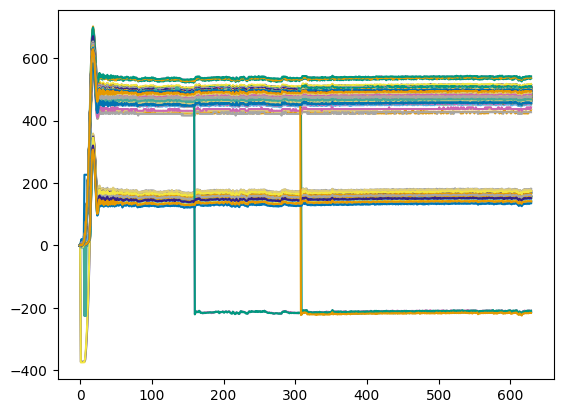

In [17]:
plt.plot(new_chip_data['curves']['well_temp_lin2d'].T)
plt.show()
plt.close()

In [18]:
idx_settled = new_chip_data['idxs']['idx_settled']
idx_end = new_chip_data['idxs']['idx_end']

ori_curves = new_chip_data['curves']['ori_curves']
y_well = new_chip_data['well_labels']
timestamps = new_chip_data['timestamps']
vref_idx = new_chip_data['metadata'].get('vref_idx', np.zeros_like(y_well))

temp_curves_raw = new_chip_data['curves']['well_temp_lin2d']
temp_group_idx = new_chip_data['metadata']['temp_group_idx']
num_wells = len(np.unique(y_well))
num_vrefs = len(np.unique(vref_idx))
N_tg = len(temp_curves_raw) // (num_vrefs * num_wells)

global_temp_idx = (vref_idx * num_wells + y_well) * N_tg + temp_group_idx
matched_temp_curves = temp_curves_raw[global_temp_idx]
matched_temp_curves = matched_temp_curves[:,idx_settled+4:idx_end]
if hasattr(config, "LABEL_MAPPINGS") and exp_folder in config.LABEL_MAPPINGS:
    print(f"[*] Applying custom target label mapping for experiment: {exp_folder}")
    mapping = config.LABEL_MAPPINGS[exp_folder]
    
    # Maps matching keys; falls back to the original index value if not found
    y_label = np.array([mapping.get(w, w) for w in y_well])
else:
    print(f"[*] No custom mapping found for {exp_folder}. Retaining default well labels.")
    y_label = np.array(y_well)

print()
print(f'ori_curves: {ori_curves.shape}')
print(f'vref_idx: {vref_idx.shape}')
print(f'y_well: {y_well.shape}')
print(f'y_label: {y_label.shape}')
print(f'timestamps: {timestamps.shape}')

[*] Applying custom target label mapping for experiment: D20260320_E00_C00_F4500KHz_U_Elena_steap_cv_nc_subtract

ori_curves: (16938, 602)
vref_idx: (16938,)
y_well: (16938,)
y_label: (16938,)
timestamps: (602,)


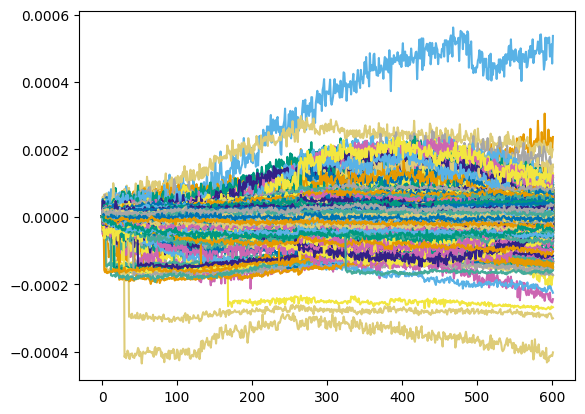

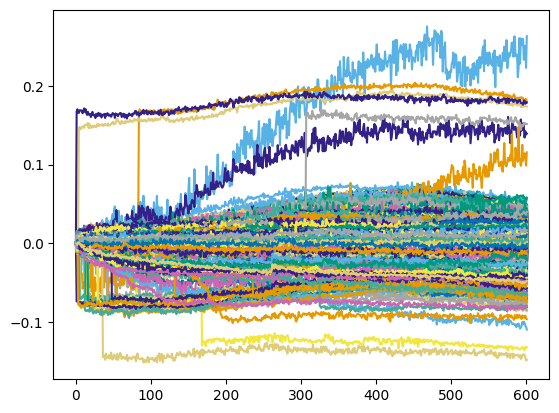

In [19]:
# valid_mask = ~np.isnan(matched_temp_curves)
# divided_result = np.divide(
#     ori_curves, 
#     matched_temp_curves, 
#     out=ori_curves.copy(), 
#     where=valid_mask
# )
divided_result = np.divide(ori_curves, matched_temp_curves)
# curve_mins = np.min(divided_result, axis=1, keepdims=True)
# curve_maxs = np.max(divided_result, axis=1, keepdims=True)
# divided_result = (divided_result - curve_mins) / (curve_maxs - curve_mins + 1e-8)

plt.plot(divided_result.T)
plt.show()
plt.close()
plt.plot(ori_curves.T)
plt.show()
plt.close()

In [ ]:
i = 0
while(i<10):
    i+=1

In [53]:
~np.isnan(matched_temp_curves).any(axis=1)

array([ True,  True,  True, ..., False, False, False])

In [65]:
matched_temp_curves[952]

array([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, in

In [68]:
np.sum(valid_mask)

8827

[*] Found top 30 indices with largest shape divergence: [13585 13684 13685 13636 13635 13634 13633 13587 13588 13589 13686 13683
 13725 13682 13724 13722 13723 13586 13632  9050   172  9102  6354  9279
  9105  6307  9101  9047  8707  9162]


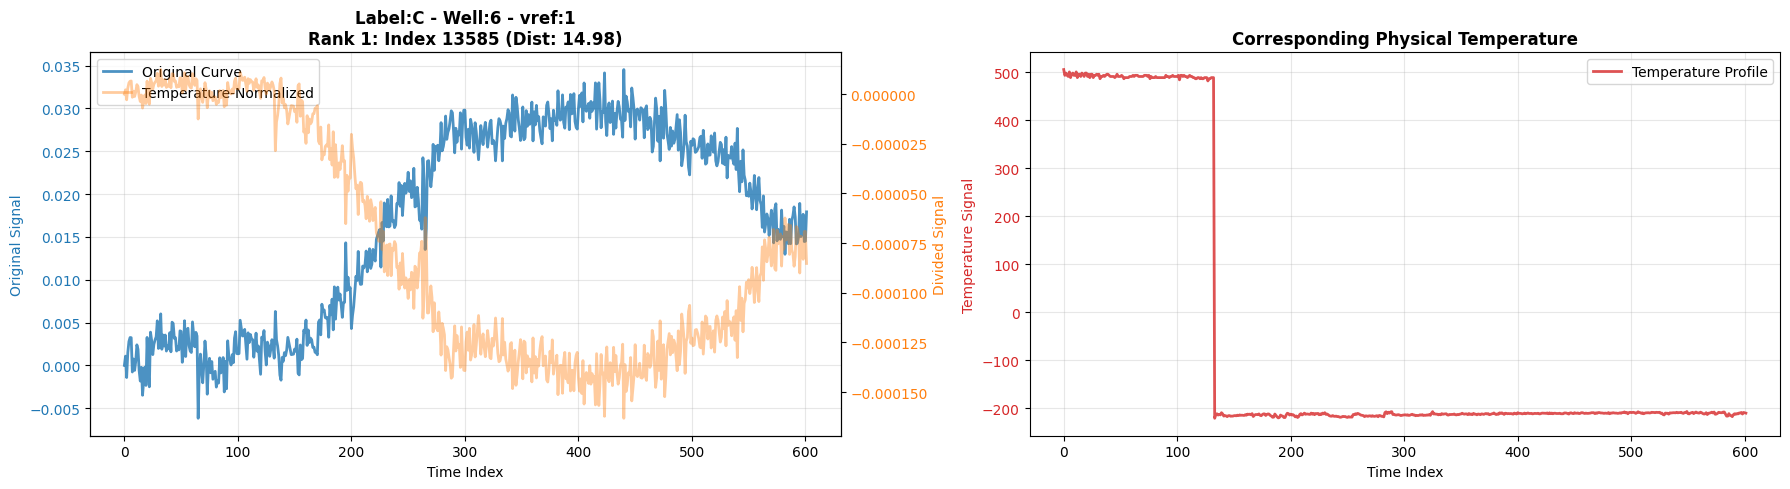

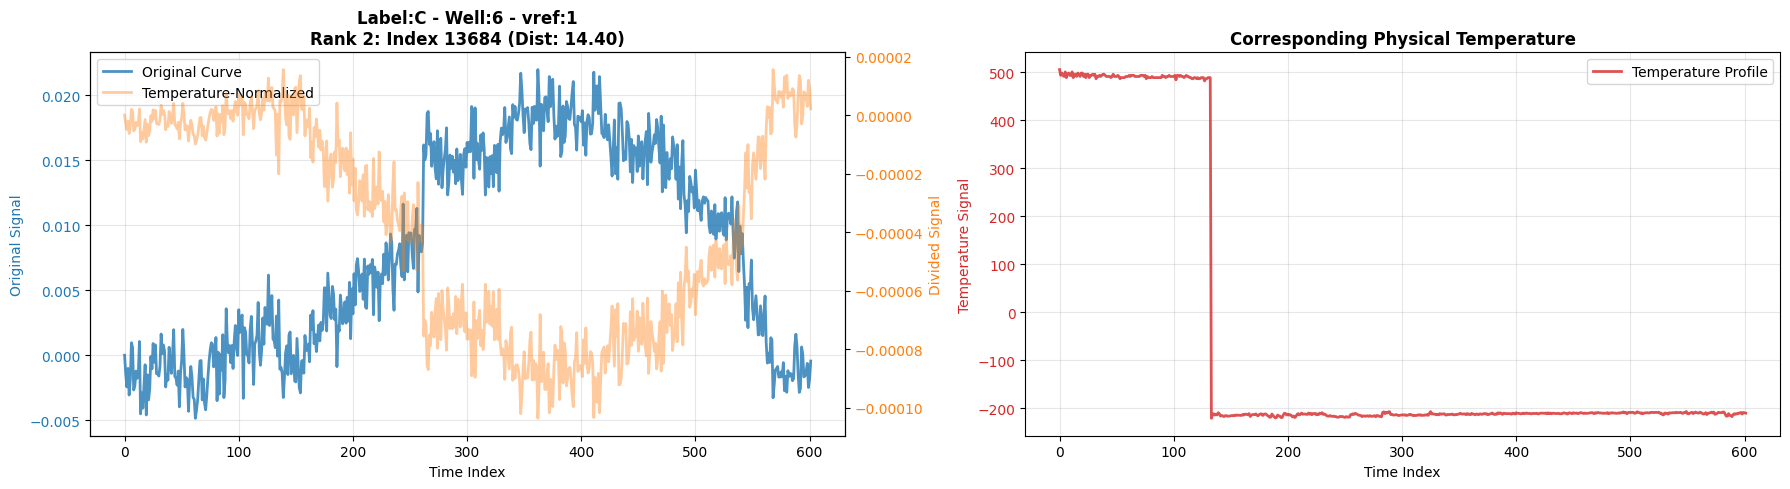

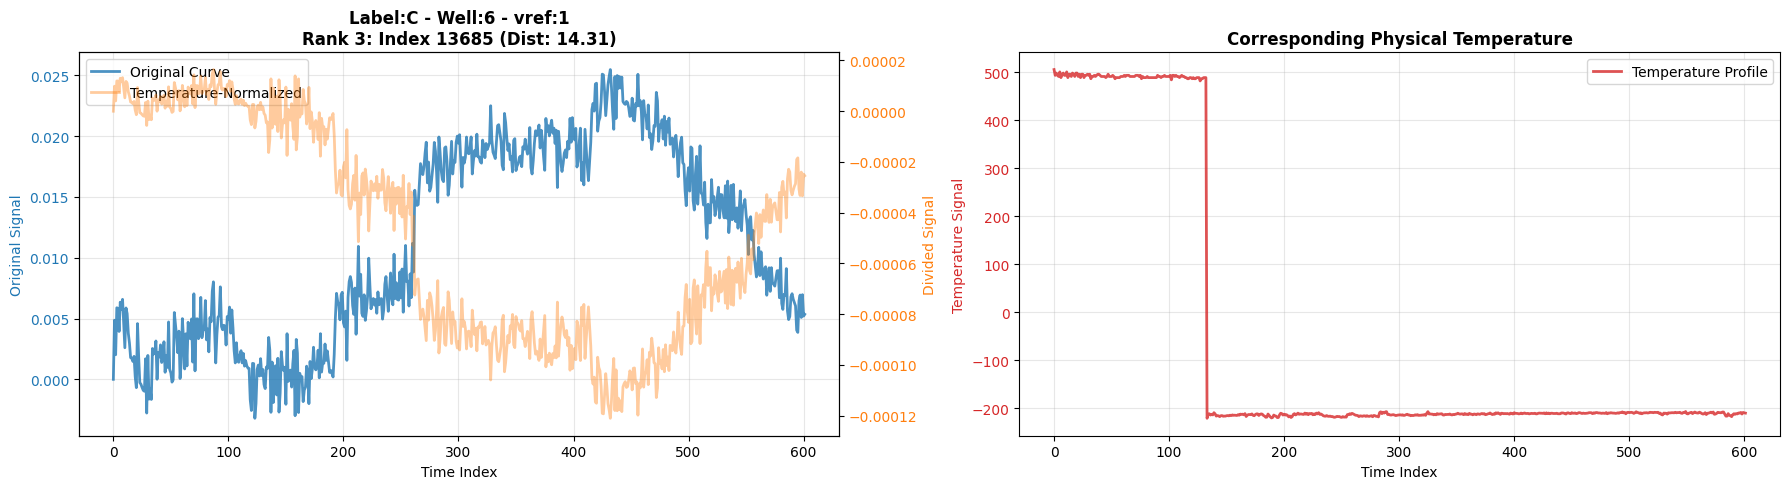

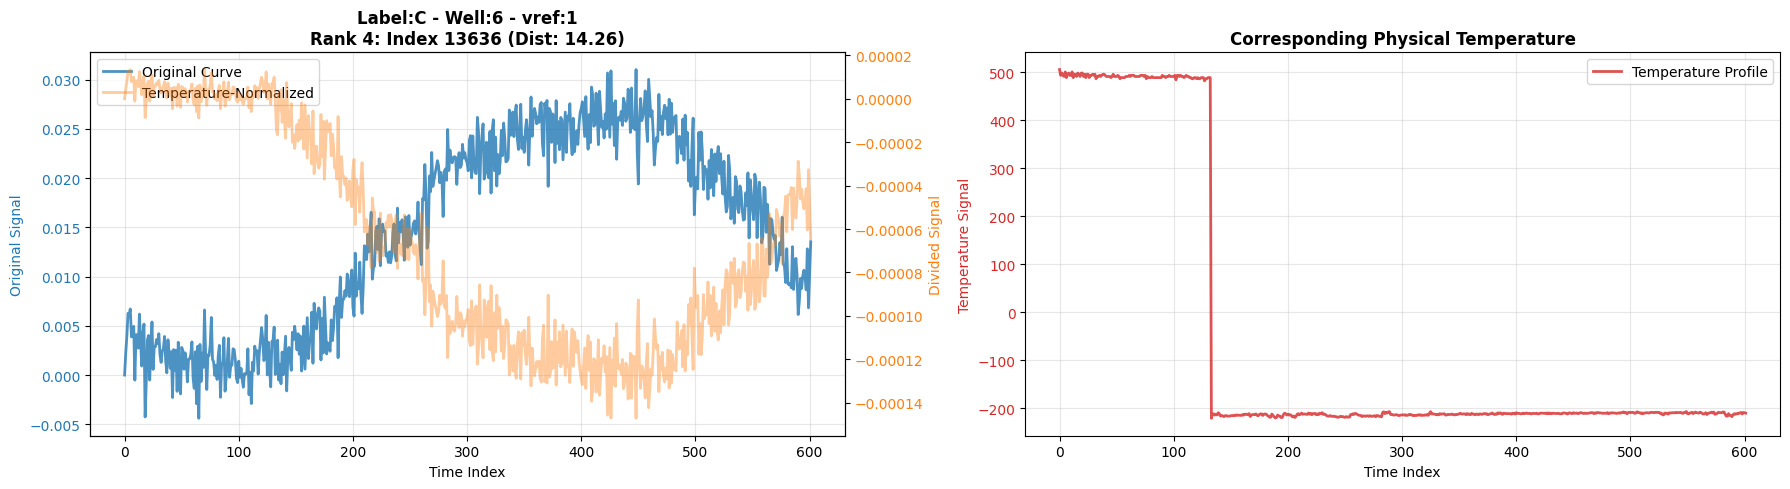

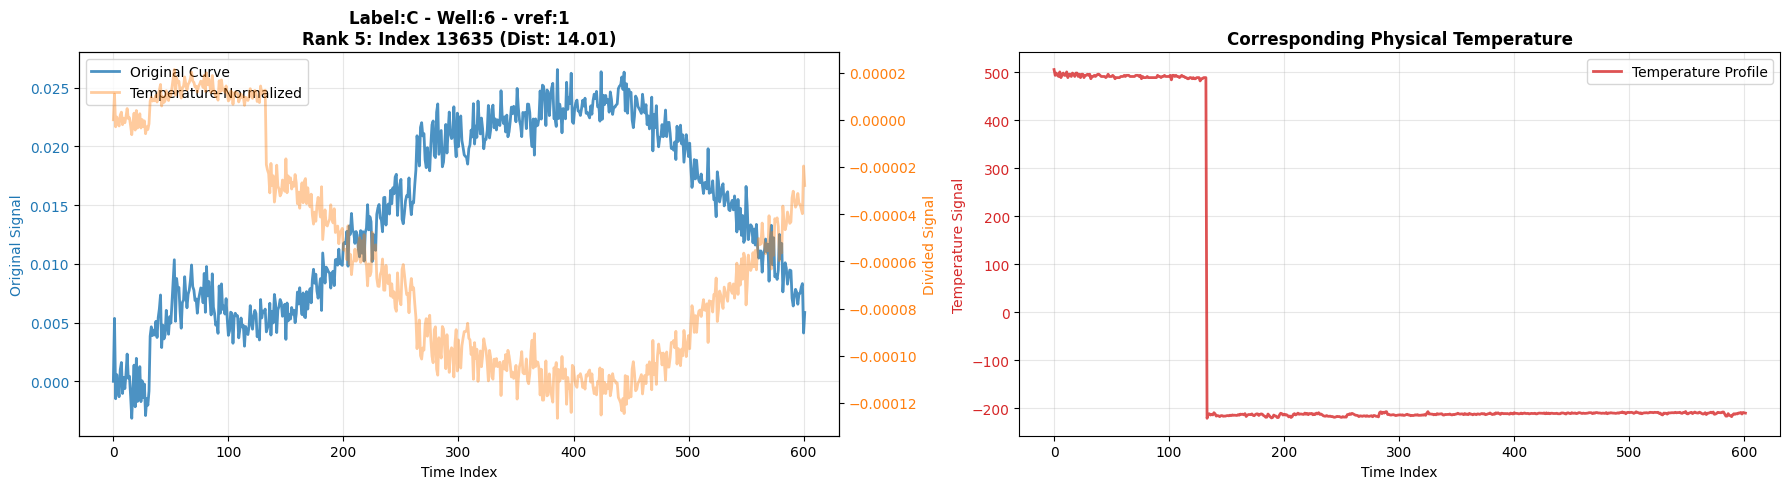

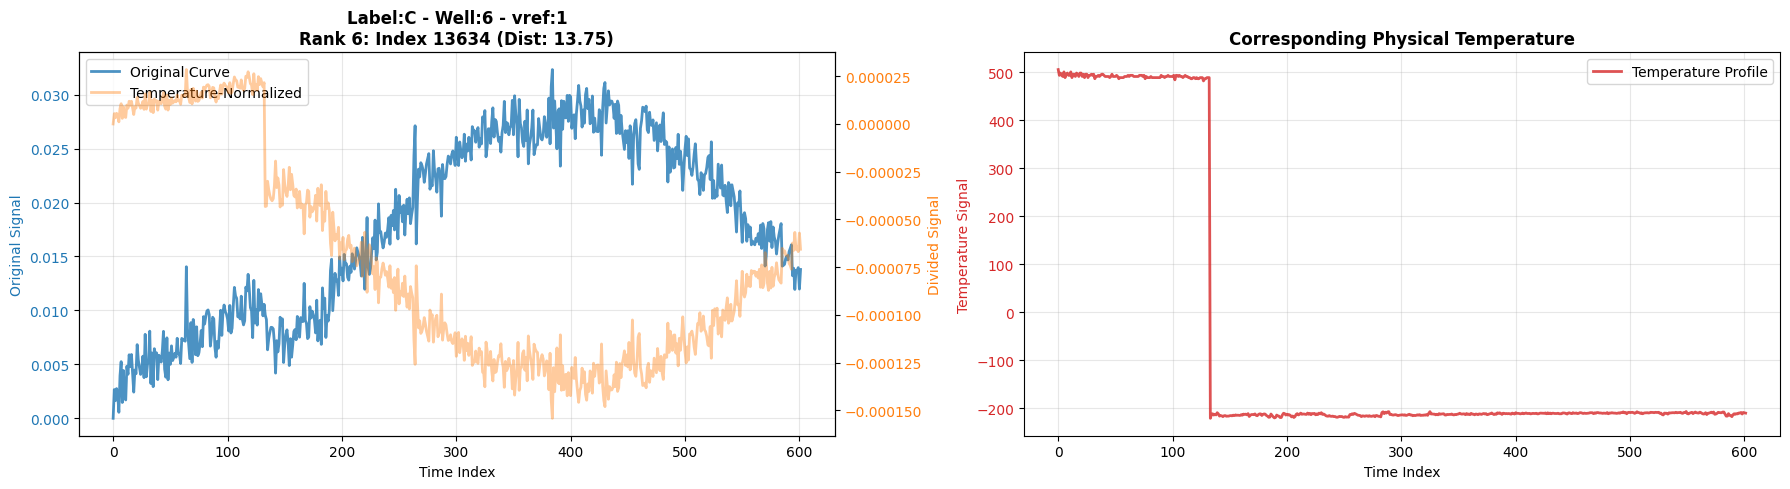

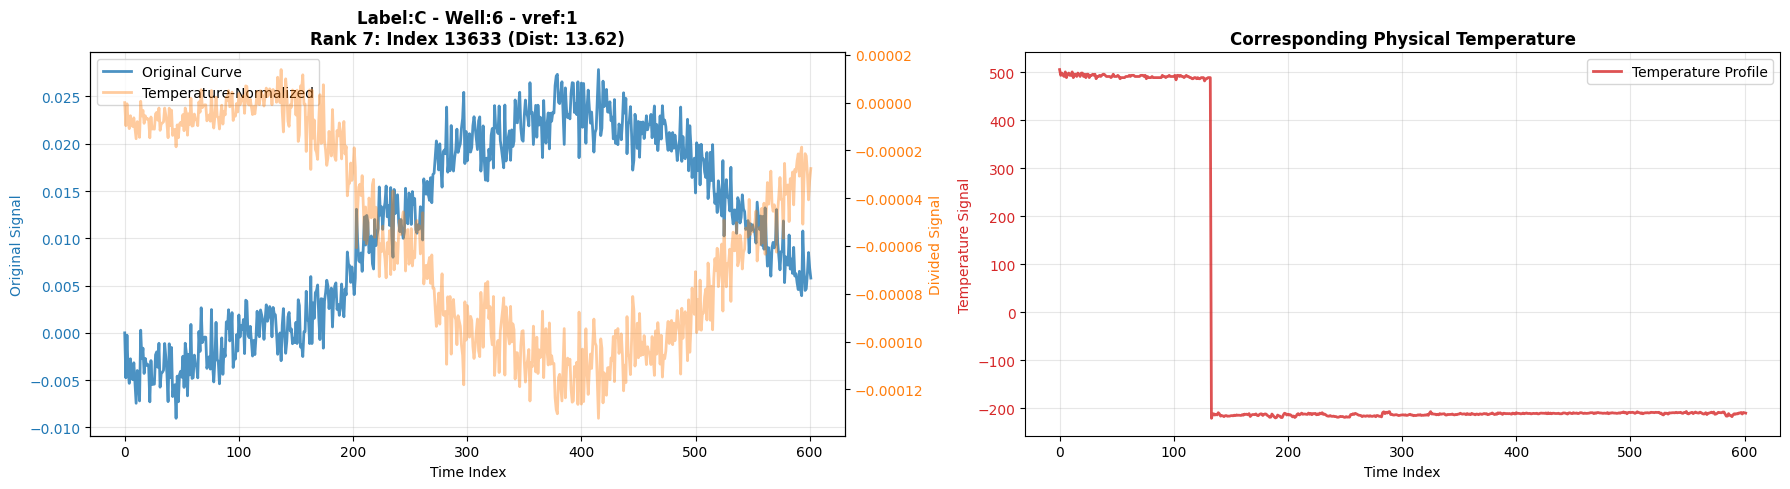

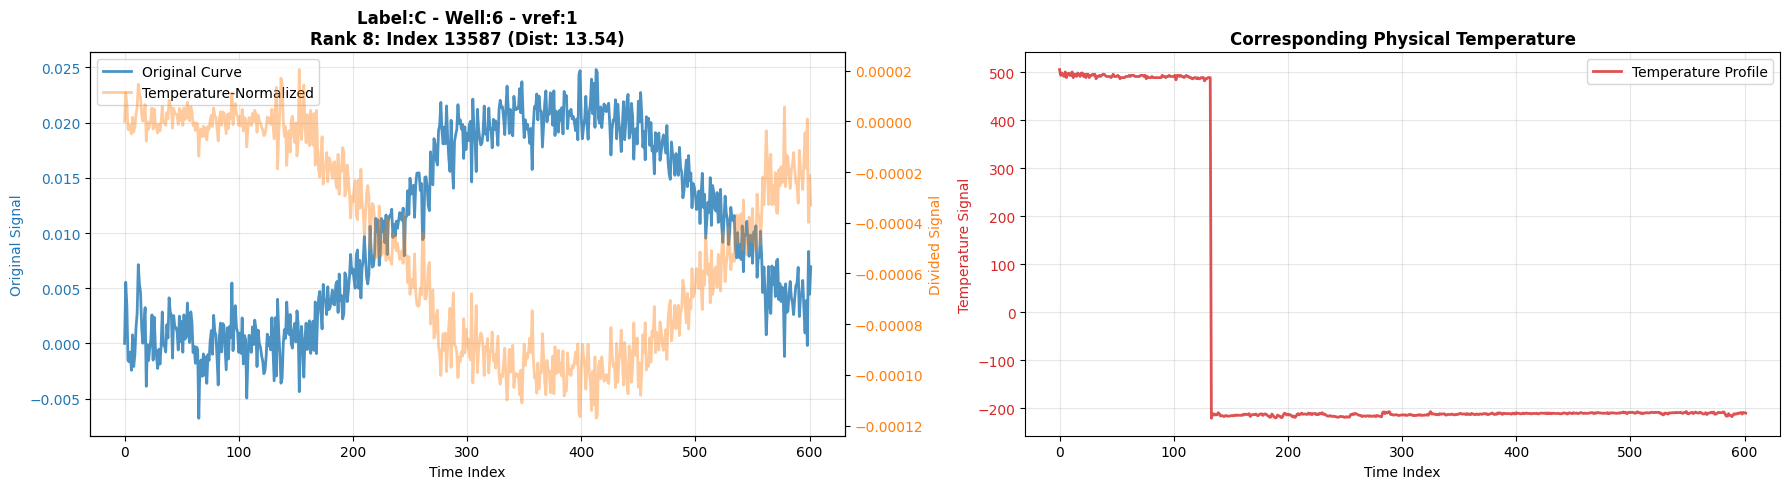

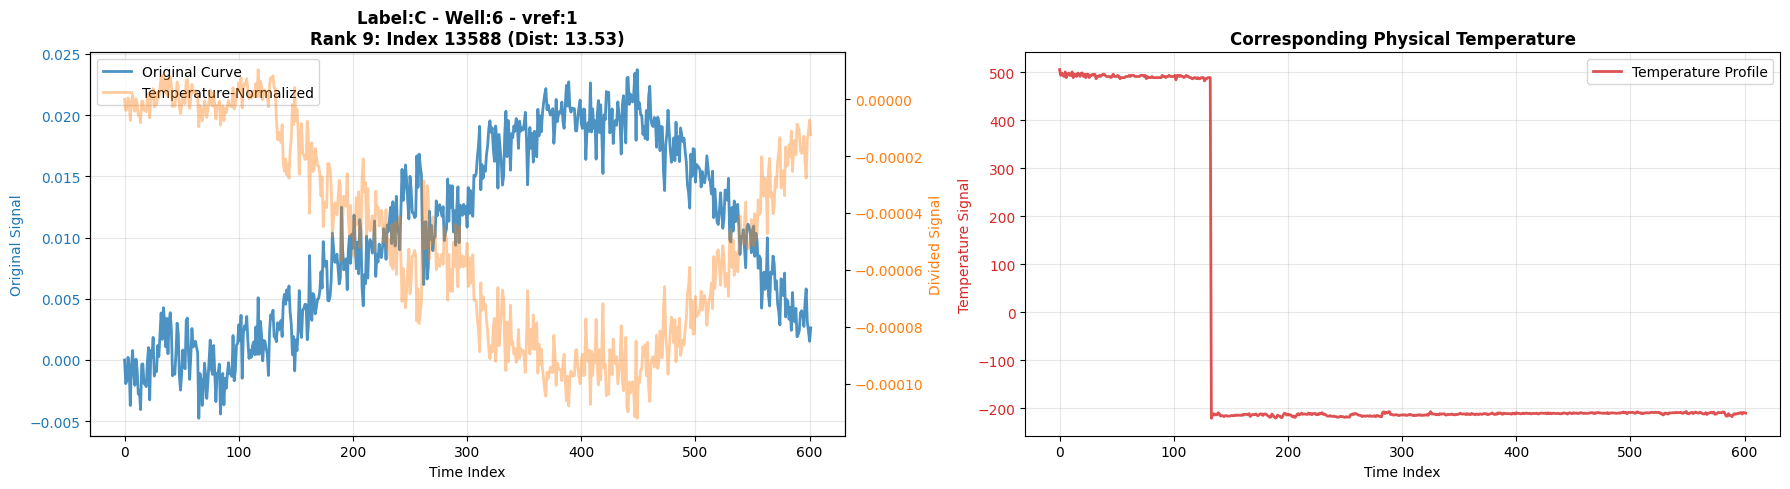

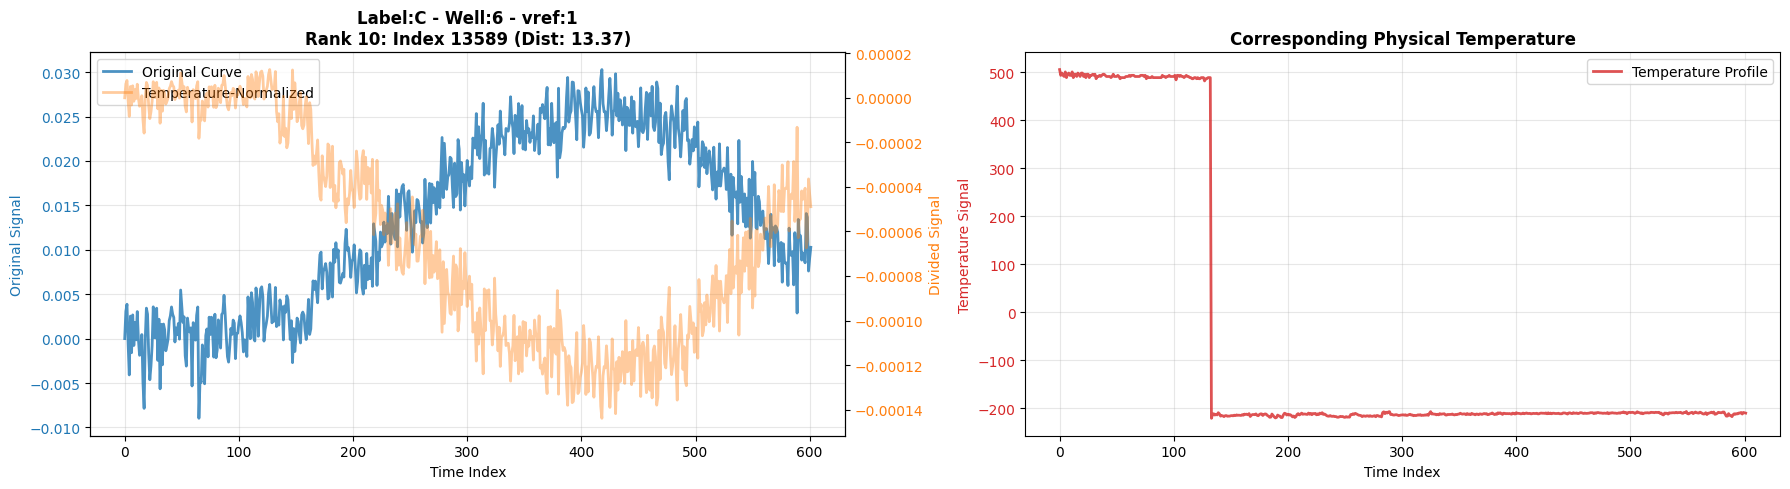

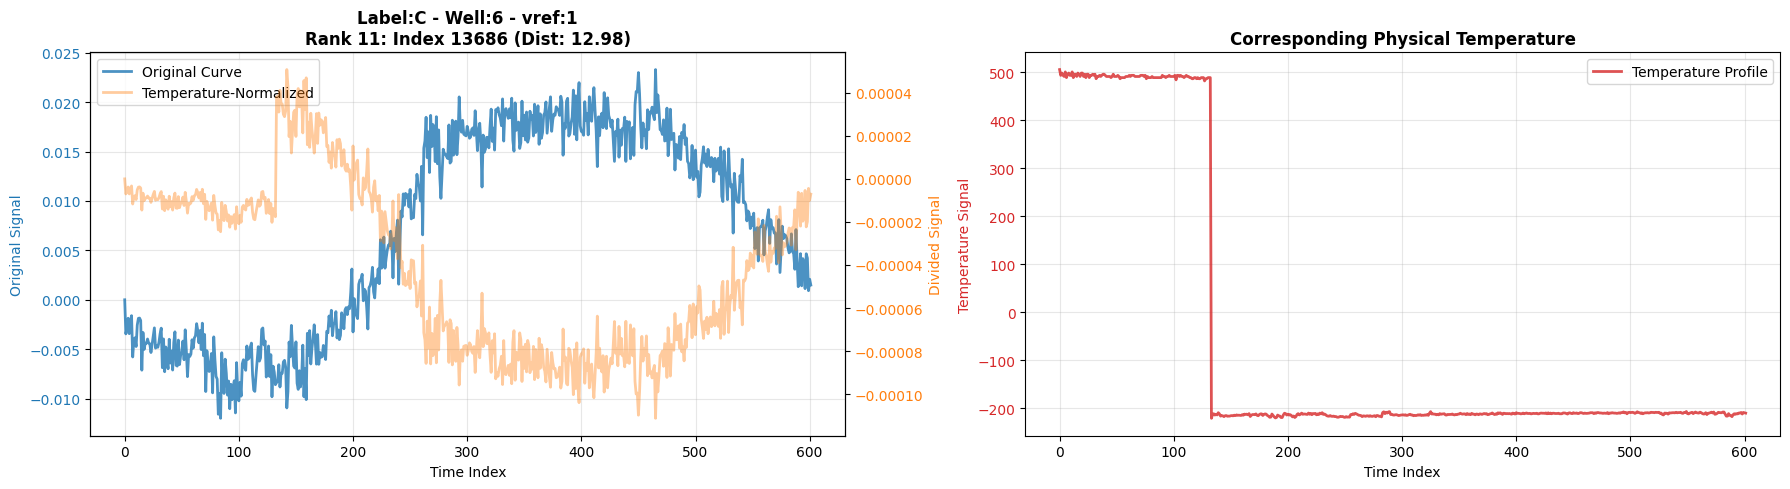

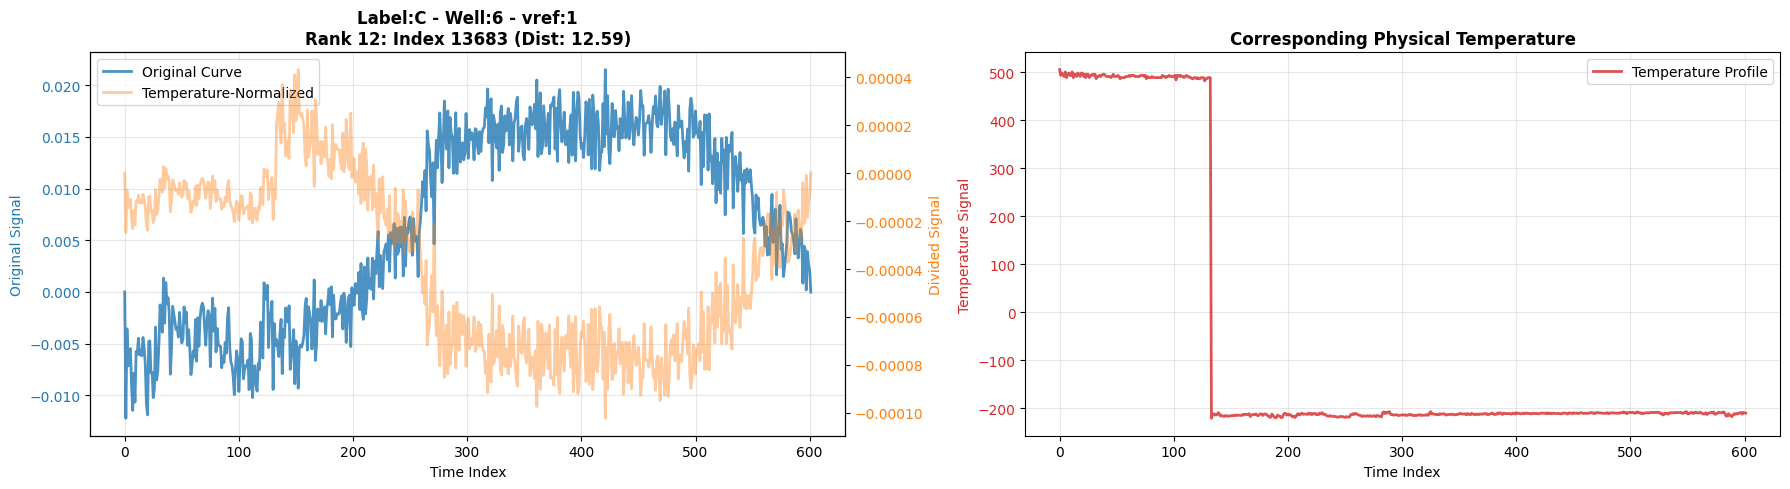

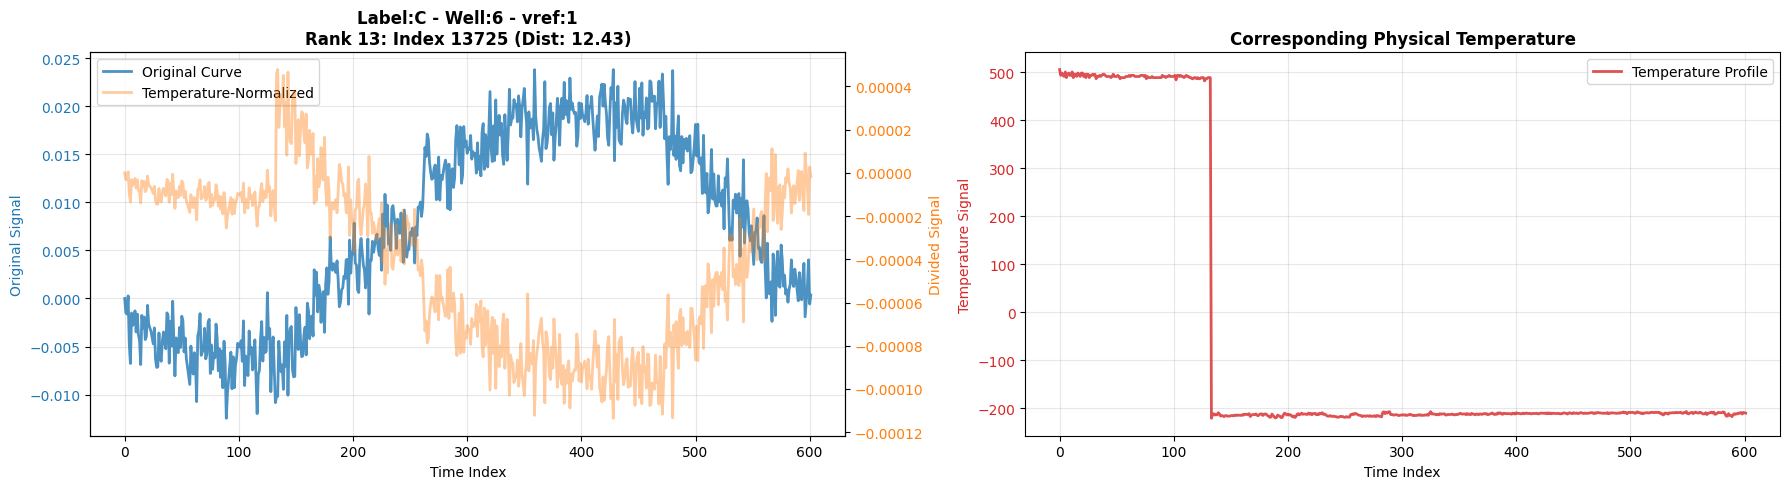

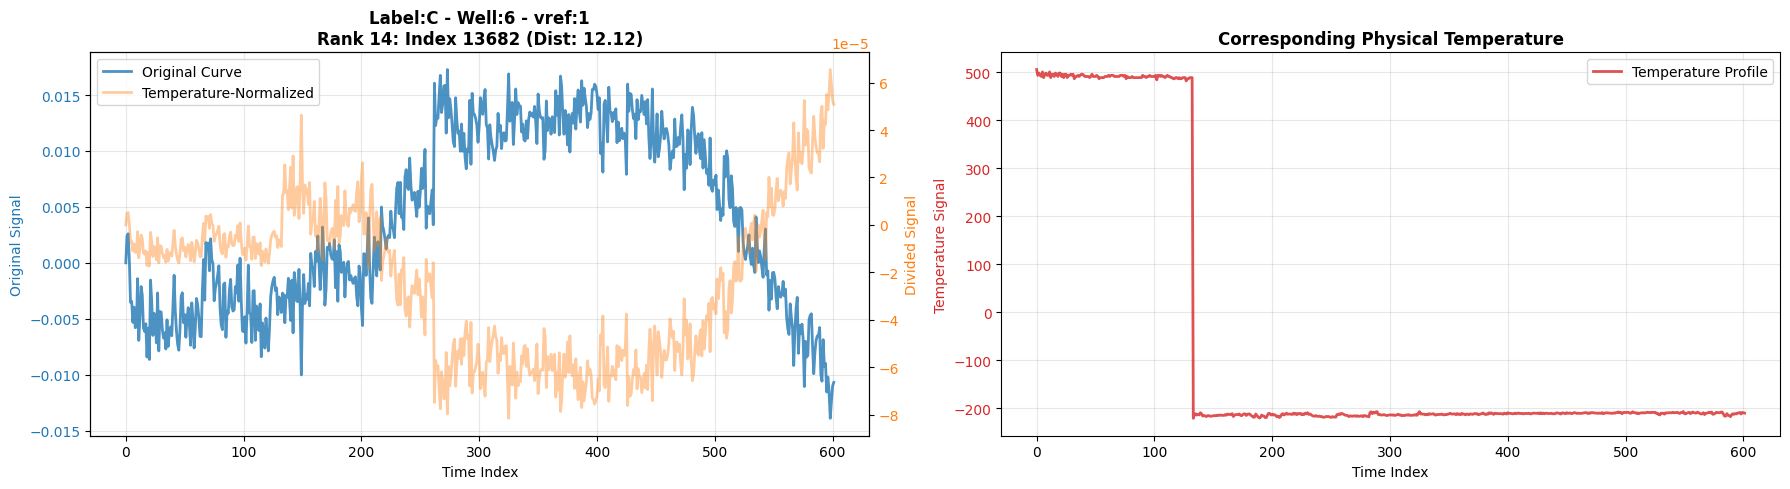

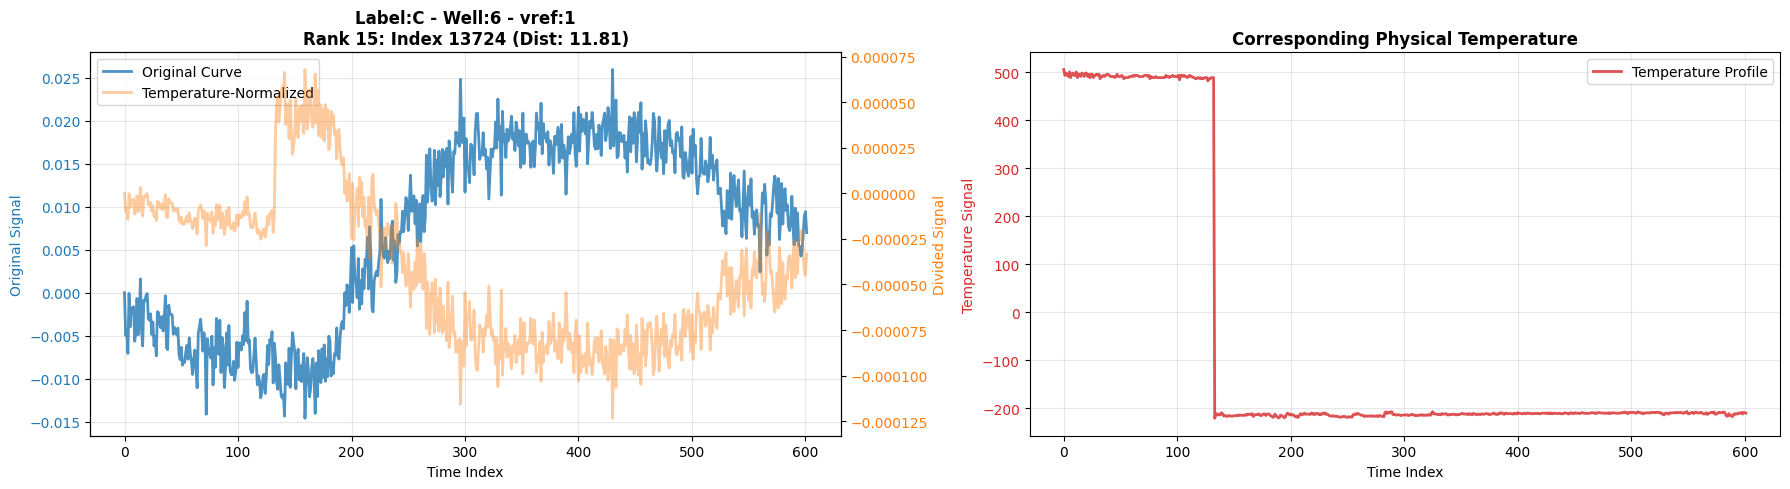

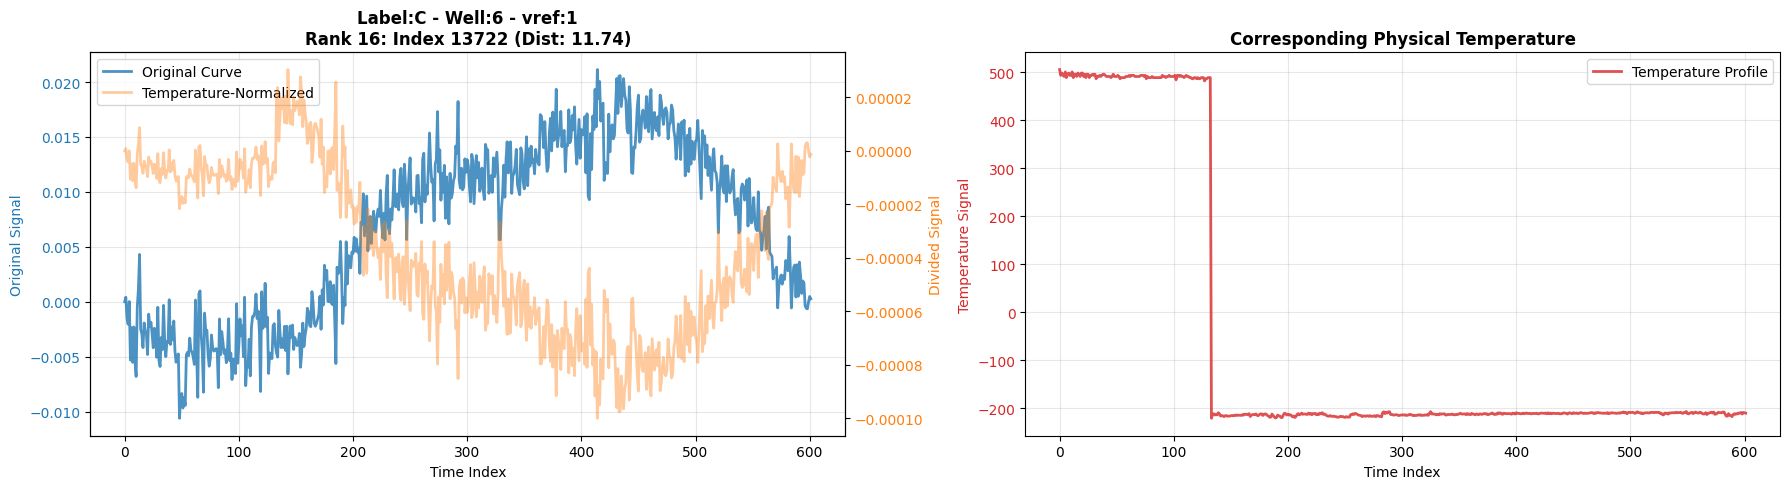

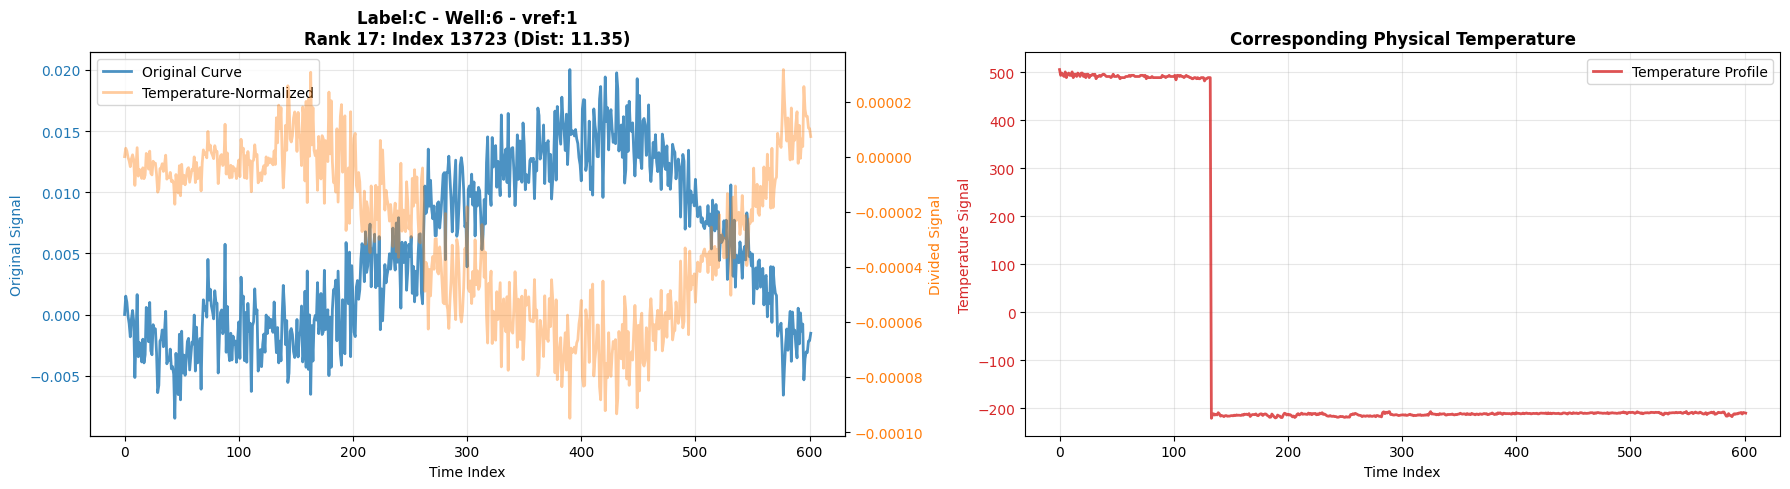

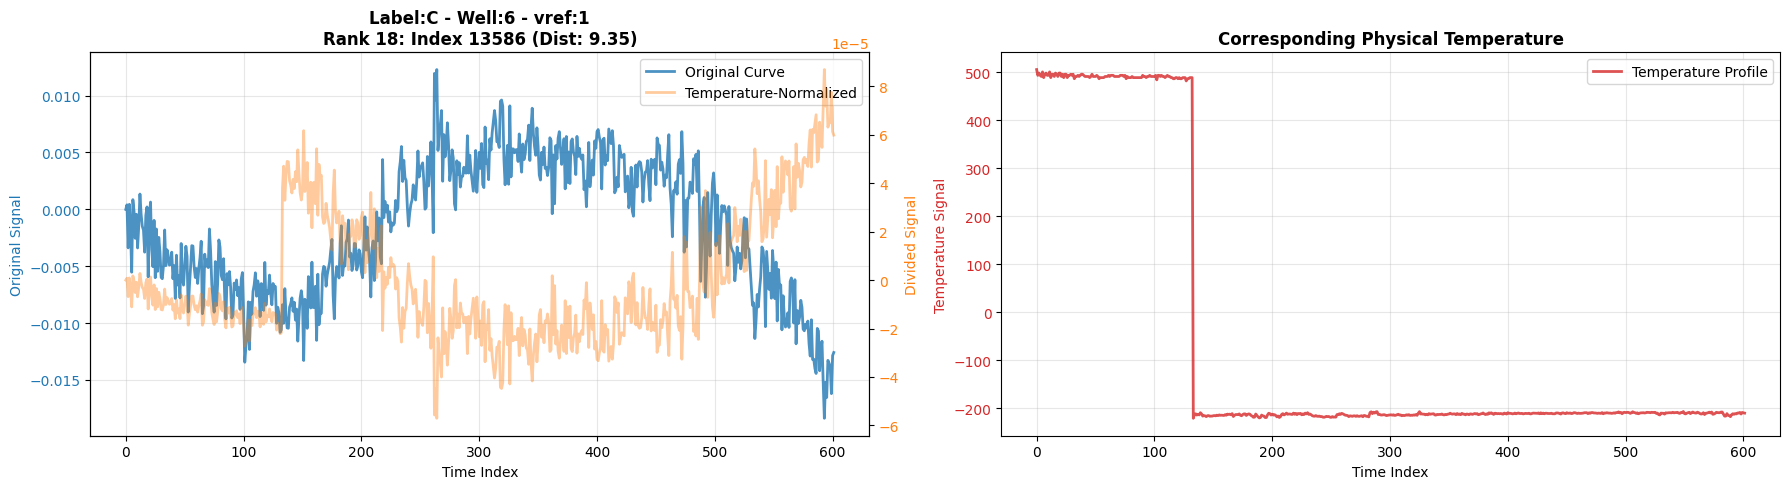

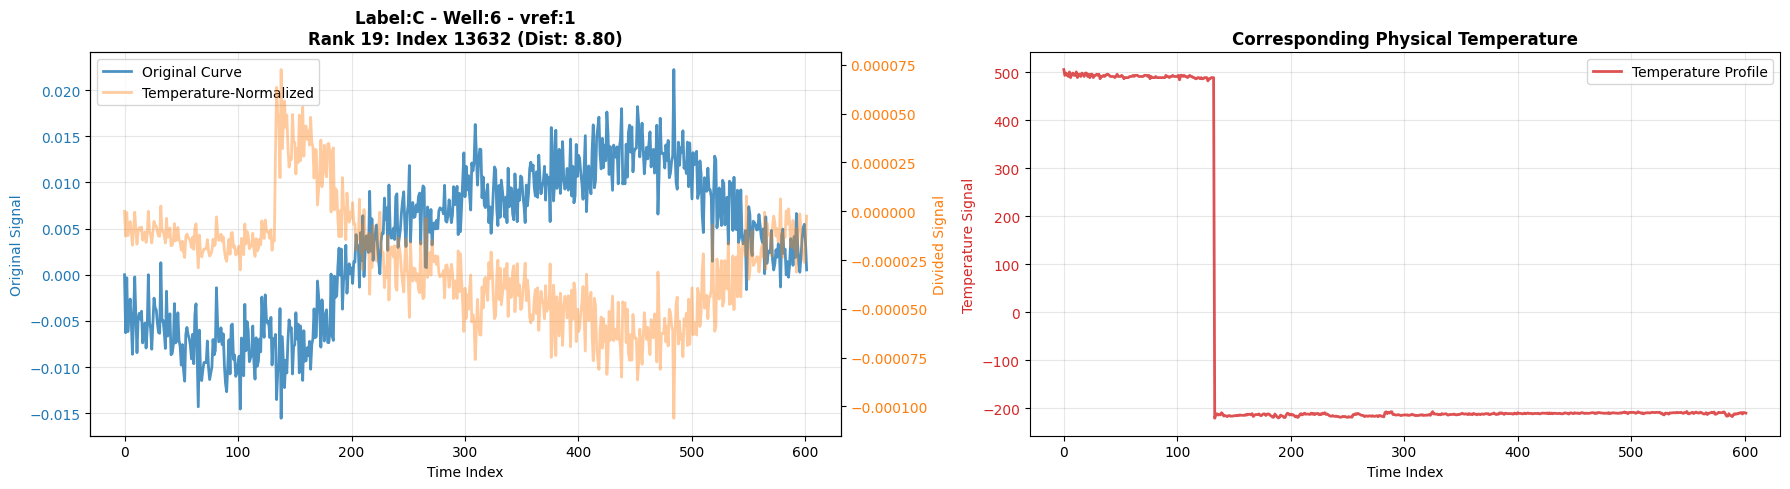

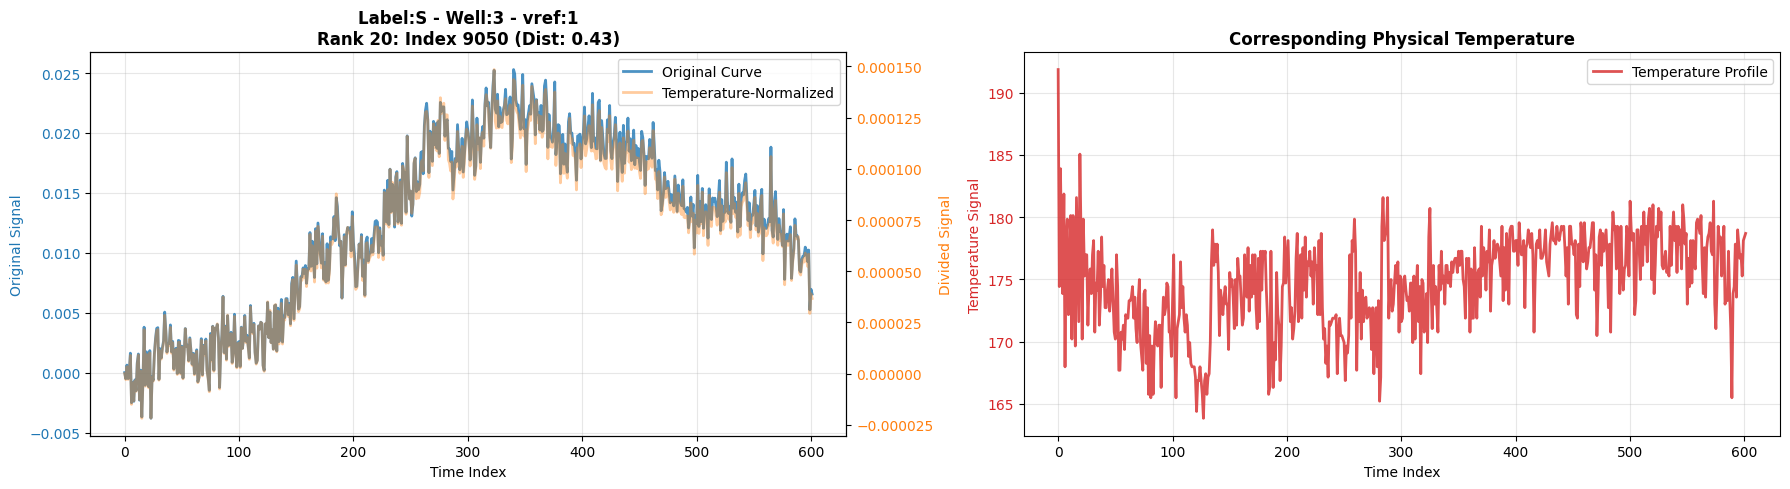

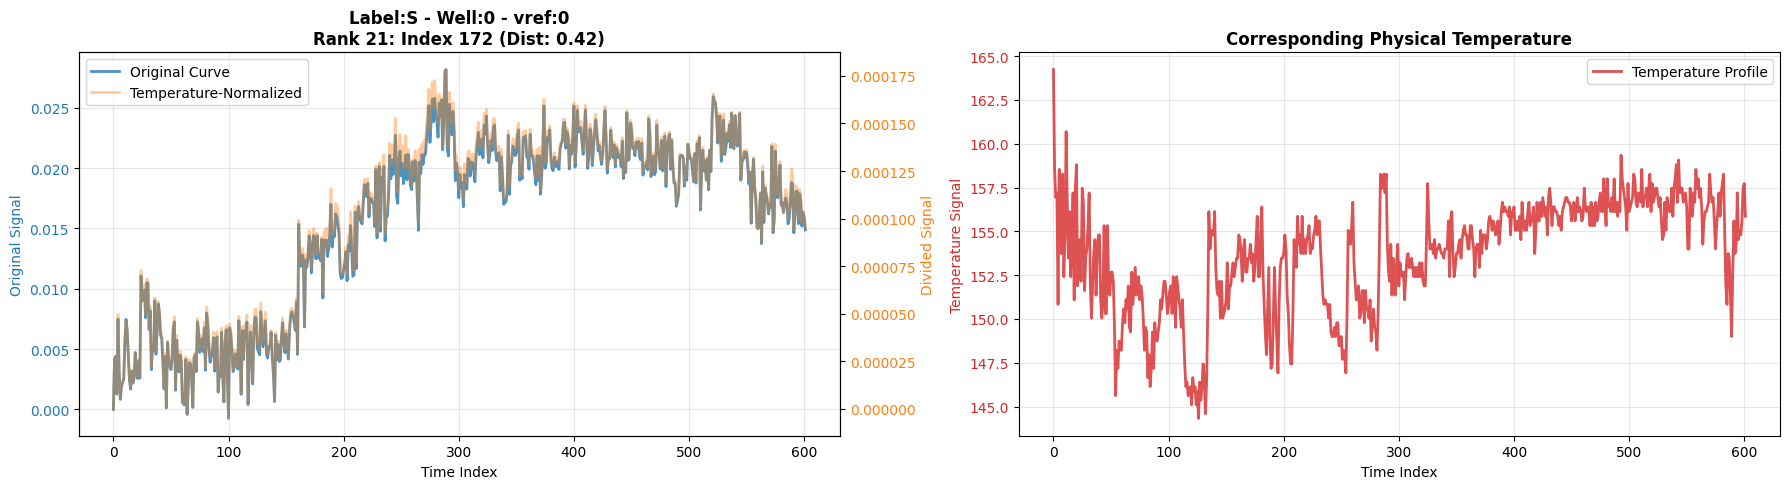

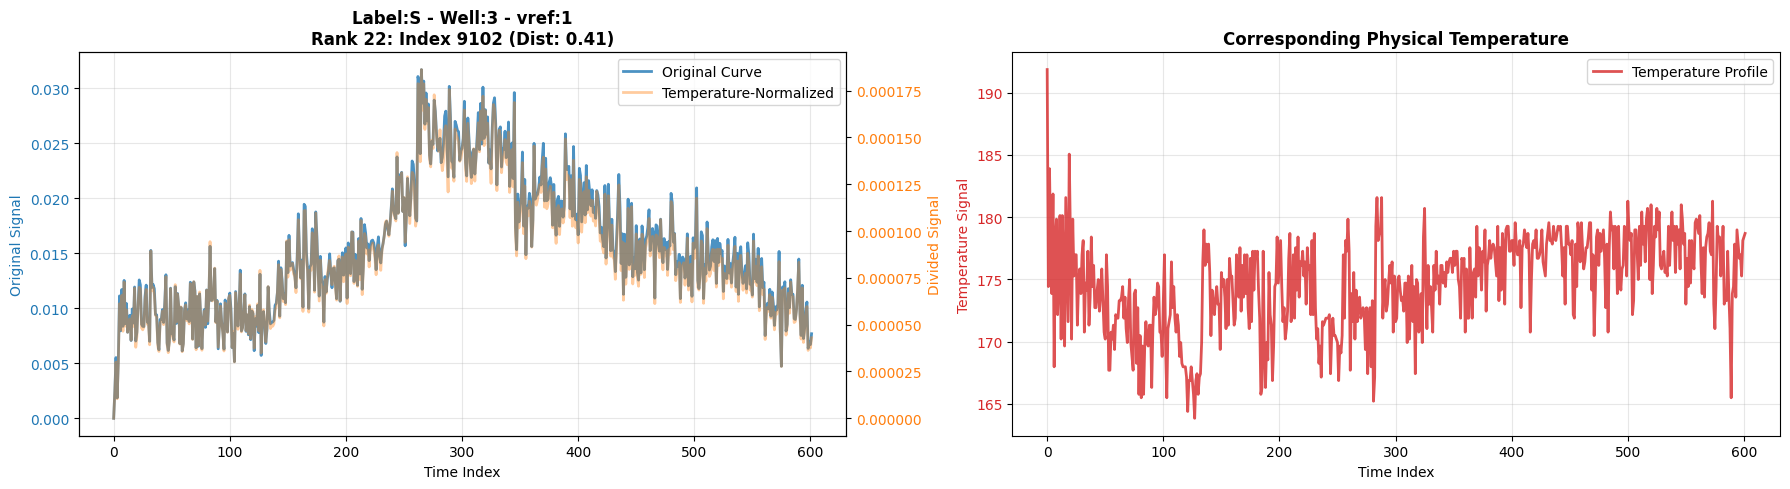

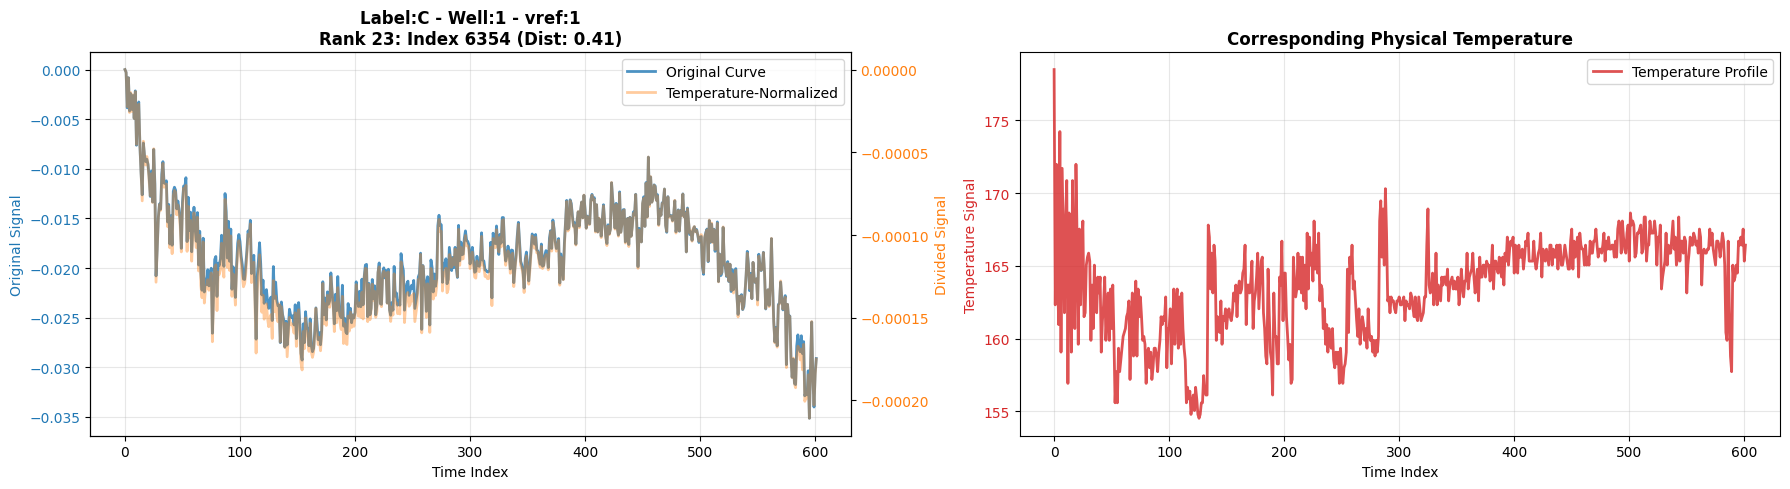

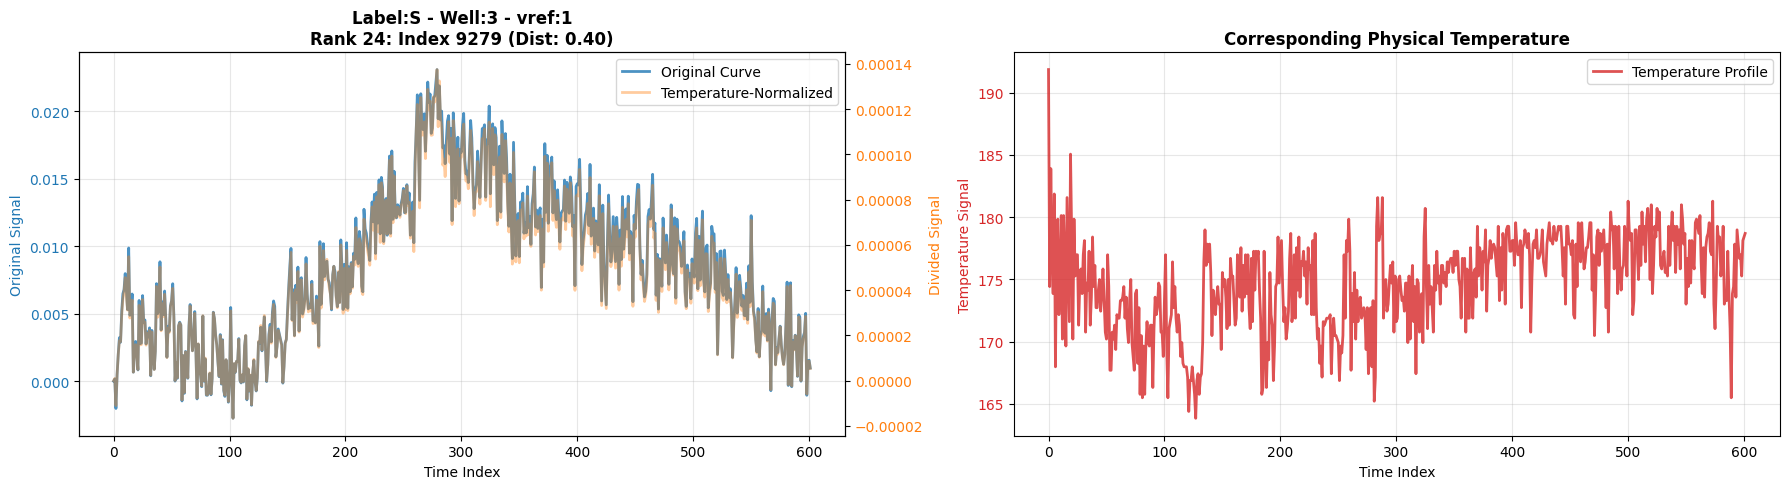

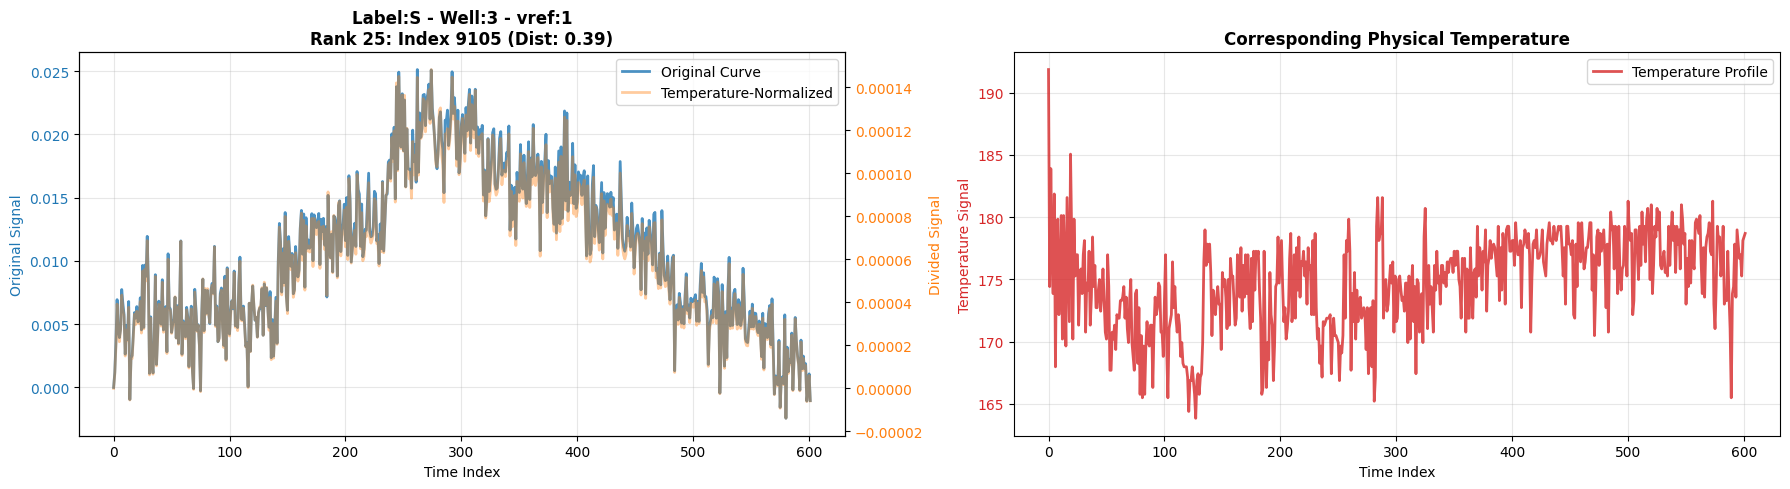

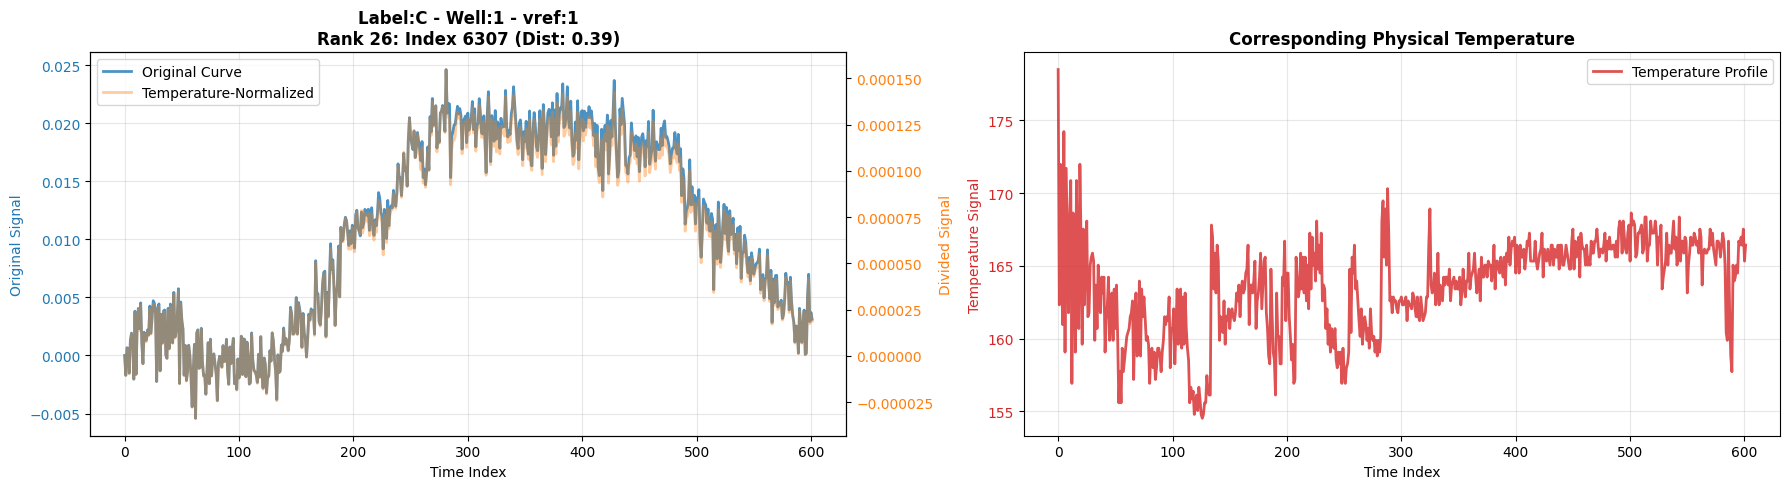

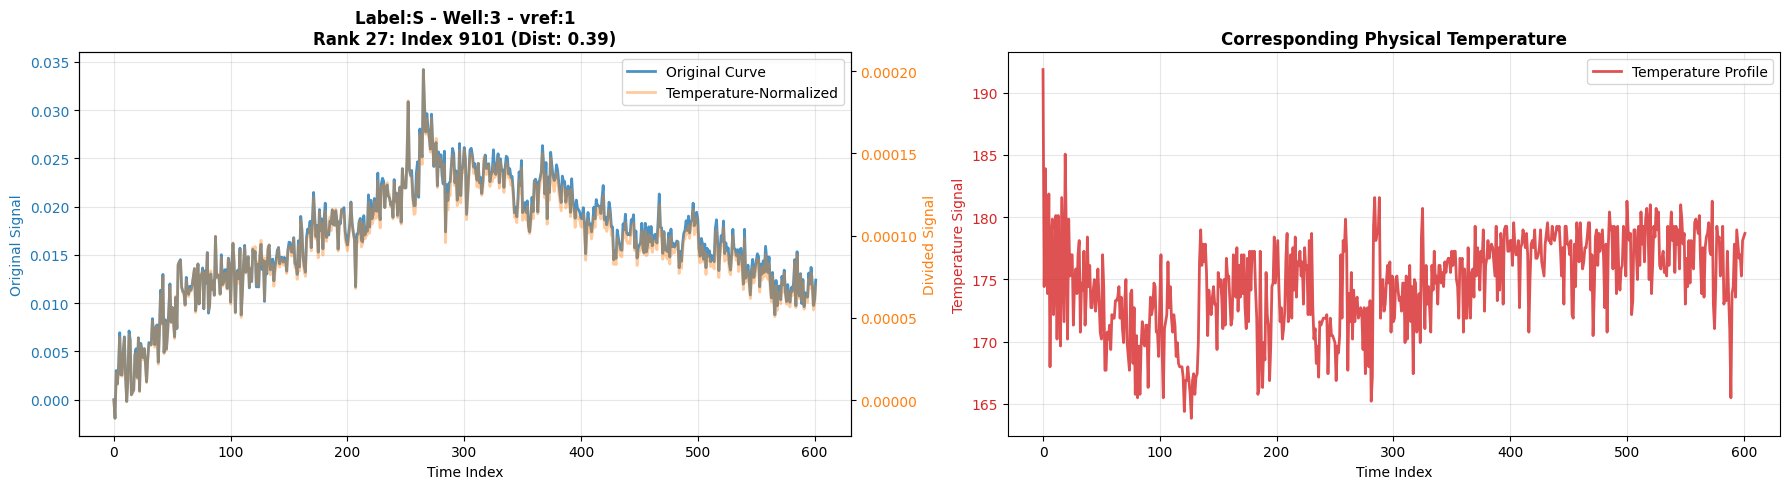

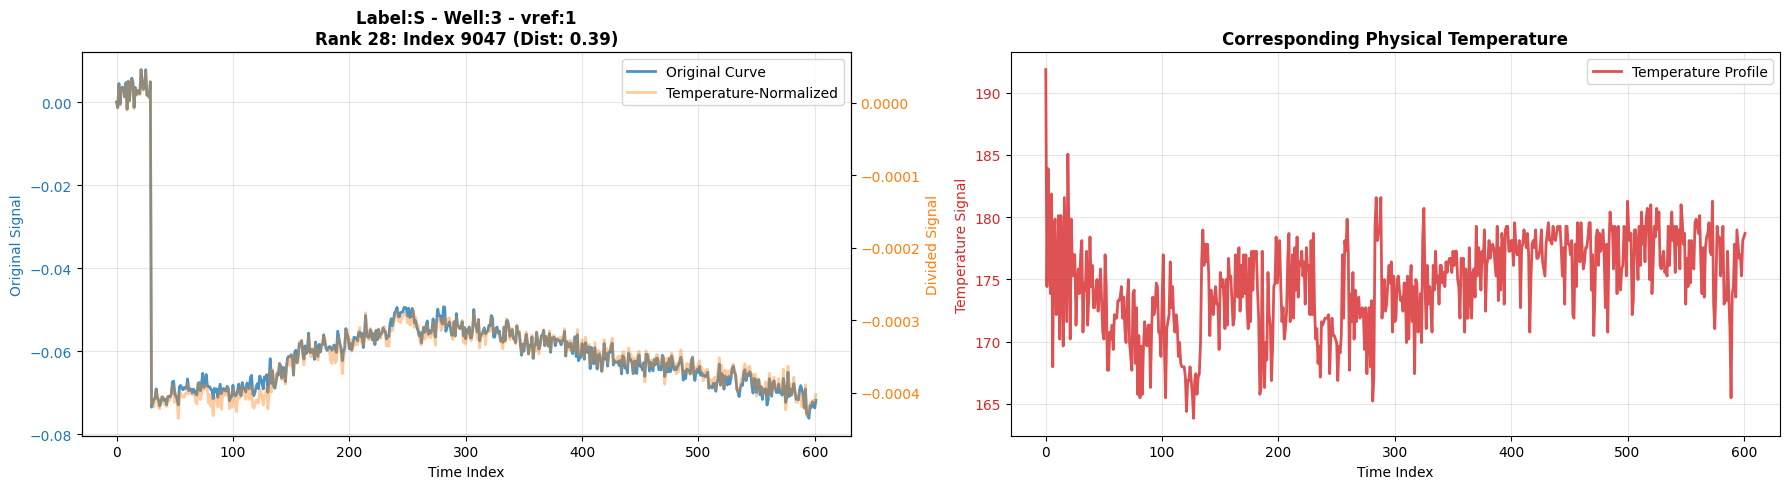

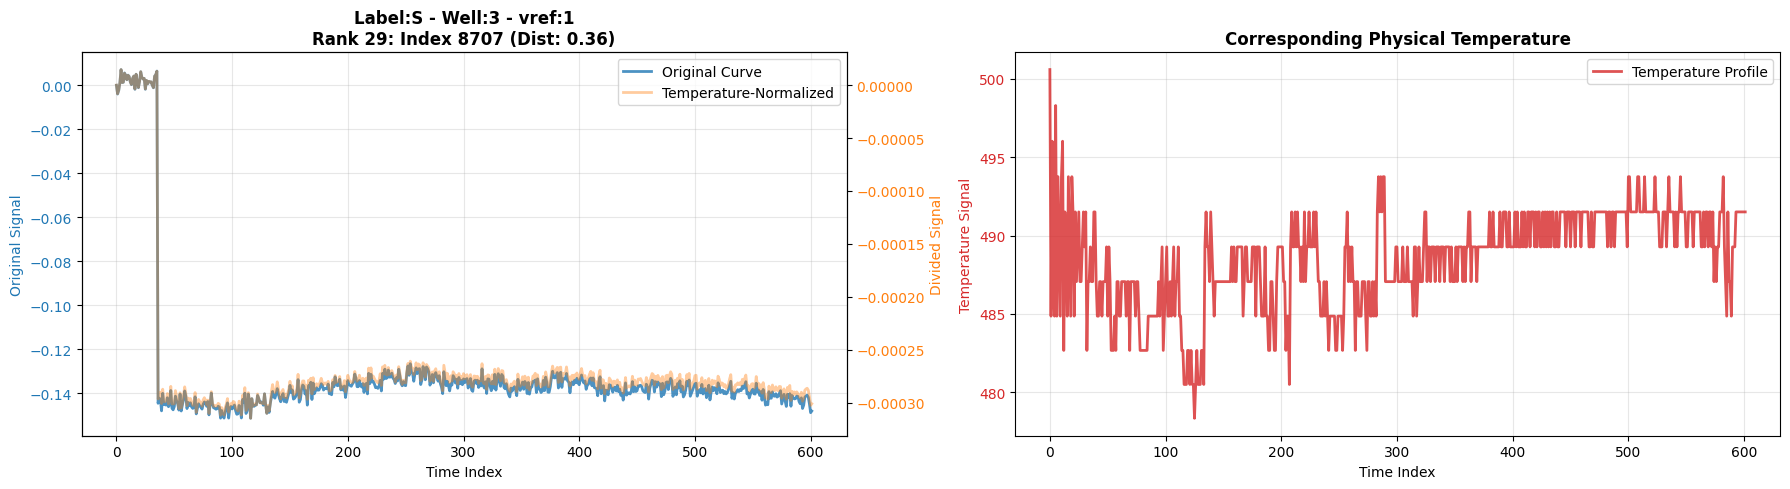

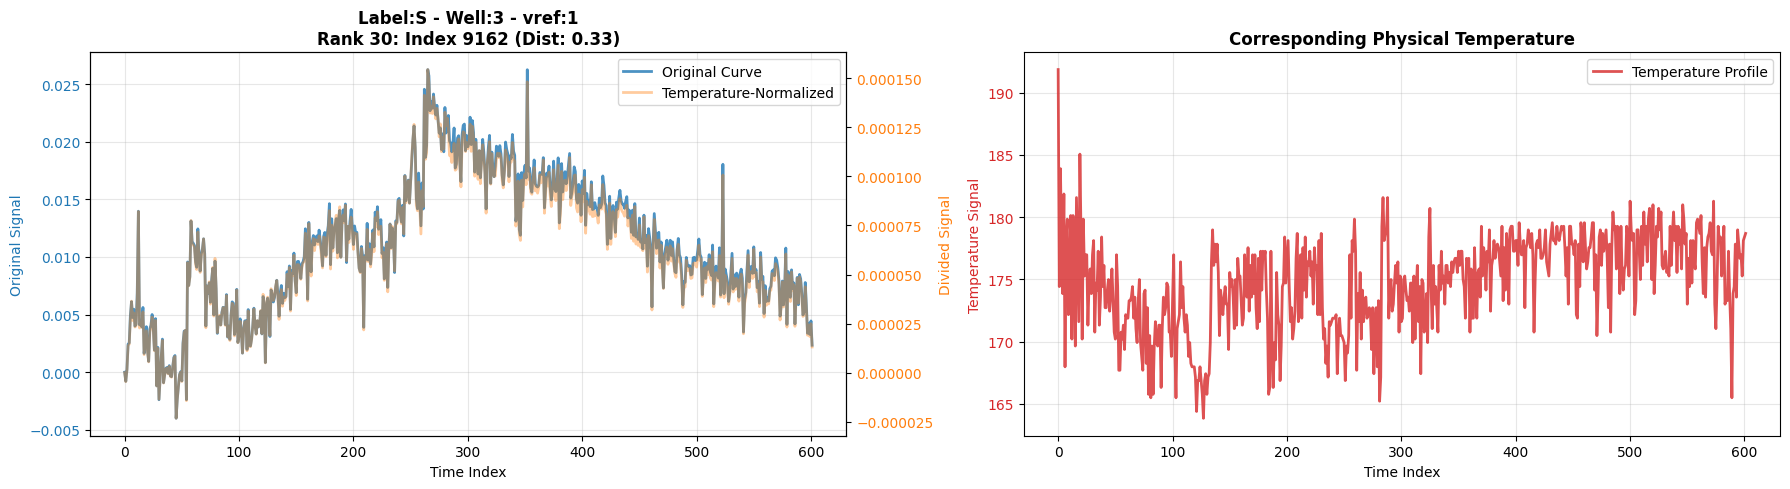

In [74]:
# 1. Filter out samples that contain NaNs in either array
# valid_mask = ~np.isnan(divided_result).any(axis=1) & ~np.isnan(ori_curves).any(axis=1)
valid_mask = ~np.isnan(divided_result).any(axis=1) & ~np.isnan(ori_curves).any(axis=1) & ~np.isnan(matched_temp_curves).any(axis=1) & ~np.isinf(matched_temp_curves).any(axis=1)
valid_indices = np.where(valid_mask)[0]

# Extract only the valid curves for calculation
valid_ori = ori_curves[valid_indices]
valid_div = divided_result[valid_indices]

# 2. Helper function to scale curves from 0 to 1 (per curve)
def min_max_scale(arr):
    min_val = np.min(arr, axis=1, keepdims=True)
    max_val = np.max(arr, axis=1, keepdims=True)
    
    # Prevent division by zero if a curve is completely flat
    val_range = max_val - min_val
    val_range[val_range == 0] = 1e-10 
    
    return (arr - min_val) / val_range

# 3. Scale both sets of curves
ori_scaled = min_max_scale(valid_ori)
div_scaled = min_max_scale(valid_div)

# 4. Calculate Euclidean distance between the scaled shapes
# np.linalg.norm with axis=1 computes the Euclidean distance for each row
distances = np.linalg.norm(ori_scaled - div_scaled, axis=1)

# 5. Get the indices of the top 10 largest distances
# argsort sorts ascending, so [::-1] reverses it to descending, and [:10] takes the top 10
n_sample = 30
top_n_relative_indices = np.argsort(distances)[::-1][:n_sample]

# Map back to the absolute indices of the original arrays
top_n_absolute_indices = valid_indices[top_n_relative_indices]

print(f"[*] Found top {n_sample} indices with largest shape divergence: {top_n_absolute_indices}")

# 6. Plot the Top 10 results in 2 Columns
for rank, sample_idx in enumerate(top_n_absolute_indices):
    dist_score = distances[top_n_relative_indices[rank]]
    
    # Setup a 1x2 figure layout (1 row, 2 columns)
    fig, (ax1, ax_temp) = plt.subplots(1, 2, figsize=(18, 5))

    # =======================================================
    # COLUMN 1: Original vs Normalized Curve
    # =======================================================
    ax2 = ax1.twinx() # Attach twin axis only to the first column

    line1, = ax1.plot(
        ori_curves[sample_idx, :].T,
        label='Original Curve',
        linewidth=2,
        color='tab:blue',
        alpha=0.8
    )
    line2, = ax2.plot(
        divided_result[sample_idx, :].T,
        label='Temperature-Normalized',
        linewidth=2,
        color='tab:orange',
        alpha=0.4
    )

    ax1.set_xlabel('Time Index')
    ax1.set_ylabel('Original Signal', color='tab:blue')
    ax2.set_ylabel('Divided Signal', color='tab:orange')
    ax1.set_title(f'Label:{y_label[sample_idx]} - Well:{y_well[sample_idx]} - vref:{vref_idx[sample_idx]}\nRank {rank + 1}: Index {sample_idx} (Dist: {dist_score:.2f})', fontweight='bold')
    
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='best')

    # =======================================================
    # COLUMN 2: Temperature Curve
    # =======================================================
    ax_temp.plot(
        matched_temp_curves[sample_idx, :].T,
        label='Temperature Profile',
        linewidth=2,
        color='tab:red',
        alpha=0.8
    )
    
    ax_temp.set_xlabel('Time Index')
    ax_temp.set_ylabel('Temperature Signal', color='tab:red')
    ax_temp.set_title('Corresponding Physical Temperature', fontweight='bold')
    
    ax_temp.grid(True, alpha=0.3)
    ax_temp.tick_params(axis='y', labelcolor='tab:red')
    ax_temp.legend(loc='best')

    # Render layout
    plt.tight_layout()
    plt.show()
    plt.close()


--- STAGE 1: Matrix Grid (Well vs VREF) ---


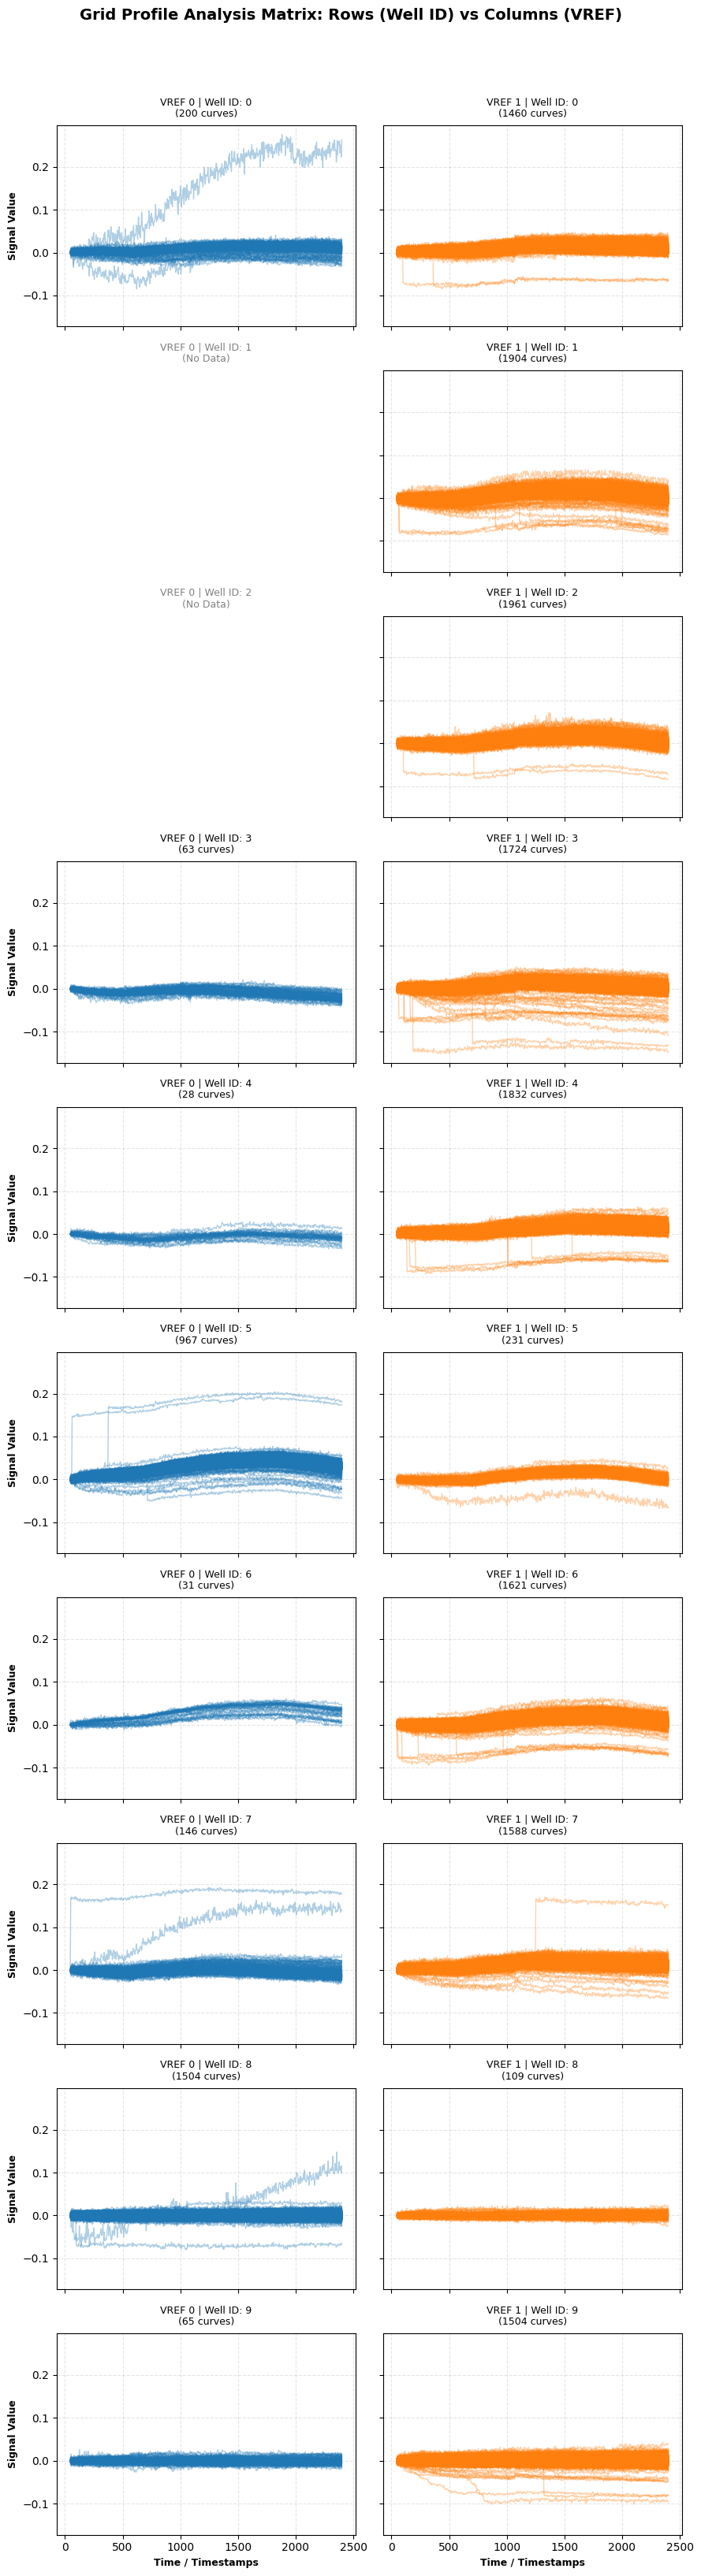


--- STAGE 2: Matrix Grid (Target Label vs VREF) ---


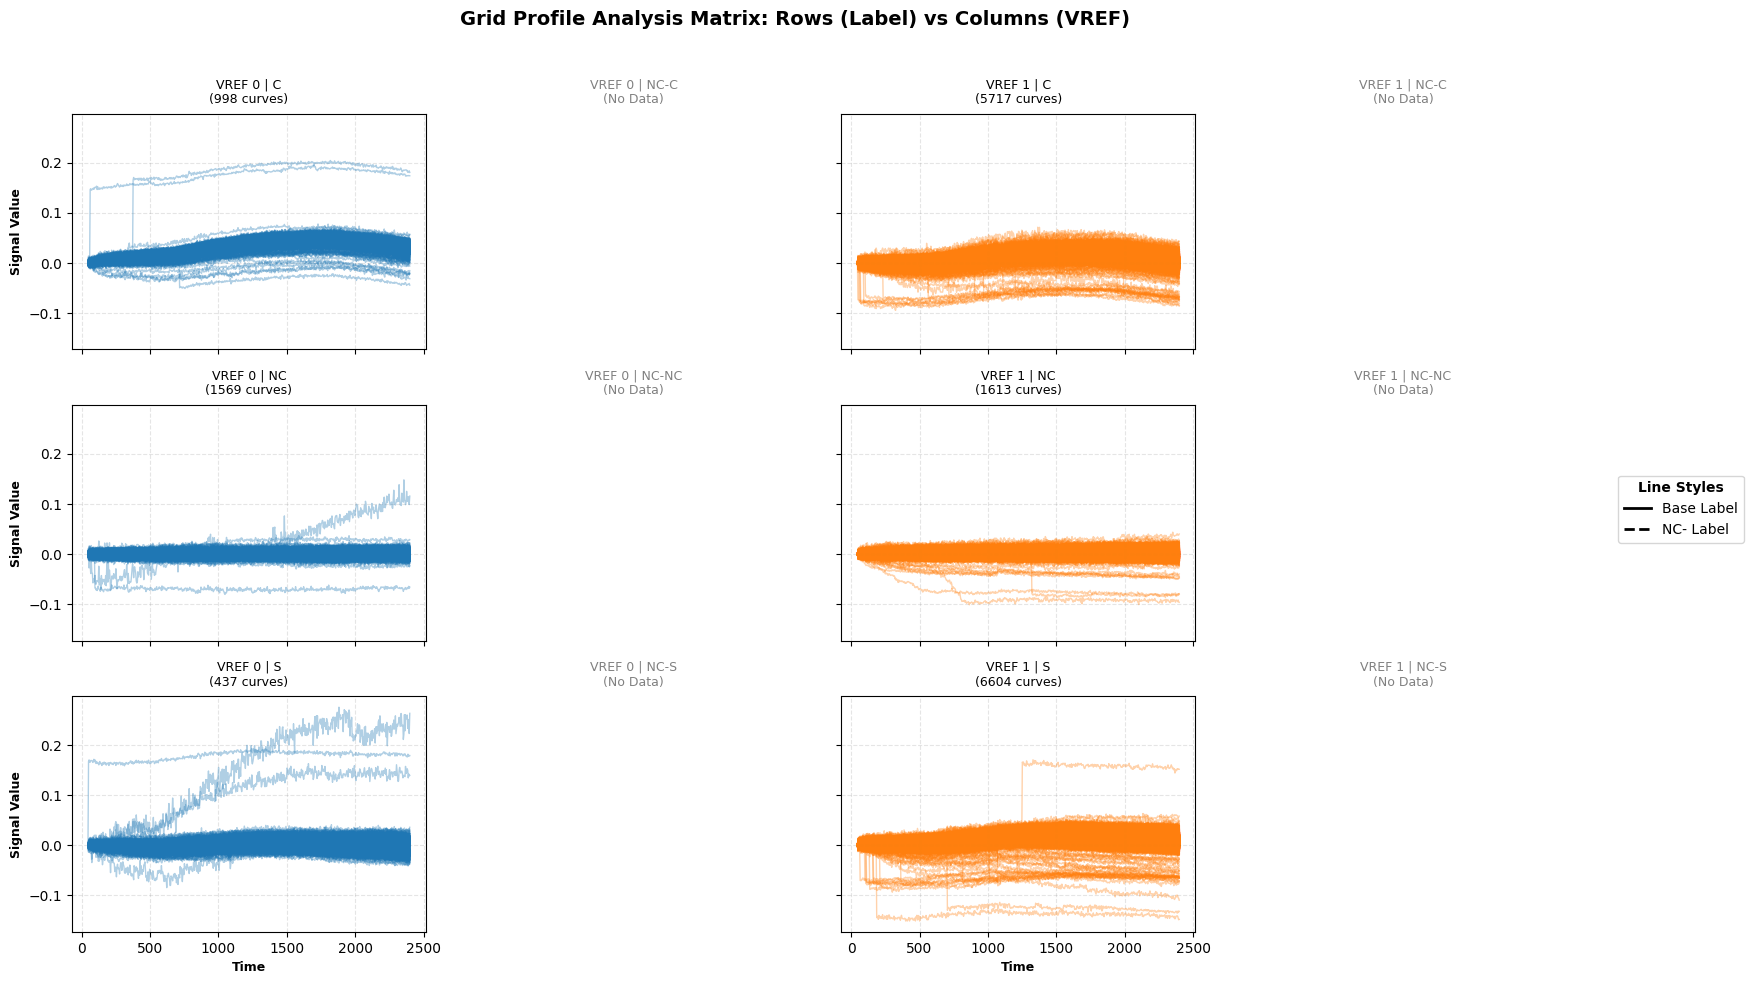


--- STAGE 3: Paired Average Analysis ---
[*] Calculating averages grouped by Label, Well ID, and VREF...


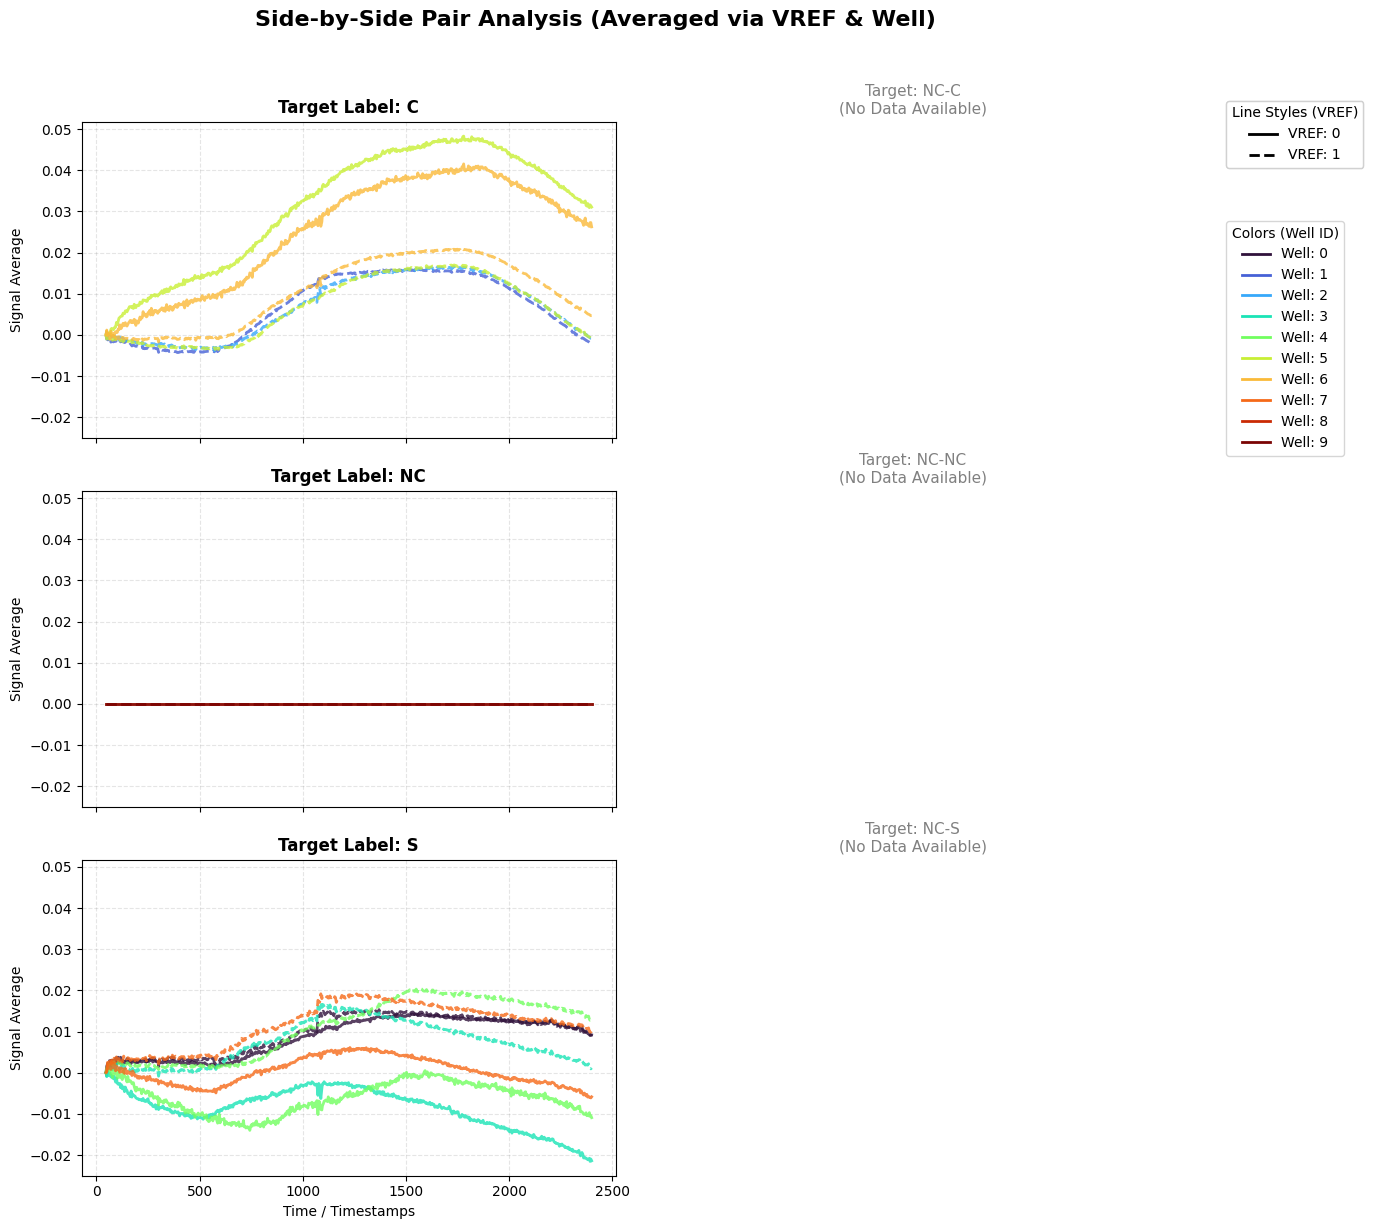


--- STAGE 4: NC Subtraction (Delta) Analysis ---
[-] No matching Sample/NC pairs found to compute deltas.

--- STAGE 5: Class Separability ---
[-] Missing data for comparative separability analysis.


In [24]:
plot_pipeline(timestamps, ori_curves, y_well, y_label, vref_idx)


--- STAGE 1: Matrix Grid (Well vs VREF) ---


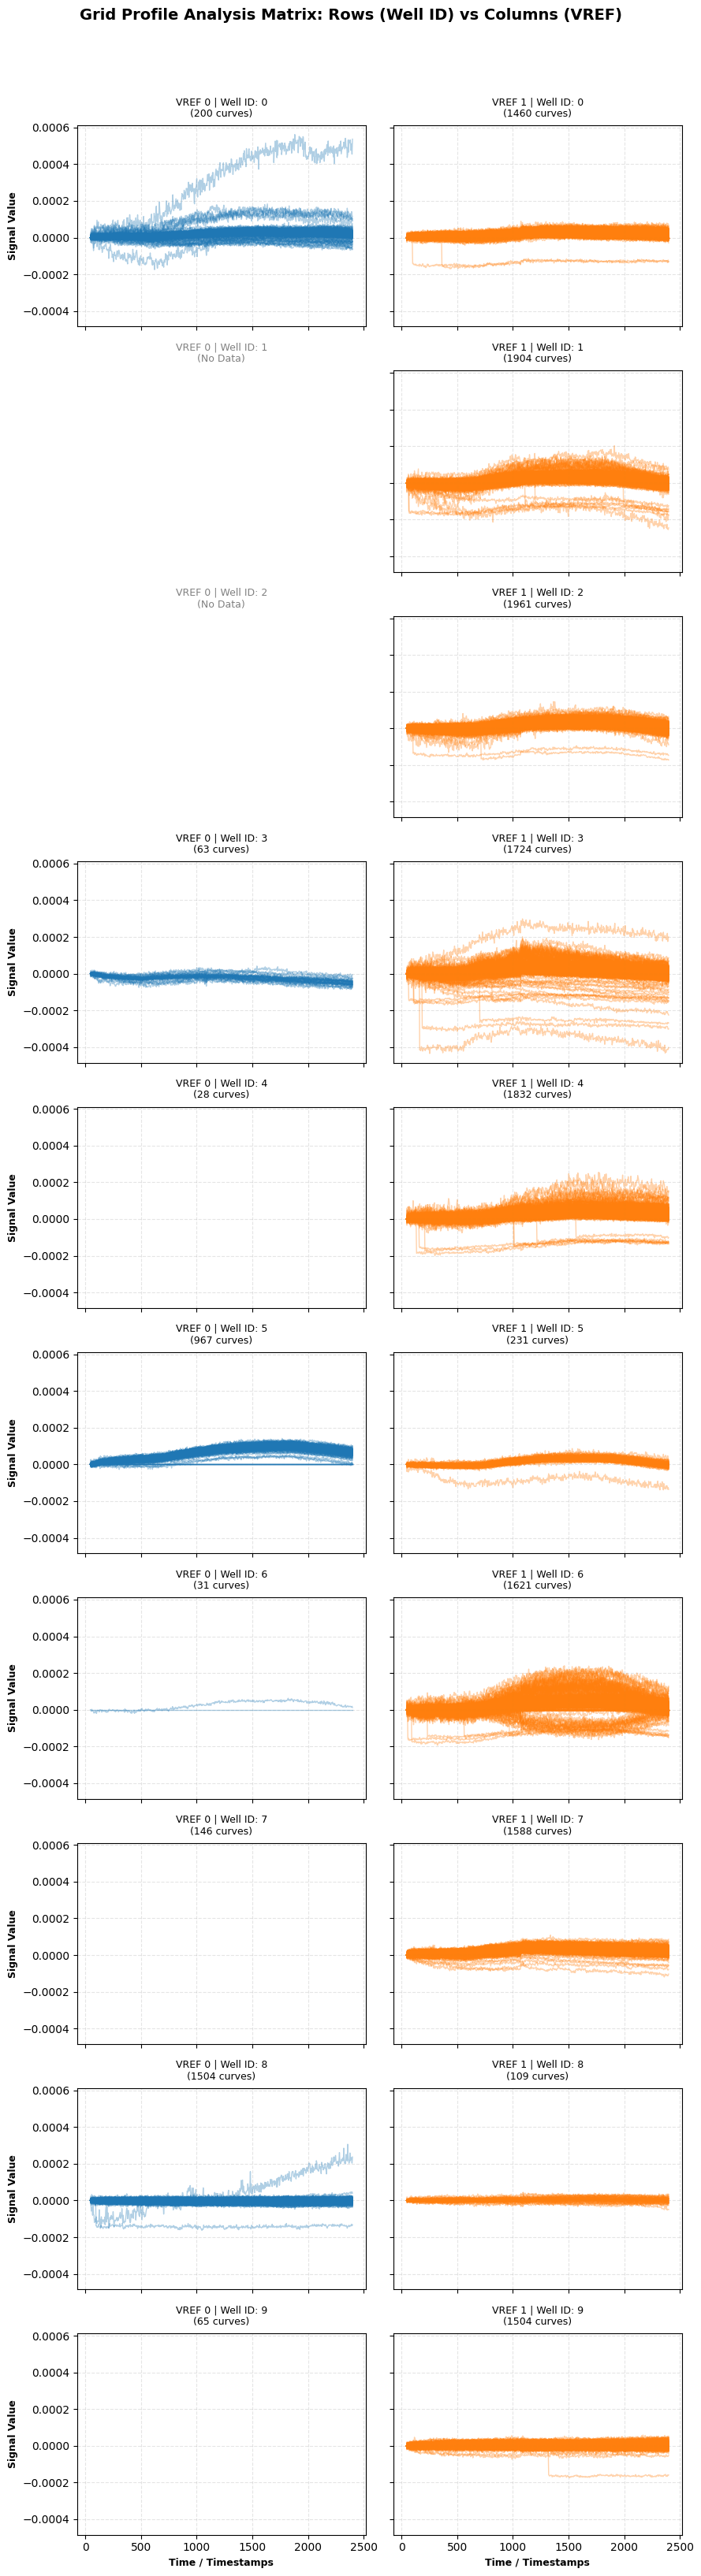


--- STAGE 2: Matrix Grid (Target Label vs VREF) ---


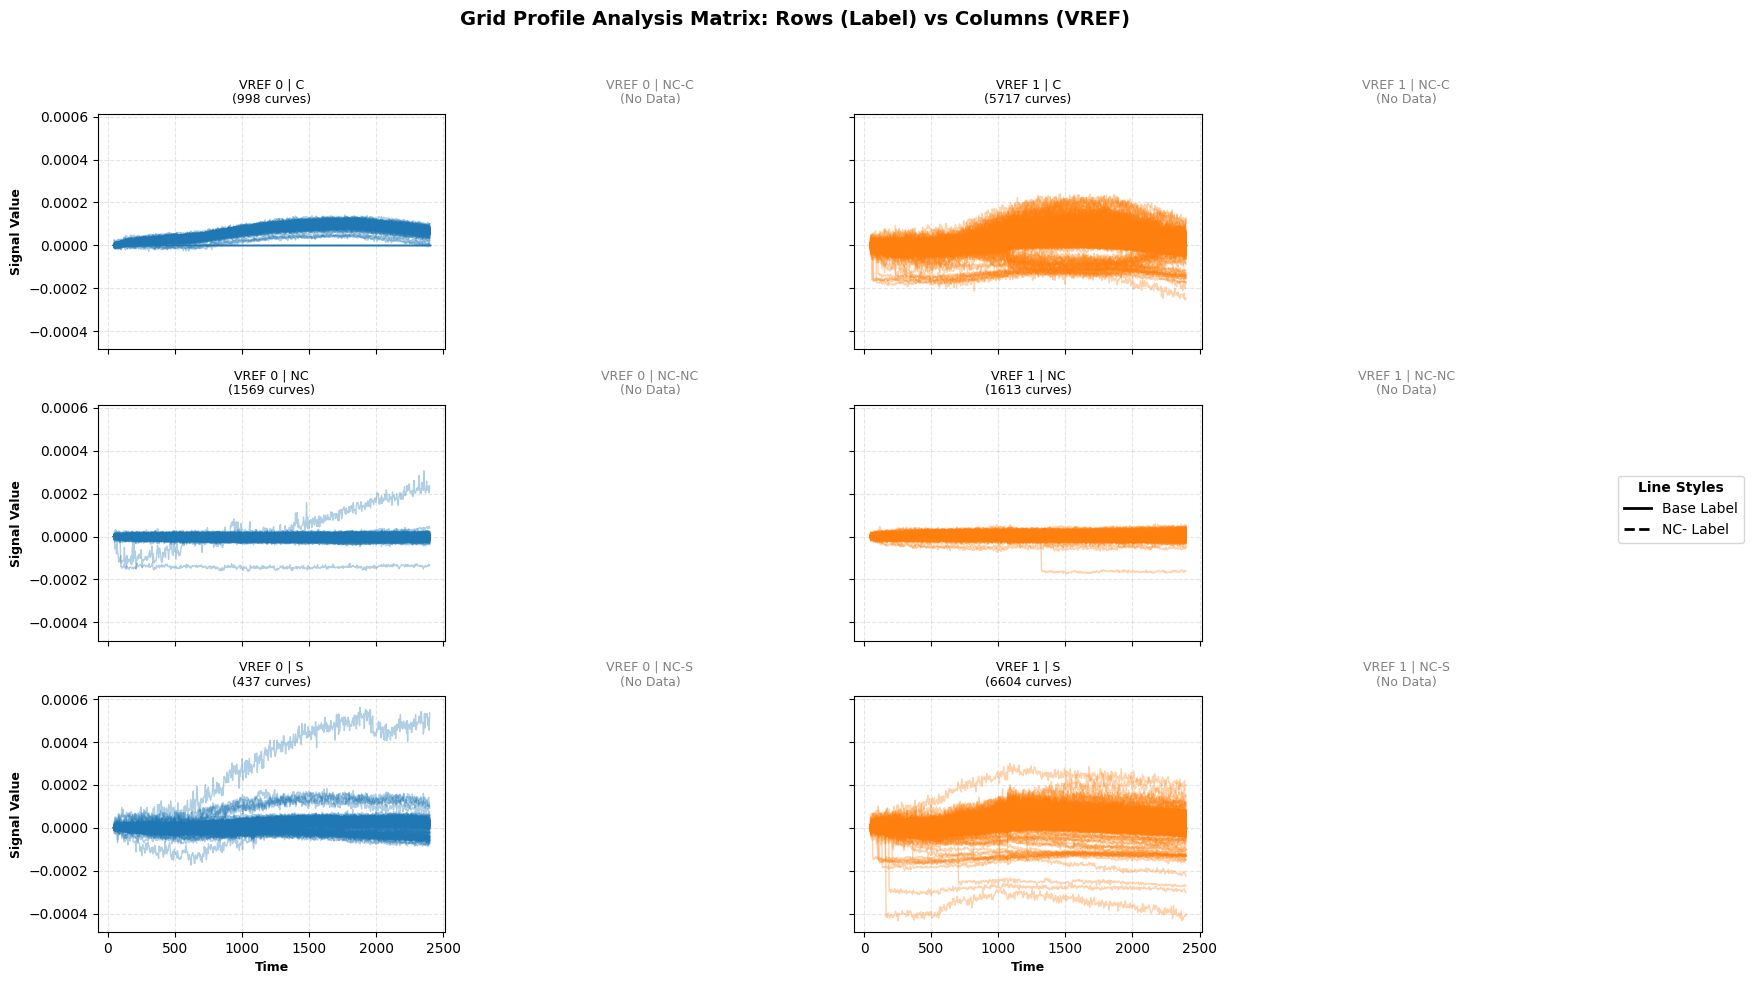


--- STAGE 3: Paired Average Analysis ---
[*] Calculating averages grouped by Label, Well ID, and VREF...


/tmp/ipykernel_146820/1750851891.py:192: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves_2d[final_mask], axis=0)


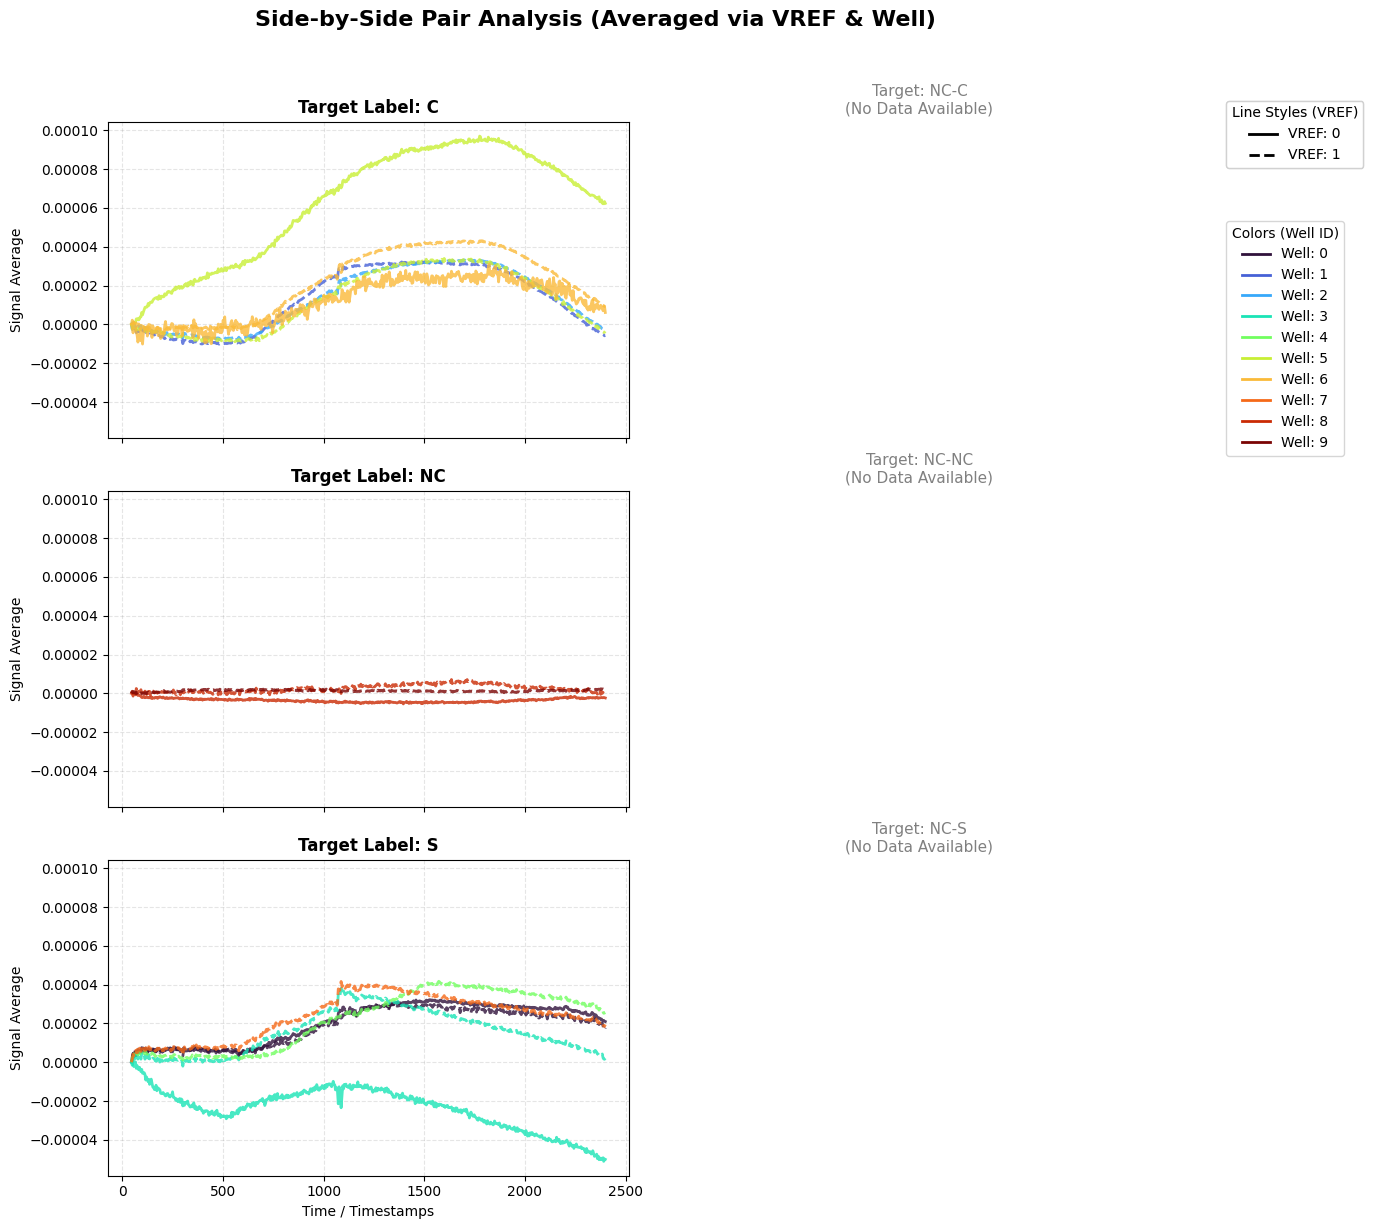


--- STAGE 4: NC Subtraction (Delta) Analysis ---
[-] No matching Sample/NC pairs found to compute deltas.

--- STAGE 5: Class Separability ---
[-] Missing data for comparative separability analysis.


In [25]:
plot_pipeline(timestamps, divided_result, y_well, y_label, vref_idx)

## 4